In [1]:
import pandas as pd
import numpy as np

In [2]:
# Custom functions
from core.demand_calculations import *
from utils.visualisations import *

In [3]:
non_metals = ['Concrete', 'Glass', 'Polymers']
selected_metals = ['Cobalt', 'Copper', 'Graphite', 'Lithium', 'Nickel', 'Neodymium']

# NRJ

## Capacity technology data

In [4]:
cap_tech_df = pd.read_excel(r'data/data.xlsx', sheet_name='ELEC_CAP_TECH')
mi_df = pd.read_excel(r'data/data.xlsx', sheet_name='MI')

In [5]:
# Remove grid MI from Greffe et al. 2025
mi_df = mi_df[~mi_df['Reference'].isin(['Greffe et al. 2025', 'From Penelope'])]

In [6]:
cap_tech_can_df = cap_tech_df[cap_tech_df['Region'] == 'Canada']
cap_tech_can_df

,Scenario,Region,Variable,Year,Value,Unit
775,Canada Net-zero,Canada,Battery Storage,2020,95.0,MW
776,Canada Net-zero,Canada,Battery Storage,2021,95.0,MW
777,Canada Net-zero,Canada,Battery Storage,2022,140.0,MW
778,Canada Net-zero,Canada,Battery Storage,2023,140.0,MW
779,Canada Net-zero,Canada,Battery Storage,2024,140.0,MW
...,...,...,...,...,...,...
9481,Global Net-zero,Canada,Uranium SMR,2046,22671.0,MW
9482,Global Net-zero,Canada,Uranium SMR,2047,22996.0,MW
9483,Global Net-zero,Canada,Uranium SMR,2048,23311.0,MW
9484,Global Net-zero,Canada,Uranium SMR,2049,23627.0,MW


In [7]:
# Remove Battery Storage in the cap_tech_can_df
cap_tech_can_df = cap_tech_can_df[
     (cap_tech_can_df['Variable'] != 'Battery Storage')
     #(cap_tech_can_df['Variable'] != 'Total')
 ]

In [8]:
# df = cap_tech_can_df

# group_cols = ['Scenario','Region','Year','Unit']
# # filter
# solar = df[df['Variable'].isin(['Solar (Distributed)','Solar (Utility scale)'])]
# solar_total = solar.groupby(group_cols)['Value'].sum().reset_index()
# solar_total['Variable']='Solar (Total)'
#
# # wind
# wind = df[df['Variable'].isin(['Onshore Wind','Offshore Wind'])]
# wind_total = wind.groupby(group_cols)['Value'].sum().reset_index()
# wind_total['Variable']='Wind (Total)'
#
# # total minus
# # get Total rows
# total = df[df['Variable']=='Total'][['Scenario','Region','Year','Value','Unit']]
#
# # merge with solar and wind totals
# tmp = total.merge(solar_total[['Scenario','Region','Year','Value']], on=['Scenario','Region','Year'], how='left', suffixes=('','_solar'))
# tmp = tmp.merge(wind_total[['Scenario','Region','Year','Value']], on=['Scenario','Region','Year'], how='left', suffixes=('','_wind'))
# tmp['Value_sub'] = tmp['Value'] - tmp['Value_solar'].fillna(0) - tmp['Value_wind'].fillna(0)
# tot_sub = tmp[['Scenario','Region','Year','Unit']].copy()
# tot_sub['Value']=tmp['Value_sub']
# tot_sub['Variable']='Total - Solar - Wind'
#
# # combine
# df_new = pd.concat([df, solar_total, wind_total, tot_sub], ignore_index=True)
# df_new.head()

In [9]:
# Create a df with the unique variable names
variables_df = pd.DataFrame(cap_tech_can_df['Variable'].unique(), columns=['Variable'])
variables_df

,Variable
0,Bioenergy
1,Bioenergy with CCUS
2,Coal and Coke
3,Coal with CCUS
4,Hydro
5,Hydrogen
6,Natural Gas
7,Natural Gas with CCUS
8,Offshore Wind
9,Oil


In [10]:
#cap_tech_can_df = df_new

## Define mapping dictionnary between CER technologies and MI sub-technologies

In [11]:
nrj_mi_mapping = {
    "Bioenergy": [("Biomass, Aggregated", 1.0)],
    "Bioenergy with CCUS": [("Biomass with CCS, Aggregated", 1.0)],
    "Coal and coke": [("Fossil energy, Coal", 1.0)],
    "Coal with CCUS": [("Fossil energy, Coal with CCS", 1.0)],
    "Hydro": [("Hydroelectricity, Aggregated", 1.0)],
    "Hydrogen": [("Fossil energy, Hydrogen", 1.0)],
    "Natural Gas": [("Fossil energy, Natural gas", 1.0)],
    "Natural Gas with CCUS": [("Fossil energy, Natural gas with CCS", 1.0)],
    "Onshore Wind": [("Wind, Onshore", 1.0)],
    "Offshore Wind": [("Wind, Offshore", 1.0)],
    "Oil": [("Fossil energy, Natural gas", 1.0)],
    "Solar (Distributed)": [("Solar PV, Aggregated", 1.0)],
    "Solar (Utility scale)": [("Solar CSP, Aggregated", 1.0)],
    "Uranium": [("Nuclear, Nuclear Aggregated", 1.0)],
    "Uranium SMR": [("Nuclear, Nuclear Boiling water power plant", 0.8), ("Nuclear, HTGR", 0.2)],
    "Total": [
            ("Grid, Transmission grid", 1.0),
            ("Grid, Distribution grid", 1.0),
            ("Grid, Transmission transformers", 1.0),
            ("Grid, Distribution transformers", 1.0)
        ],

    # "Total": [
    #         ("Grid, HV lines", 1.0),
    #         ("Grid, HV Substation", 1.0),
    #         ("Grid, HV Transformer", 1.0),
    #         ("Grid, LV lines", 1.0),
    #         ("Grid, LV Substation", 1.0),
    #         ("Grid, LV Transformer", 1.0),
    #     ],
    #     "Solar (Total)": [
    #         ("Grid, MV lines|Solar", 1.0),
    #         ("Grid, MV Substation|Solar", 1.0),
    #         ("Grid, MV Transformer|Solar", 1.0),
    #     ],
    #     "Wind (Total)": [
    #         ("Grid, MV lines|Wind", 1.0),
    #         ("Grid, MV Substation|Wind", 1.0),
    #         ("Grid, MV Transformer|Wind", 1.0),
    #     ],
    #     "Total - Solar - Wind": [
    #         ("Grid, MV lines|Other", 1.0),
    #         ("Grid, MV Substation|Other", 1.0),
    #         ("Grid, MV Transformer|Other", 1.0),
    #     ]
}

## Disaggregate capacity data based on the mapping dictionary

In [12]:
cap_tech_can_disagg_df = disaggregate_nrj_capacity(cap_tech_can_df, nrj_mi_mapping, tech_col="Variable", cap_col="Value")

In [13]:
# Put the value in GW and
cap_tech_can_disagg_df['Value'] = cap_tech_can_disagg_df['Value'] / 1000
cap_tech_can_disagg_df['Unit'] = 'GW'

In [14]:
cap_tech_can_disagg_df

,Scenario,Region,Variable,Year,Value,Unit,Associated_MI
807,Canada Net-zero,Canada,Bioenergy,2021,2.5431,GW,"Biomass, Aggregated"
808,Canada Net-zero,Canada,Bioenergy,2022,2.5431,GW,"Biomass, Aggregated"
809,Canada Net-zero,Canada,Bioenergy,2023,2.5431,GW,"Biomass, Aggregated"
810,Canada Net-zero,Canada,Bioenergy,2024,2.5431,GW,"Biomass, Aggregated"
811,Canada Net-zero,Canada,Bioenergy,2025,2.6936,GW,"Biomass, Aggregated"
...,...,...,...,...,...,...,...
9483,Global Net-zero,Canada,Uranium SMR,2048,4.6622,GW,"Nuclear, HTGR"
9484,Global Net-zero,Canada,Uranium SMR,2049,18.9016,GW,"Nuclear, Nuclear Boiling water power plant"
9484,Global Net-zero,Canada,Uranium SMR,2049,4.7254,GW,"Nuclear, HTGR"
9485,Global Net-zero,Canada,Uranium SMR,2050,19.1832,GW,"Nuclear, Nuclear Boiling water power plant"


In [15]:
cap_tech_can_disagg_df.to_csv(r'cap_tech_can_disagg_df.csv', index=False)

In [16]:
cap_tech_can_disagg_df['Variable'].unique()

array(['Bioenergy', 'Bioenergy with CCUS', 'Coal and Coke',
       'Coal with CCUS', 'Hydro', 'Hydrogen', 'Natural Gas',
       'Natural Gas with CCUS', 'Offshore Wind', 'Oil', 'Onshore Wind',
       'Solar (Distributed)', 'Solar (Utility scale)', 'Total', 'Uranium',
       'Uranium SMR'], dtype=object)

In [17]:
material_demand_nrj = calculate_metal_demand_nrj(cap_tech_can_disagg_df, mi_df)

In [18]:
material_demand_nrj

,Scenario,Region,Year,Variable,Metal,Metal intensity (t/GW),Metal_demand_t,Fiability_used,Comment
0,Canada Net-zero,Canada,2021,Bioenergy,Aluminum,2600.0,6612.06000,Small variability in data,mean of Small variability in data
1,Canada Net-zero,Canada,2021,Bioenergy,Chromium,2.0,5.08620,Variability in data,None
2,Canada Net-zero,Canada,2021,Bioenergy,Cobalt,2.0,5.08620,Variability in data,None
3,Canada Net-zero,Canada,2021,Bioenergy,Concrete,159000.0,404352.90000,No comparison,None
4,Canada Net-zero,Canada,2021,Bioenergy,Copper,2222.5,5652.03975,Small variability in data,mean of Small variability in data
...,...,...,...,...,...,...,...,...,...
12767,Global Net-zero,Canada,2050,Uranium SMR,NaN,NaN,NaN,NaN,NaN
12768,Global Net-zero,Canada,2050,Uranium SMR,Copper,24.8,118.93584,Small variability in data,None
12769,Global Net-zero,Canada,2050,Uranium SMR,Molybdenum,18.3,87.76314,Variability in data,None
12770,Global Net-zero,Canada,2050,Uranium SMR,Nickel,33.7,161.61846,Variability in data,None


In [19]:
material_demand_nrj['Variable'].unique()

array(['Bioenergy', 'Bioenergy with CCUS', 'Coal and Coke',
       'Coal with CCUS', 'Hydro', 'Hydrogen', 'Natural Gas',
       'Natural Gas with CCUS', 'Offshore Wind', 'Oil', 'Onshore Wind',
       'Solar (Distributed)', 'Solar (Utility scale)', 'Total', 'Uranium',
       'Uranium SMR'], dtype=object)

In [20]:
rename_map = {
    # "Total": "Grid (HV+LV)",
    # "Solar (Total)": "Grid (MV)",
    # "Wind (Total)": "Grid (MV)",
    # "Total - Solar - Wind": "Grid (MV)"
    "Total": "Grid"
}

material_demand_nrj["Variable"] = material_demand_nrj["Variable"].replace(rename_map)

In [21]:
material_demand_nrj_nz = material_demand_nrj[material_demand_nrj['Scenario'] == 'Canada Net-zero']
material_demand_nrj_step = material_demand_nrj[material_demand_nrj['Scenario'] == 'Current Measures']

In [22]:
metal_demand_nrj = material_demand_nrj[~material_demand_nrj['Metal'].isin(non_metals)]

In [23]:
material_demand_nrj.to_csv(r'results/NRJ/material_demand_nrj.csv', index=False)
metal_demand_nrj.to_csv(r'results/NRJ/metal_demand_nrj.csv', index=False)

In [24]:
material_demand_nrj_nz = material_demand_nrj[material_demand_nrj['Scenario'] == 'Canada Net-zero']
material_demand_nrj_step = material_demand_nrj[material_demand_nrj['Scenario'] == 'Current Measures']

In [25]:
metal_demand_nrj_nz = metal_demand_nrj[metal_demand_nrj['Scenario'] == 'Canada Net-zero']
metal_demand_nrj_step = metal_demand_nrj[metal_demand_nrj['Scenario'] == 'Current Measures']

## Plots

✅ Saved to results/NRJ/metal_demand_nrj_nz_facets.png / .svg


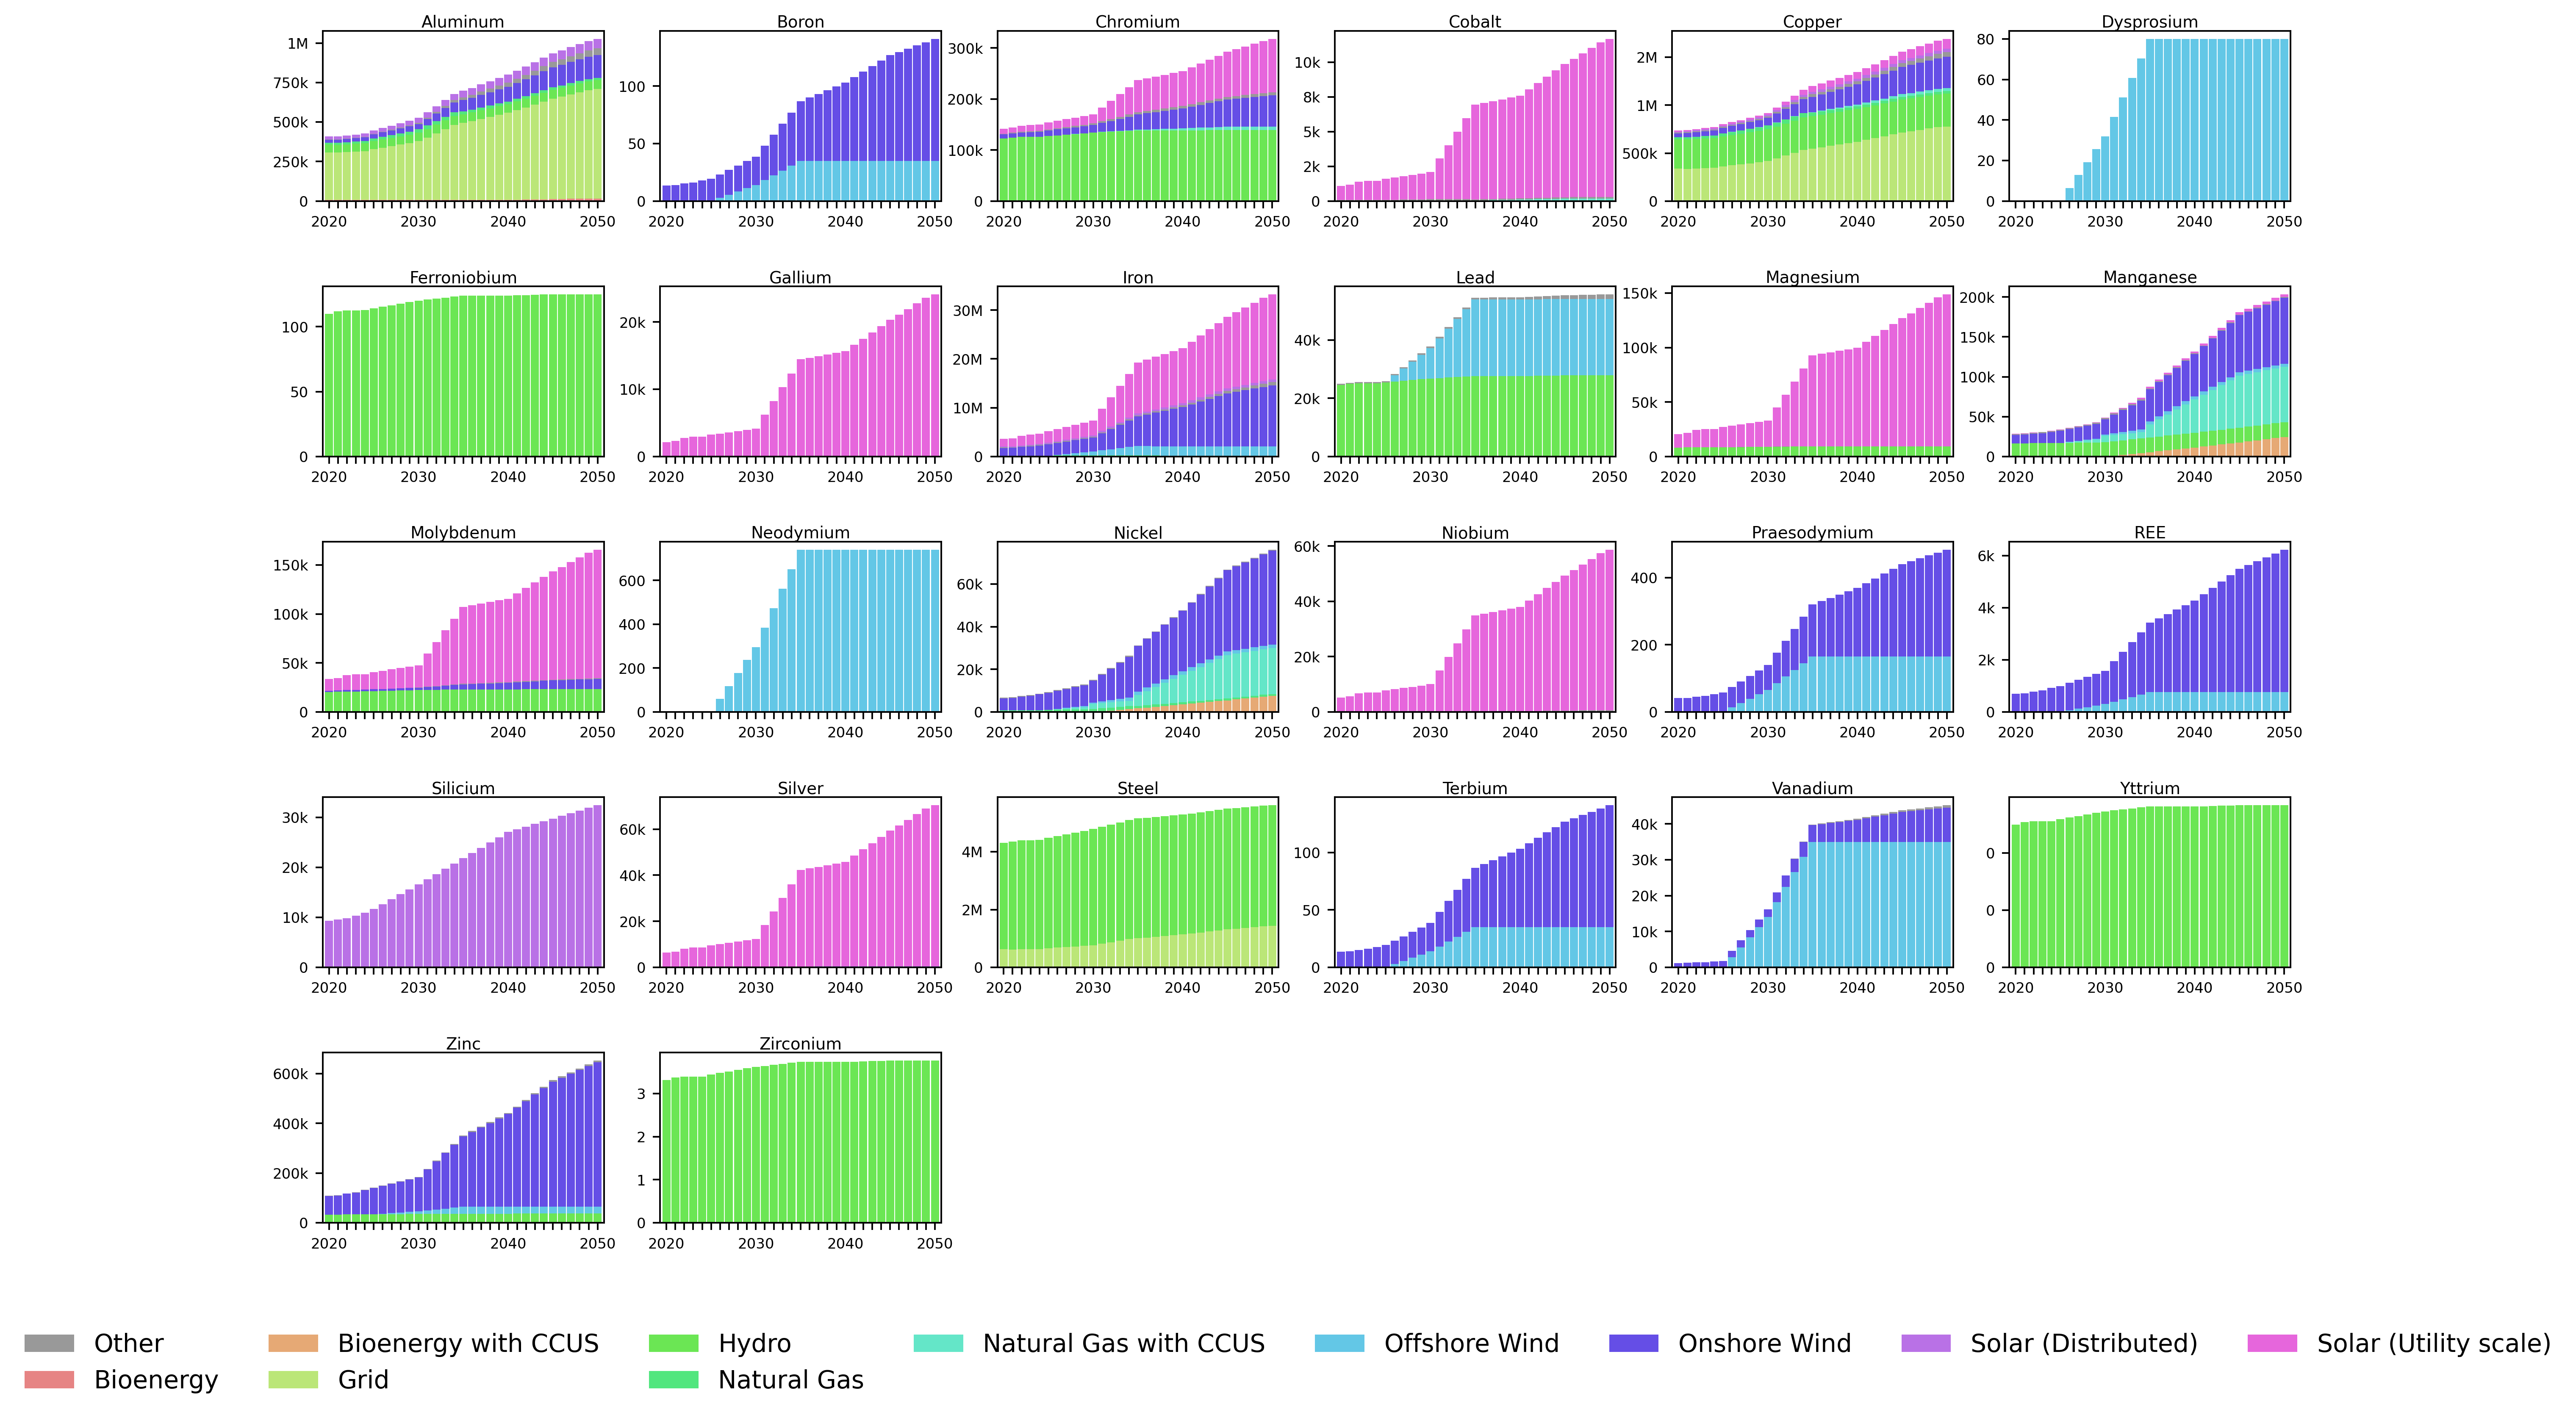

In [26]:
plot_metal_demand_facets(metal_demand_nrj_nz, savepath=r'results/NRJ/metal_demand_nrj_nz_facets')

✅ Figure saved to results/NRJ/metal_demand_nrj_stackplots.png and .svg


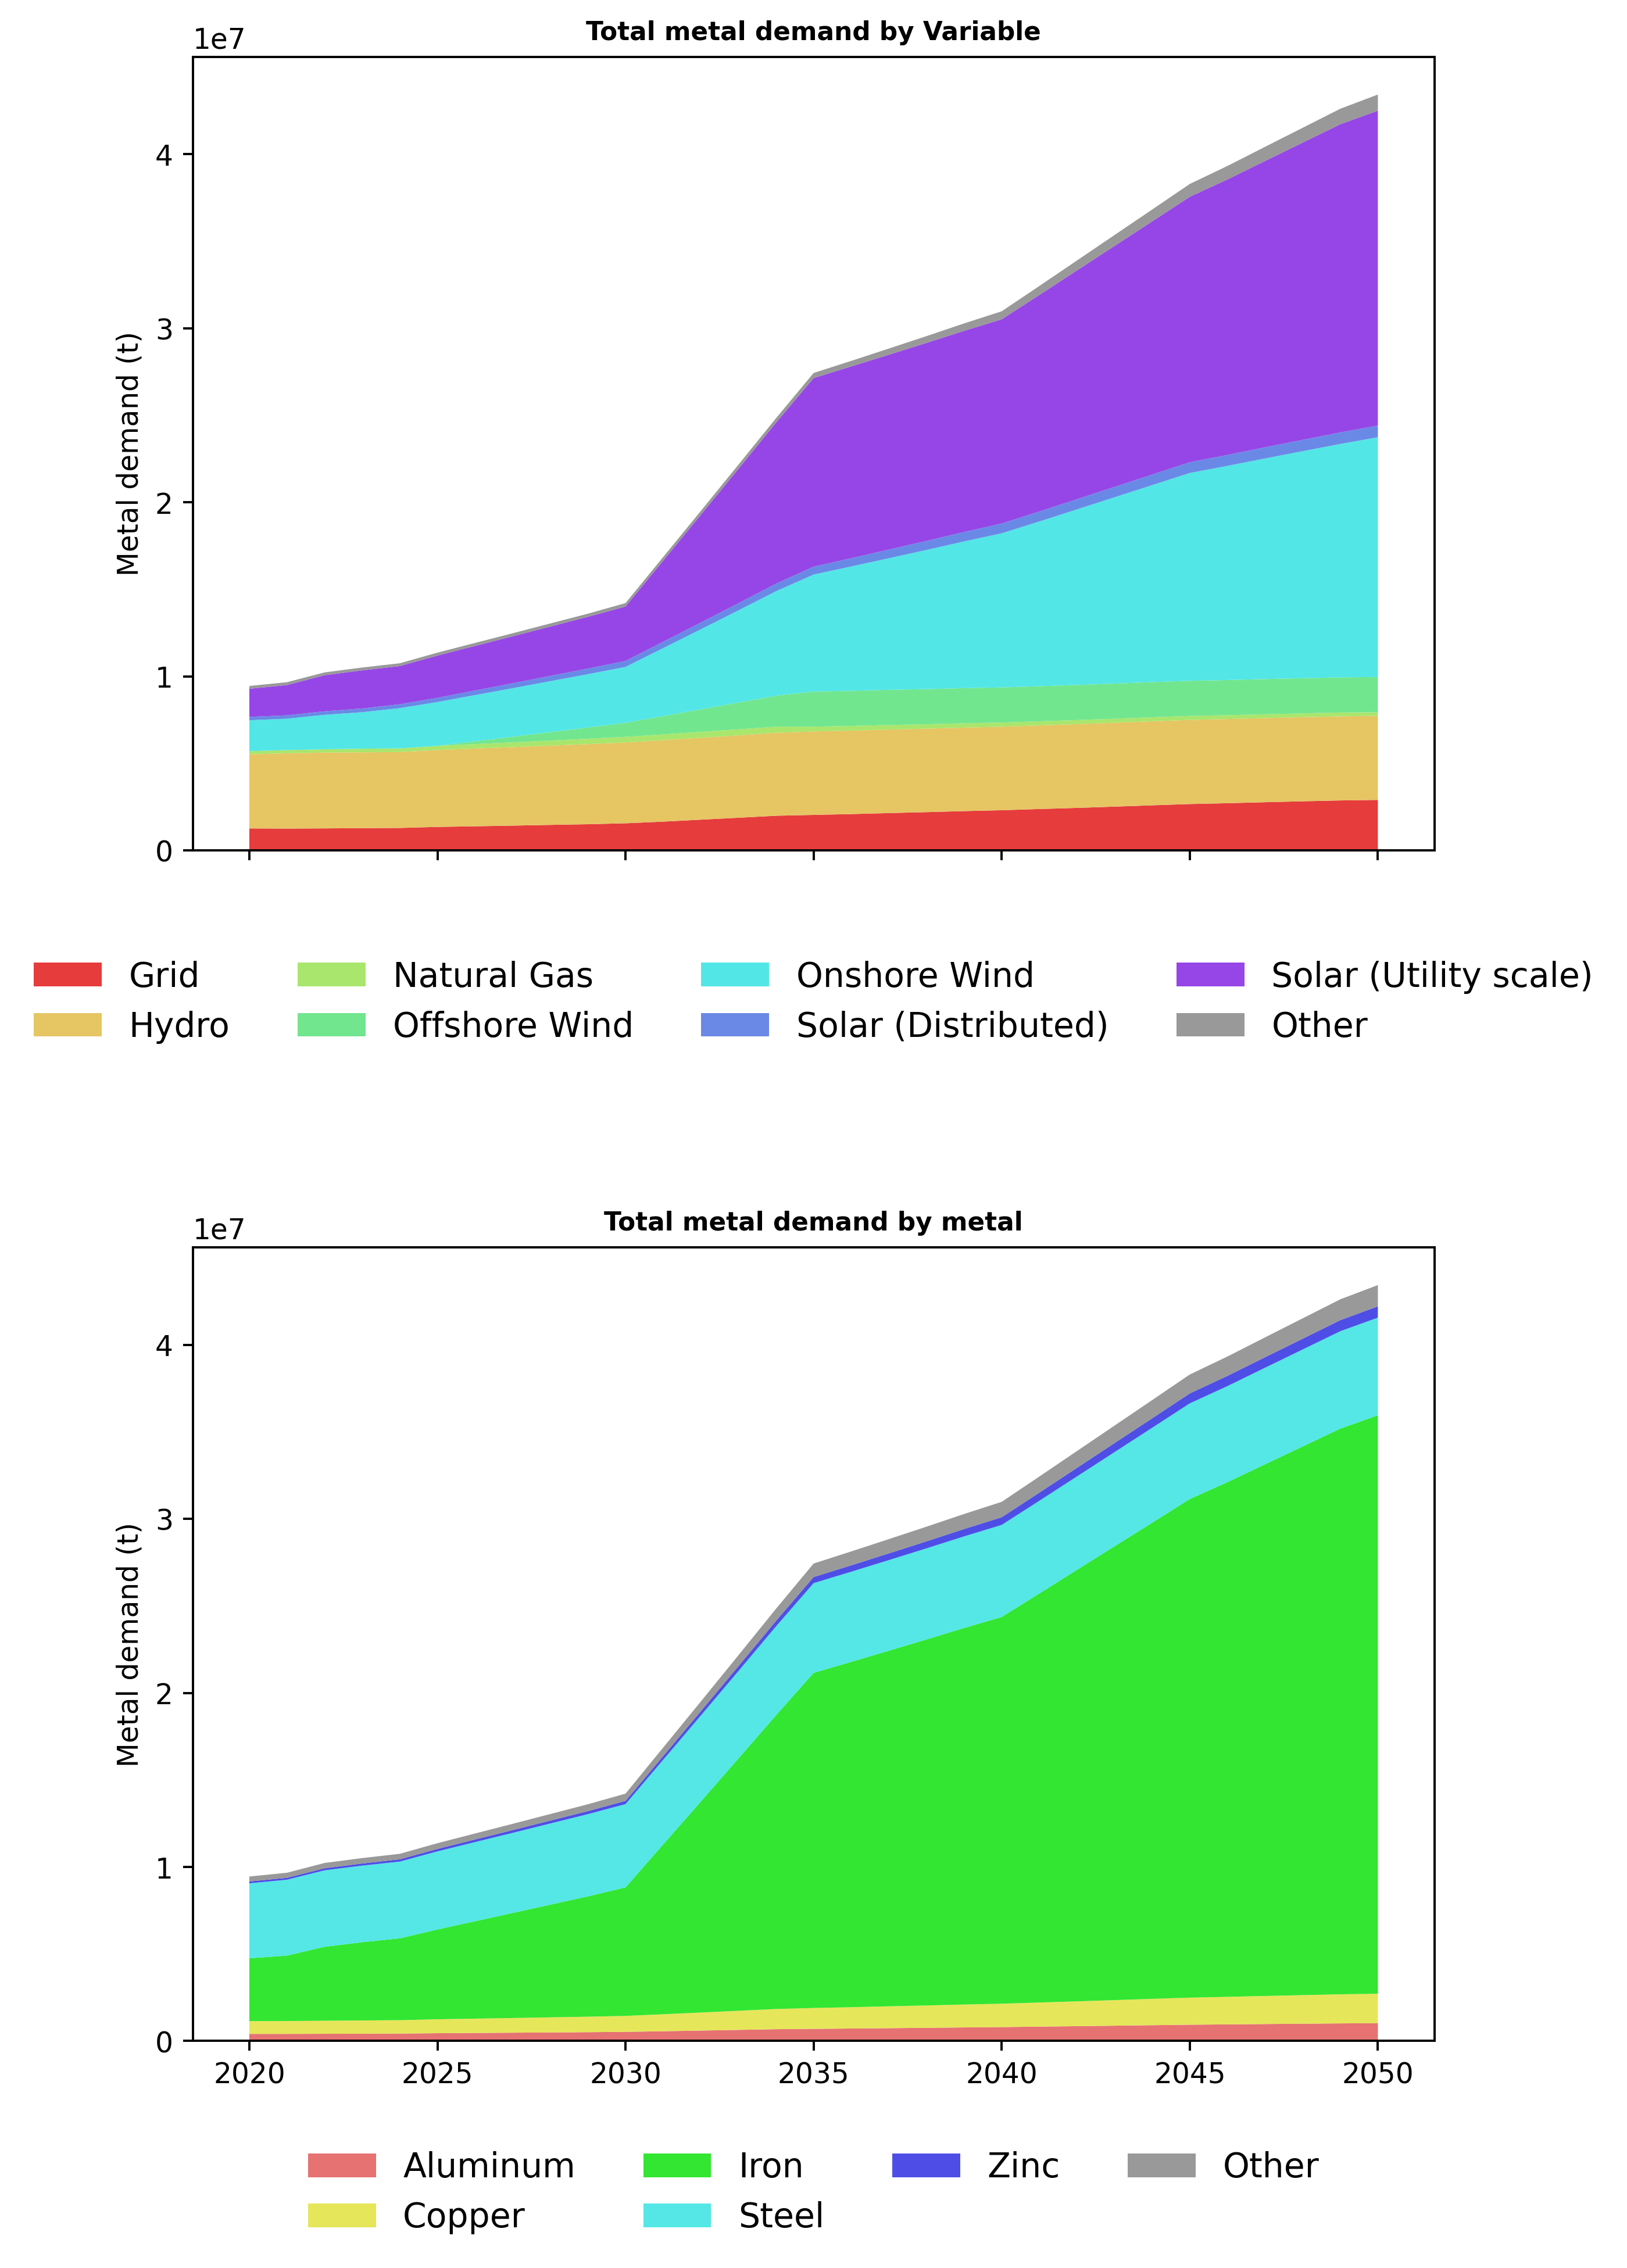

In [27]:
plot_metal_demand_stackplots(metal_demand_nrj_nz, savepath=r'results/NRJ/metal_demand_nrj_stackplots')

# EVs - Battery

## Import data

In [28]:
# EV sales data in Canada from IEA
ev_df = pd.read_excel(r'data/data.xlsx', sheet_name='EVs_CAN')

In [29]:
ev_df = ev_df[
    (ev_df['Parameter'] == 'EV sales') &
    (ev_df['Year'] == 2024)
]

In [30]:
ev_df

,Country,Parameter,Mode,Powertrain,Year,Unit,Value,Mass_vehicule
3,Canada,EV sales,2 and 3 wheelers,BEV,2024,Vehicles,170.0,0.098086
22,Canada,EV sales,Buses,BEV,2024,Vehicles,210.0,5.675237
29,Canada,EV sales,Cars,BEV,2024,Vehicles,190000.0,1.000000
48,Canada,EV sales,Trucks,BEV,2024,Vehicles,2000.0,3.689278
51,Canada,EV sales,Vans,BEV,2024,Vehicles,11000.0,1.957751
66,Canada,EV sales,Buses,FCEV,2024,Vehicles,13.0,5.675237
101,Canada,EV sales,Cars,FCEV,2024,Vehicles,20.0,1.000000
105,Canada,EV sales,Trucks,FCEV,2024,Vehicles,6.0,3.689278
123,Canada,EV sales,Cars,PHEV,2024,Vehicles,62000.0,1.000000
130,Canada,EV sales,Vans,PHEV,2024,Vehicles,6400.0,1.957751


In [31]:
# End use demand for transport sector in PJ from CER scenarios
transport_demand_ef = pd.read_excel(r'data/data.xlsx', sheet_name='END_USE_TRANSPORT')

In [32]:
# Filter for Year 2024 and above, variable = electricity and region = Canada
transport_demand_elec_ef = transport_demand_ef[
    (transport_demand_ef['Region'] == 'Canada') &
    (transport_demand_ef['Year'] >= 2024) &
    (transport_demand_ef['Variable'] == 'Electricity')
]

In [33]:
transport_demand_elec_ef

,Scenario,Region,Variable,Year,Value,Sector,Unit
1224,Current Measures,Canada,Electricity,2024,11.5558,Transportation,PJ
1235,Current Measures,Canada,Electricity,2025,16.5362,Transportation,PJ
1246,Current Measures,Canada,Electricity,2026,22.2906,Transportation,PJ
1257,Current Measures,Canada,Electricity,2027,28.3160,Transportation,PJ
1268,Current Measures,Canada,Electricity,2028,34.8046,Transportation,PJ
...,...,...,...,...,...,...,...
18336,Global Net-zero,Canada,Electricity,2046,687.7432,Transportation,PJ
18477,Global Net-zero,Canada,Electricity,2047,709.8365,Transportation,PJ
18618,Global Net-zero,Canada,Electricity,2048,731.0948,Transportation,PJ
18759,Global Net-zero,Canada,Electricity,2049,751.4916,Transportation,PJ


## Compute future EV sales based on growth factors (based on 2024 values)

In [34]:
from core.demand_calculations import compute_ev_growth, project_ev_sales

In [35]:
ev_growth_df = compute_ev_growth(transport_demand_elec_ef)
projected_ev_sales_df = project_ev_sales(ev_df, ev_growth_df)

In [36]:
projected_ev_sales_df.drop(columns=['Parameter', 'Unit'], inplace=True)
projected_ev_sales_df.rename(columns={'Value': 'EV_sales'}, inplace=True)

In [37]:
projected_ev_sales_df

,Country,Mode,Powertrain,Year,EV_sales,Mass_vehicule,Scenario
0,Canada,2 and 3 wheelers,BEV,2024,1.700000e+02,0.098086,Current Measures
1,Canada,Buses,BEV,2024,2.100000e+02,5.675237,Current Measures
2,Canada,Cars,BEV,2024,1.900000e+05,1.000000,Current Measures
3,Canada,Trucks,BEV,2024,2.000000e+03,3.689278,Current Measures
4,Canada,Vans,BEV,2024,1.100000e+04,1.957751,Current Measures
...,...,...,...,...,...,...,...
805,Canada,Buses,FCEV,2050,5.911229e+02,5.675237,Global Net-zero
806,Canada,Cars,FCEV,2050,9.094199e+02,1.000000,Global Net-zero
807,Canada,Trucks,FCEV,2050,2.728260e+02,3.689278,Global Net-zero
808,Canada,Cars,PHEV,2050,2.819202e+06,1.000000,Global Net-zero


## Estimate battery capacity

In [38]:
bat_cap_df = pd.read_excel(r'data/data.xlsx', sheet_name='BATTERY_CAP')

In [39]:
bat_cap_df

,Mode,Powertrain,Unit,Battery_cap,Value_min,Value_max,Comment
0,2 and 3 wheelers,BEV,kWh,3.00,1.5,4,NaN
1,Buses,BEV,kWh,300.00,250.0,350,NaN
2,Cars,BEV,kWh,65.00,55.0,75,NaN
3,Trucks,BEV,kWh,350.00,200.0,600,NaN
4,Vans,BEV,kWh,75.00,70.0,80,NaN
5,Buses,FCEV,kWh,35.00,30.0,40,NaN
6,Cars,FCEV,kWh,1.75,1.5,2,NaN
7,Trucks,FCEV,kWh,350.00,200.0,600,NaN
8,Cars,PHEV,kWh,15.00,12.0,18,NaN
9,Vans,PHEV,kWh,21.80,20.0,30,NaN


In [40]:
ev_installed_battery_cap_df = projected_ev_sales_df.merge(bat_cap_df[['Mode', 'Powertrain', 'Battery_cap']], how='left', on=['Mode', 'Powertrain'])
#ev_installed_battery_cap_df.rename(columns={'Value': 'EV_sales'}, inplace=True)

In [41]:
ev_installed_battery_cap_df

,Country,Mode,Powertrain,Year,EV_sales,Mass_vehicule,Scenario,Battery_cap
0,Canada,2 and 3 wheelers,BEV,2024,1.700000e+02,0.098086,Current Measures,3.00
1,Canada,Buses,BEV,2024,2.100000e+02,5.675237,Current Measures,300.00
2,Canada,Cars,BEV,2024,1.900000e+05,1.000000,Current Measures,65.00
3,Canada,Trucks,BEV,2024,2.000000e+03,3.689278,Current Measures,350.00
4,Canada,Vans,BEV,2024,1.100000e+04,1.957751,Current Measures,75.00
...,...,...,...,...,...,...,...,...
805,Canada,Buses,FCEV,2050,5.911229e+02,5.675237,Global Net-zero,35.00
806,Canada,Cars,FCEV,2050,9.094199e+02,1.000000,Global Net-zero,1.75
807,Canada,Trucks,FCEV,2050,2.728260e+02,3.689278,Global Net-zero,350.00
808,Canada,Cars,PHEV,2050,2.819202e+06,1.000000,Global Net-zero,15.00


In [42]:
ev_installed_battery_cap_df['Installed_battery_cap'] = ev_installed_battery_cap_df['Battery_cap'] * ev_installed_battery_cap_df['EV_sales']

In [43]:
ev_installed_battery_cap_df

,Country,Mode,Powertrain,Year,EV_sales,Mass_vehicule,Scenario,Battery_cap,Installed_battery_cap
0,Canada,2 and 3 wheelers,BEV,2024,1.700000e+02,0.098086,Current Measures,3.00,5.100000e+02
1,Canada,Buses,BEV,2024,2.100000e+02,5.675237,Current Measures,300.00,6.300000e+04
2,Canada,Cars,BEV,2024,1.900000e+05,1.000000,Current Measures,65.00,1.235000e+07
3,Canada,Trucks,BEV,2024,2.000000e+03,3.689278,Current Measures,350.00,7.000000e+05
4,Canada,Vans,BEV,2024,1.100000e+04,1.957751,Current Measures,75.00,8.250000e+05
...,...,...,...,...,...,...,...,...,...
805,Canada,Buses,FCEV,2050,5.911229e+02,5.675237,Global Net-zero,35.00,2.068930e+04
806,Canada,Cars,FCEV,2050,9.094199e+02,1.000000,Global Net-zero,1.75,1.591485e+03
807,Canada,Trucks,FCEV,2050,2.728260e+02,3.689278,Global Net-zero,350.00,9.548909e+04
808,Canada,Cars,PHEV,2050,2.819202e+06,1.000000,Global Net-zero,15.00,4.228802e+07


## Add chemistry mix scenario

In [44]:
chemistry_mix_df = pd.read_excel(r'data/data.xlsx', sheet_name='BATTERY_MIX')

In [45]:
chemistry_mix_df = chemistry_mix_df[chemistry_mix_df['Scenario'] == 'North American Scenario']

In [46]:
ev_installed_battery_cap_df = apply_chemistry_mix(ev_installed_battery_cap_df, chemistry_mix_df)

In [47]:
ev_installed_battery_cap_df

,Country,Mode,Battery_type,Powertrain,Year,EV_sales,Mass_vehicule,Scenario,Battery_cap,Installed_battery_cap
0,Canada,2 and 3 wheelers,All,BEV,2024,170.000000,0.098086,Current Measures,3.0,5.100000e+02
1,Canada,Buses,All,BEV,2024,210.000000,5.675237,Current Measures,300.0,6.300000e+04
2,Canada,Cars,All,BEV,2024,190000.000000,1.000000,Current Measures,65.0,1.235000e+07
3,Canada,Trucks,All,BEV,2024,2000.000000,3.689278,Current Measures,350.0,7.000000e+05
4,Canada,Vans,All,BEV,2024,11000.000000,1.957751,Current Measures,75.0,8.250000e+05
...,...,...,...,...,...,...,...,...,...,...
3640,Canada,Vans,LMFP,PHEV,2050,291014.359845,1.957751,Global Net-zero,21.8,2.220440e+06
3641,Canada,Vans,LMO,PHEV,2050,291014.359845,1.957751,Global Net-zero,21.8,0.000000e+00
3642,Canada,Vans,NCA,PHEV,2050,291014.359845,1.957751,Global Net-zero,21.8,3.172057e+05
3643,Canada,Vans,NMC,PHEV,2050,291014.359845,1.957751,Global Net-zero,21.8,1.903234e+06


In [48]:
evs_battery_mi_mapping = { # From Battery_type to Technology, Sub-technology
    "LFP": [("Vehicle battery, LFP", 1.0)],
    "LMFP": [("Vehicle battery, LMFP", 1.0)],
    "LMO": [("Vehicle battery, LMO", 1.0)],
    "NCA": [("Vehicle battery, NCA", 1.0)],
    "NMC": [("Vehicle battery, NMC", 1.0)],
    "Na-ion": [("Vehicle battery, Na-ion", 1.0)],
}

In [49]:
material_demand_ev_battery = calculate_metal_demand_ev_battery(ev_installed_battery_cap_df, mi_df, evs_battery_mi_mapping)
material_demand_ev_battery.dropna(subset=["Metal intensity (g/kWh)"], inplace=True)
material_demand_ev_battery.drop(columns=["Battery_cap", "Technology", "Sub-technology"], inplace=True)
material_demand_ev_battery

,Country,Mode,Battery_type,Powertrain,Year,EV_sales,Mass_vehicule,Scenario,Installed_battery_cap,Metal,Metal intensity (g/kWh),Metal_demand_t,Fiability_used,Comment
810,Canada,2 and 3 wheelers,LFP,BEV,2024,170.000000,0.098086,Current Measures,5.100000e+02,Aluminum,46.400078,0.023664,No comparison,"(battery production, Li-ion, LFP, rechargeable)"
811,Canada,2 and 3 wheelers,LFP,BEV,2024,170.000000,0.098086,Current Measures,5.100000e+02,Cobalt,1536.850581,0.783794,Important variability in data,"(battery production, Li-ion, LFP, rechargeable)"
812,Canada,2 and 3 wheelers,LFP,BEV,2024,170.000000,0.098086,Current Measures,5.100000e+02,Copper,493.224834,0.251545,Variability in data,(Gr-LFP)
813,Canada,2 and 3 wheelers,LFP,BEV,2024,170.000000,0.098086,Current Measures,5.100000e+02,Lithium,128.513916,0.065542,Small variability in data,mean of Small variability in data
814,Canada,2 and 3 wheelers,LFP,BEV,2024,170.000000,0.098086,Current Measures,5.100000e+02,Manganese,1492.450788,0.761150,Variability in data,"(battery production, Li-ion, LFP, rechargeable)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12631,Canada,Vans,NMC,PHEV,2050,291014.359845,1.957751,Global Net-zero,1.903234e+06,Lithium,373.861871,711.546591,Variability in data,mean of Variability in data
12632,Canada,Vans,NMC,PHEV,2050,291014.359845,1.957751,Global Net-zero,1.903234e+06,Manganese,158.536576,301.732187,No comparison,(Gr-NMC)
12633,Canada,Vans,NMC,PHEV,2050,291014.359845,1.957751,Global Net-zero,1.903234e+06,Nickel,563.685669,1072.825682,No comparison,(Gr-NMC)
12634,Canada,Vans,Na-ion,PHEV,2050,291014.359845,1.957751,Global Net-zero,3.172057e+05,Manganese,554.878014,176.010442,Variability in data,None


In [50]:
material_demand_ev_battery_nz = material_demand_ev_battery[material_demand_ev_battery['Scenario'] == 'Canada Net-zero']
material_demand_ev_battery_step = material_demand_ev_battery[material_demand_ev_battery['Scenario'] == 'Current Measures']

In [51]:
metal_demand_ev_battery = material_demand_ev_battery[~material_demand_ev_battery['Metal'].isin(non_metals)]
metal_demand_ev_battery_nz = metal_demand_ev_battery[metal_demand_ev_battery['Scenario'] == 'Canada Net-zero']
metal_demand_ev_battery_step = metal_demand_ev_battery[metal_demand_ev_battery['Scenario'] == 'Current Measures']

In [52]:
material_demand_ev_battery.to_csv(r'results/EVs_battery/material_demand_ev_battery.csv', index=False)
metal_demand_ev_battery.to_csv(r'results/EVs_battery/metal_demand_ev_battery.csv', index=False)

## PLots

In [53]:
#plot_metal_demand_facets(metal_demand_ev_battery_nz, variable_col='Mode', savepath="results/EVs_battery/metal_demand_ev_facets_by_mode")

✅ Figure saved to results/EVs_battery/metal_demand_ev_stackplot_by_mode.png and .svg


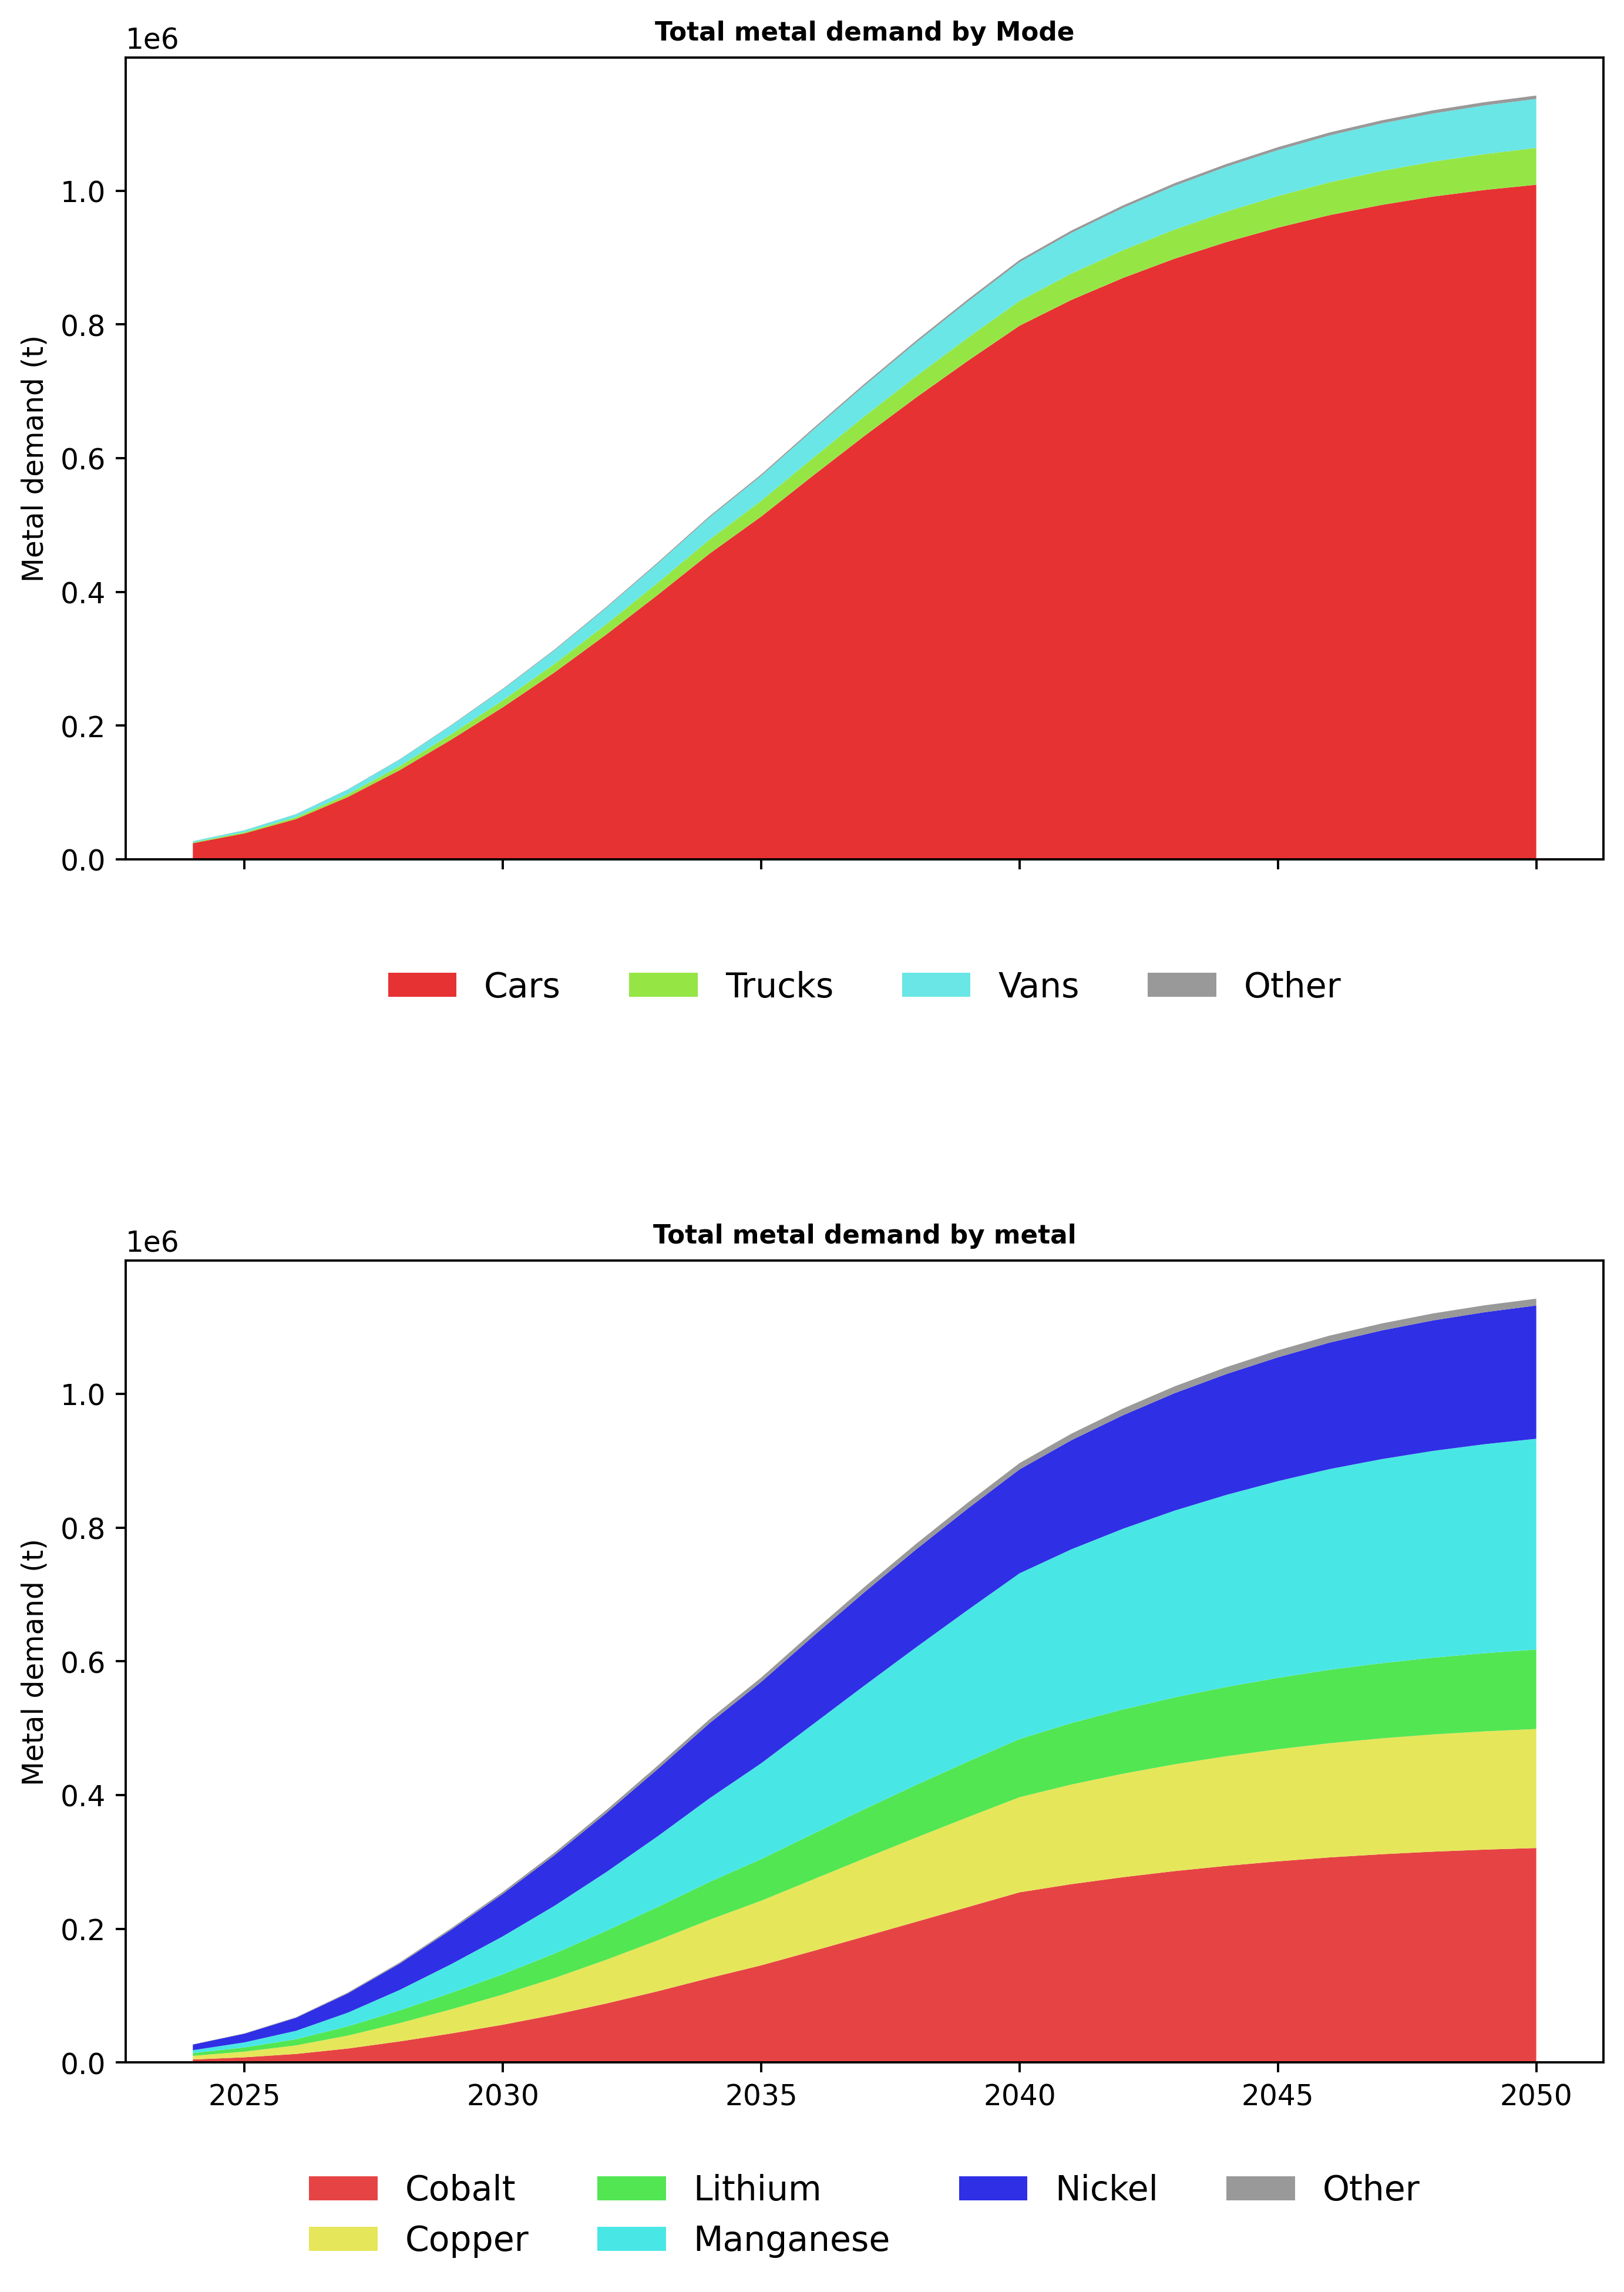

In [54]:
plot_metal_demand_stackplots(metal_demand_ev_battery_nz, variable_col="Mode", savepath="results/EVs_battery/metal_demand_ev_stackplot_by_mode")

# EVs - Vehicle body

## Vehicules en circulation from QC

In [55]:
df_veh_qc = pd.read_csv(r'data/EVs/Vehicule_En_Circulation_2022.csv', index_col=False)

In [56]:
# Define as float
df_veh_qc['ANNEE_MOD'] = pd.to_numeric(df_veh_qc['ANNEE_MOD'], errors='coerce')
df_veh_qc['MASSE_NETTE'] = pd.to_numeric(df_veh_qc['MASSE_NETTE'], errors='coerce')
df_veh_qc = df_veh_qc[df_veh_qc['ANNEE_MOD'] > 2020]
df_veh_qc

,AN,NOSEQ_VEH,CLAS,TYP_VEH_CATEG_USA,MARQ_VEH,MODEL_VEH,ANNEE_MOD,MASSE_NETTE,NB_CYL,CYL_VEH,NB_ESIEU_MAX,COUL_ORIG,TYP_CARBU,REG_ADM,MRC,CG_FIXE
15,2022,2022_0000000016,CAU,AU,AUDI,Q5,2022.0,1798.0,4.0,2000.0,NaN,BLE,E,Laval (13),Laval (65 ),65005.0
18,2022,2022_0000000019,CAU,AU,NISSA,LEAF,2021.0,1746.0,NaN,NaN,NaN,BLA,L,Montérégie (16),Longueuil (58 ),58227.0
21,2022,2022_0000000022,PAU,AU,NISSA,KICKS,2021.0,1204.0,4.0,1607.0,NaN,GRI,E,Montérégie (16),Beauharnois-Salaberry (70 ),70052.0
27,2022,2022_0000000028,PAU,AU,TOYOT,RAV4,2021.0,1635.0,4.0,2509.0,NaN,VER,E,Outaouais (07),Gatineau (81 ),81017.0
30,2022,2022_0000000031,PHM,HM,THOR,TELLA,2022.0,3226.0,6.0,3608.0,NaN,NaN,E,Montérégie (16),Longueuil (58 ),58227.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7058561,2022,2022_0007058562,PAU,AU,TOYOT,RAV4,2021.0,1580.0,4.0,2509.0,NaN,BLA,E,Gaspésie–Îles-de-la-Madeleine (11),Com.maritime ÎlesDeLaMadeleine (01 ),1023.0
7058562,2022,2022_0007058563,PAU,AU,INFIN,Q50,2021.0,1760.0,6.0,3001.0,NaN,NaN,E,Laval (13),Laval (65 ),65005.0
7058587,2022,2022_0007058588,PAU,AU,BMW,X5,2021.0,2561.0,6.0,3001.0,NaN,NOI,W,Montréal (06),Montréal (66 ),66023.0
7058592,2022,2022_0007058593,CAU,AU,SUBAR,ASCEN,2022.0,2005.0,4.0,2394.0,NaN,BLA,E,Montréal (06),Montréal (66 ),66112.0


In [57]:
from utils.constants import CLAS, TYP_CARBU

In [58]:
df_veh_qc['CLAS'] = df_veh_qc['CLAS'].map(CLAS)
df_veh_qc['TYP_CARBU'] = df_veh_qc['TYP_CARBU'].map(TYP_CARBU)

In [59]:
df_veh_qc_ev = df_veh_qc[df_veh_qc['TYP_CARBU'] == 'Électricité']
col_to_keep = ['AN', 'CLAS', 'MARQ_VEH', 'MODEL_VEH', 'ANNEE_MOD', 'MASSE_NETTE', 'TYP_CARBU']
df_veh_qc_ev = df_veh_qc_ev[col_to_keep]

C:\Users\mp_ma\OneDrive - polymtl\POST_DOC\CODE\fasc_metal_sustainability\utils\visualisations.py:378: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col_clas, y=col_mass, data=df, showfliers=False, palette="Set3")


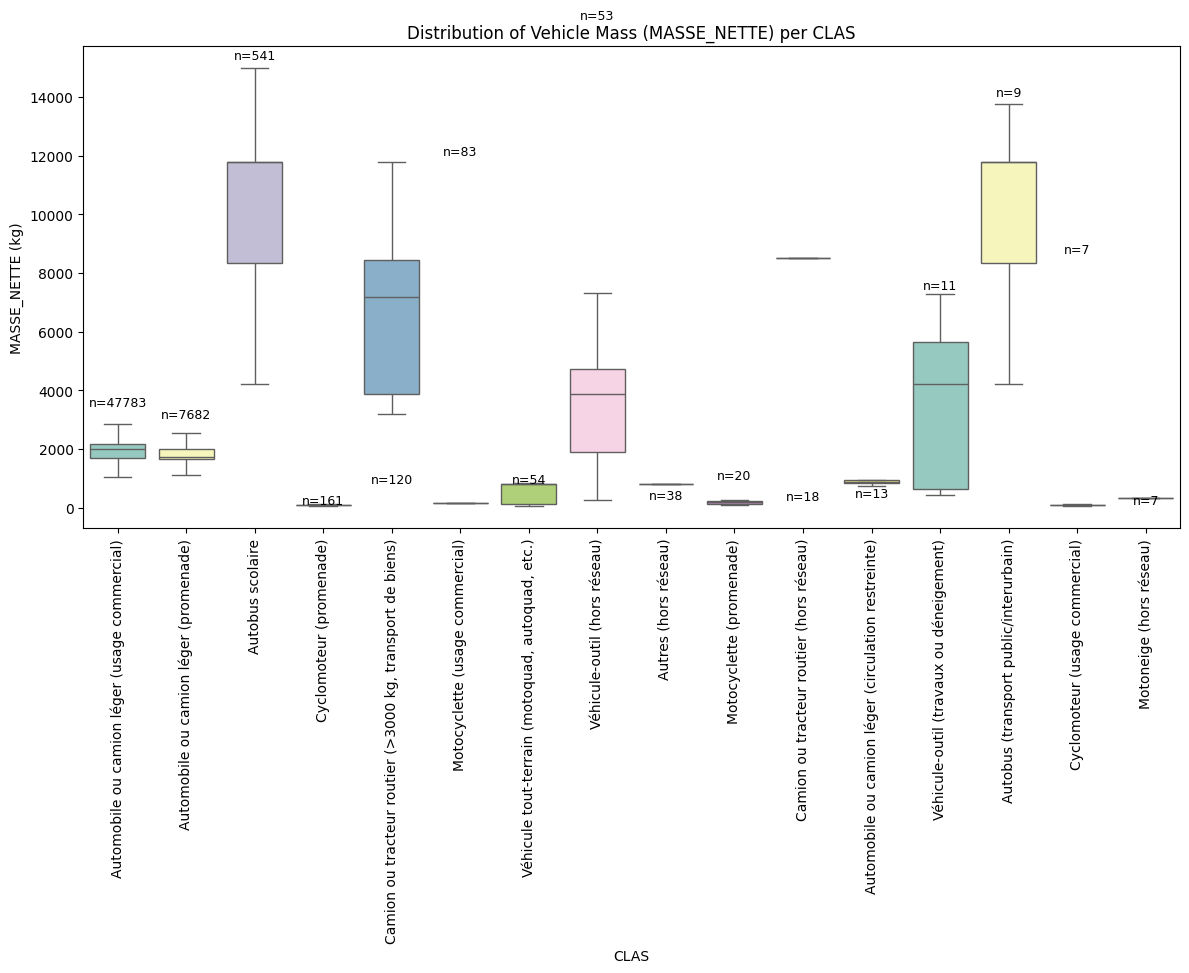

In [60]:
df_veh_qc_ev_mass = plot_masse_stats_per_clas(df_veh_qc_ev)

In [61]:
df_veh_qc_ev_mass

,Mean,Median,Min,Max,Count,Q25,Q75
CLAS,,,,,,,
Autobus scolaire,10332.576710,11793.0,2313.0,14982.0,541,8350.0,11793.0
Autobus (transport public/interurbain),10056.333333,11793.0,4200.0,13753.0,9,8350.0,11793.0
Camion ou tracteur routier (hors réseau),8513.000000,8513.0,8513.0,8513.0,7,8513.0,8513.0
"Camion ou tracteur routier (>3000 kg, transport de biens)",6716.855422,7180.0,3201.0,11793.0,83,3879.0,8430.0
Véhicule-outil (hors réseau),3928.660377,3870.0,259.0,16329.0,53,1902.0,4720.0
Véhicule-outil (travaux ou déneigement),3564.363636,4210.0,414.0,7300.0,11,628.5,5650.0
Automobile ou camion léger (usage commercial),2014.812549,2003.0,736.0,2992.0,7682,1707.0,2173.0
Automobile ou camion léger (promenade),1820.642195,1740.0,1000.0,3402.0,47783,1640.0,2003.0
Automobile ou camion léger (circulation restreinte),862.750000,863.0,748.0,940.0,20,823.0,940.0


## Estimate material demand

In [62]:
evs_body_mi_mapping = { # From Powertrain to Technology, Sub-technology
    "BEV": [("Vehicle body, BEV", 1.0)],
    "FCEV": [("Vehicle body, ICEV", 1.0)],
    "PHEV": [("Vehicle body, PHEV", 1.0)]
}

In [63]:
material_demand_ev_body = calculate_metal_demand_ev_body(projected_ev_sales_df, mi_df, mapping_dict=evs_body_mi_mapping, main_var="EV_sales")

In [64]:
material_demand_ev_body

,Country,Mode,Powertrain,Year,EV_sales,Mass_vehicule,Scenario,Technology,Sub-technology,Metal,Metal intensity (g/vehicle),Metal_demand_t,Fiability_used,Comment
0,Canada,2 and 3 wheelers,BEV,2024,170.000000,0.098086,Current Measures,Vehicle body,BEV,Aluminum,127302.00,2.122706,No comparison,None
1,Canada,2 and 3 wheelers,BEV,2024,170.000000,0.098086,Current Measures,Vehicle body,BEV,Chromium,11850.00,0.197594,No comparison,None
2,Canada,2 and 3 wheelers,BEV,2024,170.000000,0.098086,Current Measures,Vehicle body,BEV,Iron,902171.34,15.043317,No comparison,None
3,Canada,2 and 3 wheelers,BEV,2024,170.000000,0.098086,Current Measures,Vehicle body,BEV,Lead,310.00,0.005169,No comparison,None
4,Canada,2 and 3 wheelers,BEV,2024,170.000000,0.098086,Current Measures,Vehicle body,BEV,Zinc,100.00,0.001667,No comparison,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3802,Canada,Vans,PHEV,2050,291014.359845,1.957751,Global Net-zero,Vehicle body,PHEV,Aluminum,110658.00,63045.578877,No comparison,None
3803,Canada,Vans,PHEV,2050,291014.359845,1.957751,Global Net-zero,Vehicle body,PHEV,Chromium,12789.00,7286.322799,No comparison,None
3804,Canada,Vans,PHEV,2050,291014.359845,1.957751,Global Net-zero,Vehicle body,PHEV,Iron,902171.34,513997.310423,No comparison,None
3805,Canada,Vans,PHEV,2050,291014.359845,1.957751,Global Net-zero,Vehicle body,PHEV,Lead,320.00,182.314747,No comparison,None


In [65]:
material_demand_ev_body_nz = material_demand_ev_body[material_demand_ev_body['Scenario'] == 'Canada Net-zero']
material_demand_ev_body_step = material_demand_ev_body[material_demand_ev_body['Scenario'] == 'Canada Current Measures']

In [66]:
metal_demand_ev_body = material_demand_ev_body[~material_demand_ev_body['Metal'].isin(non_metals)]
metal_demand_ev_body_nz = metal_demand_ev_body[metal_demand_ev_body['Scenario'] == 'Canada Net-zero']
metal_demand_ev_body_step = metal_demand_ev_body[metal_demand_ev_body['Scenario'] == 'Canada Current Measures']

In [67]:
material_demand_ev_body.to_csv(r'results/EVs_body/material_demand_ev_body.csv', index=False)
metal_demand_ev_body.to_csv(r'results/EVs_body/metal_demand_ev_body.csv', index=False)

In [68]:
metal_demand_ev_body_nz

,Country,Mode,Powertrain,Year,EV_sales,Mass_vehicule,Scenario,Technology,Sub-technology,Metal,Metal intensity (g/vehicle),Metal_demand_t,Fiability_used,Comment
1269,Canada,2 and 3 wheelers,BEV,2024,170.000000,0.098086,Canada Net-zero,Vehicle body,BEV,Aluminum,127302.00,2.122706,No comparison,None
1270,Canada,2 and 3 wheelers,BEV,2024,170.000000,0.098086,Canada Net-zero,Vehicle body,BEV,Chromium,11850.00,0.197594,No comparison,None
1271,Canada,2 and 3 wheelers,BEV,2024,170.000000,0.098086,Canada Net-zero,Vehicle body,BEV,Iron,902171.34,15.043317,No comparison,None
1272,Canada,2 and 3 wheelers,BEV,2024,170.000000,0.098086,Canada Net-zero,Vehicle body,BEV,Lead,310.00,0.005169,No comparison,None
1273,Canada,2 and 3 wheelers,BEV,2024,170.000000,0.098086,Canada Net-zero,Vehicle body,BEV,Zinc,100.00,0.001667,No comparison,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2533,Canada,Vans,PHEV,2050,307966.414002,1.957751,Canada Net-zero,Vehicle body,PHEV,Aluminum,110658.00,66718.085169,No comparison,None
2534,Canada,Vans,PHEV,2050,307966.414002,1.957751,Canada Net-zero,Vehicle body,PHEV,Chromium,12789.00,7710.762812,No comparison,None
2535,Canada,Vans,PHEV,2050,307966.414002,1.957751,Canada Net-zero,Vehicle body,PHEV,Iron,902171.34,543938.479813,No comparison,None
2536,Canada,Vans,PHEV,2050,307966.414002,1.957751,Canada Net-zero,Vehicle body,PHEV,Lead,320.00,192.934874,No comparison,None


## Plots

In [69]:
#plot_metal_demand_facets(metal_demand_ev_body_nz, variable_col='Mode', savepath="results/EVs_body/metal_demand_ev_facets_by_mode")

✅ Figure saved to results/EVs_body/metal_demand_ev_stackplot_by_mode.png and .svg


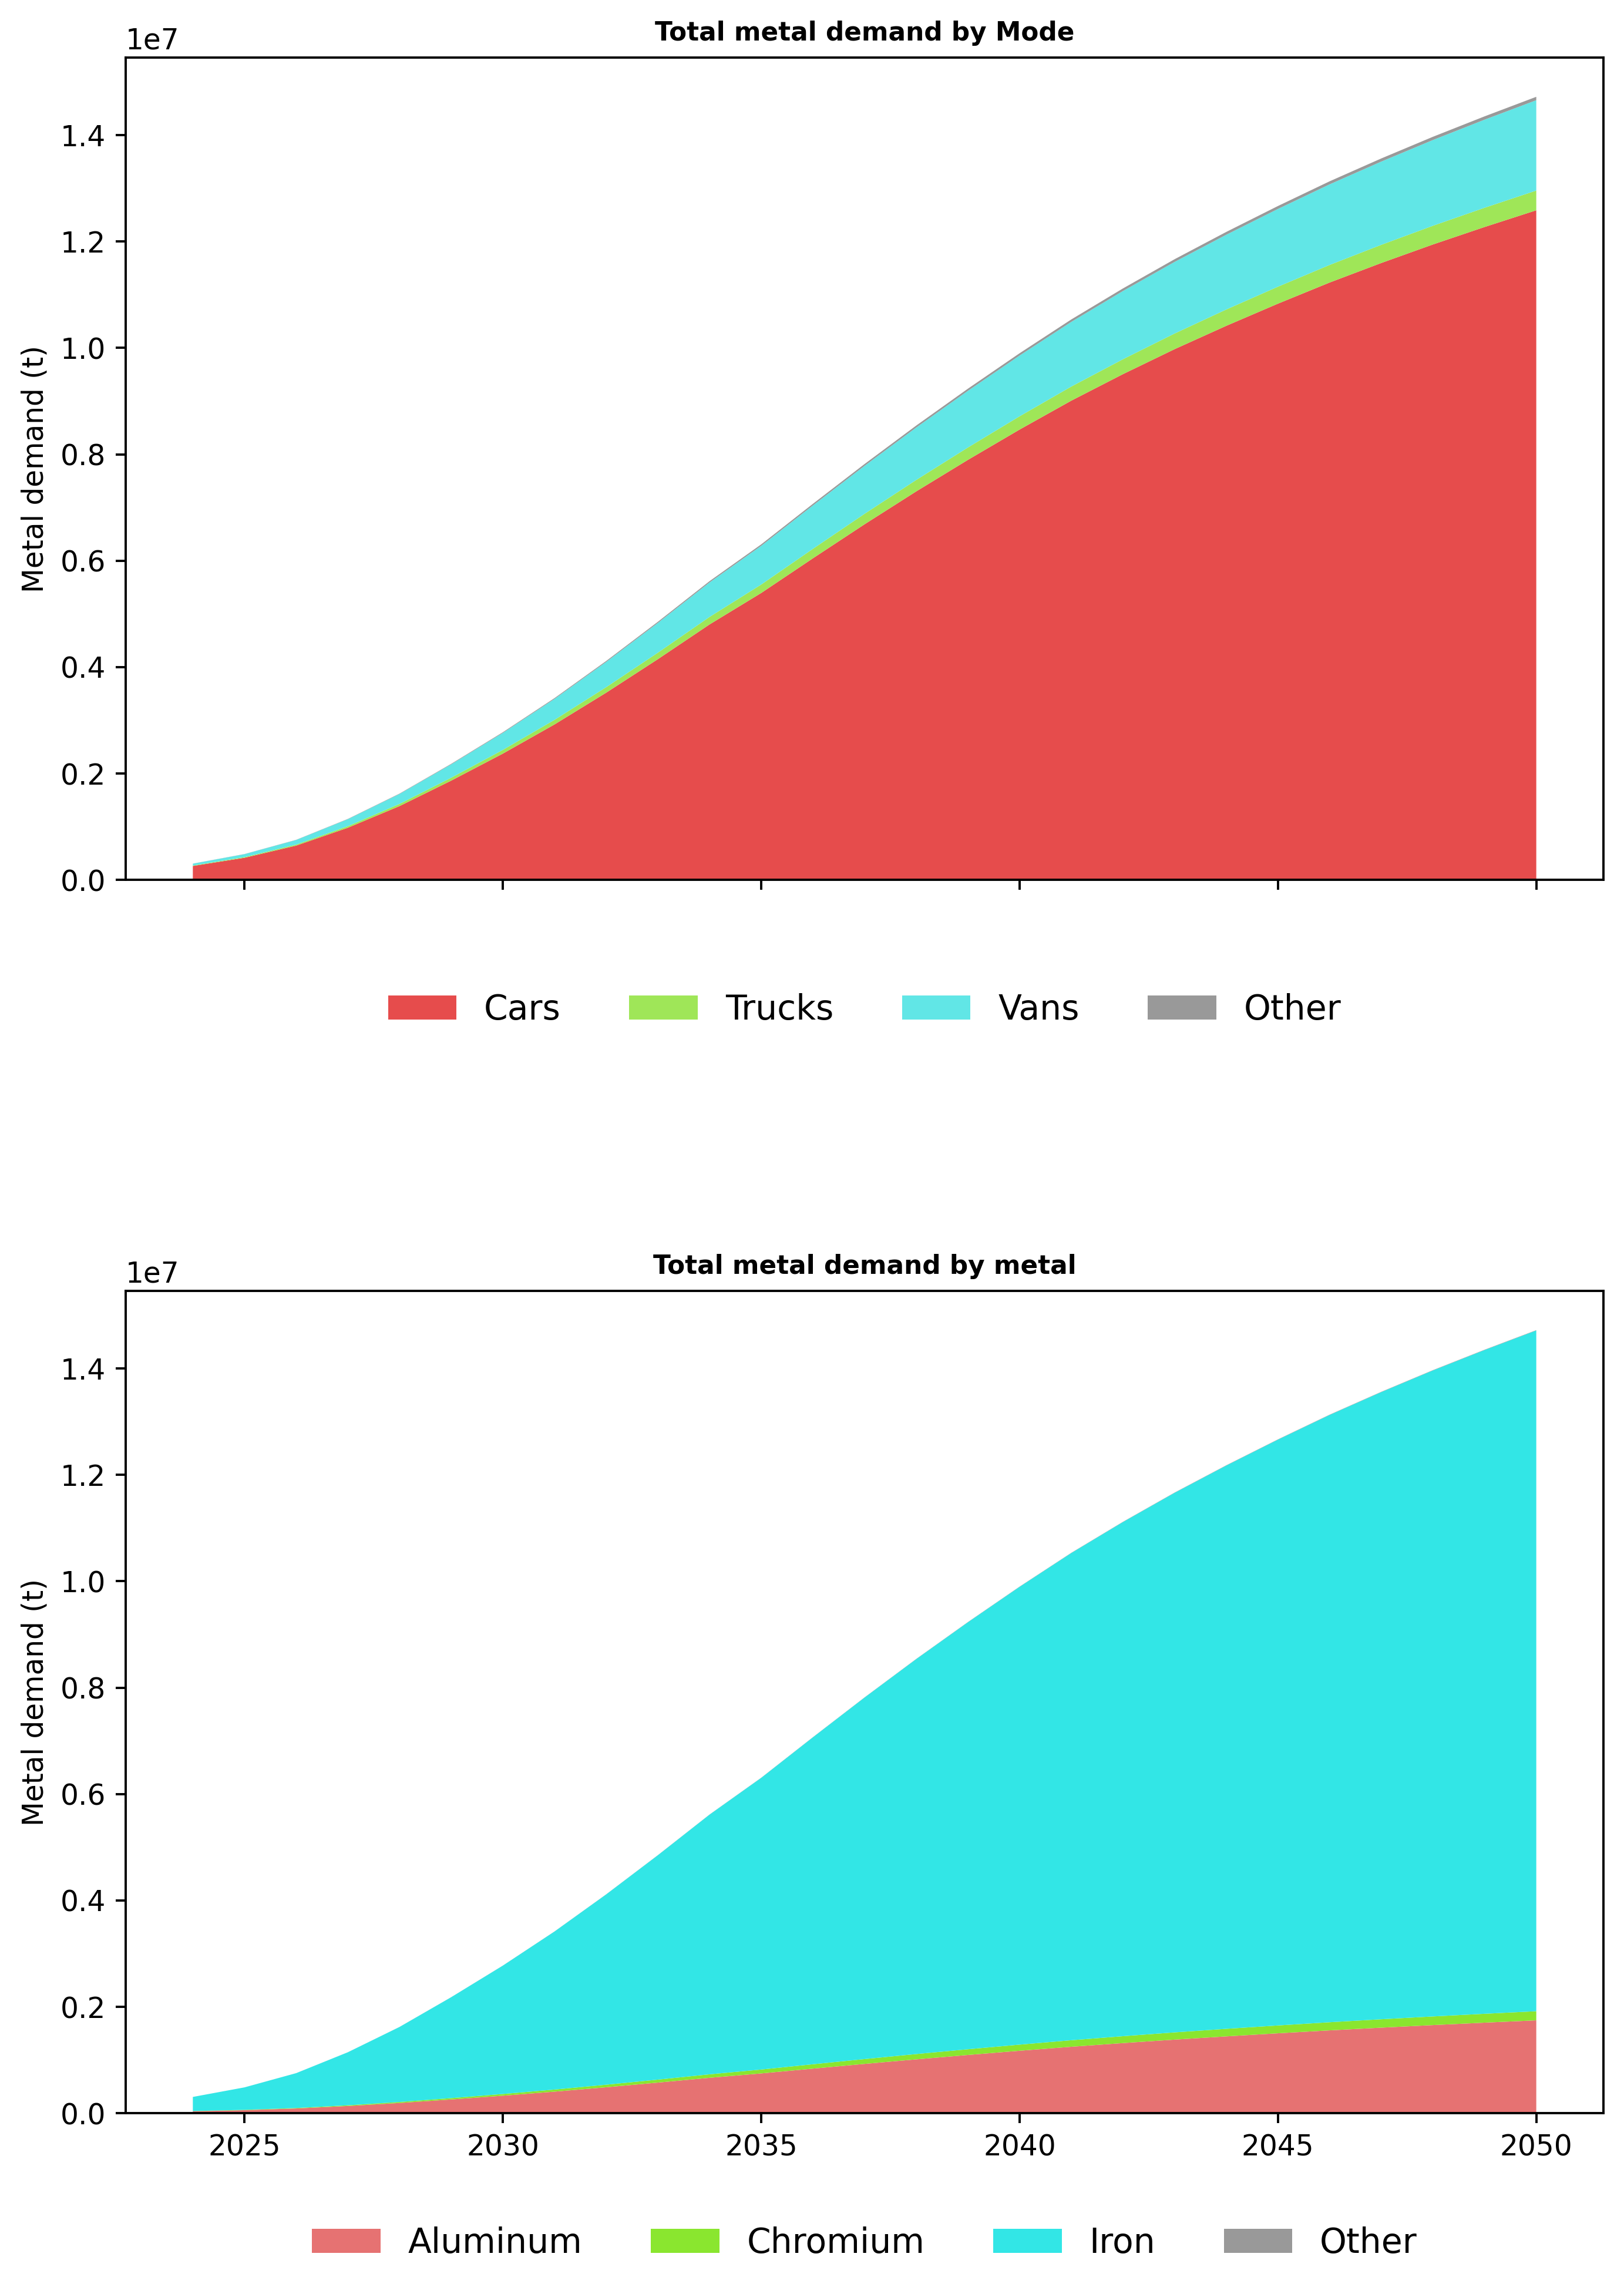

In [70]:
plot_metal_demand_stackplots(metal_demand_ev_body_nz, variable_col="Mode", savepath="results/EVs_body/metal_demand_ev_stackplot_by_mode")

# EVs - Battery motor

## Estimate material demand

In [71]:
mi_df_motor = mi_df[
    (mi_df['Technology'] == 'Vehicle motor') &
    (mi_df['Unit'] == 'g/vehicle')
]
mi_df_motor

,Technology,Sub-technology,Metal,Metal intensity,Unit,Reference,Fiability of the data,Comment
620,Vehicle motor,Ind,Copper,33673.5,g/vehicle,"(Månberger & Stenqvist, 2018)",No comparison,NaN
622,Vehicle motor,PM,Copper,13884.5,g/vehicle,"(Månberger & Stenqvist, 2018)",No comparison,NaN
626,Vehicle motor,PM,Dysprosium,83.0,g/vehicle,"(Watari et al., 2018)",Variability in data,NaN
629,Vehicle motor,PM,Neodymium,695.0,g/vehicle,"(Watari et al., 2018)",Small variability in data,NaN
630,Vehicle motor,PM,Praesodymium,1.0,g/vehicle,"(Watari et al., 2018)",No comparison,NaN


In [72]:
evs_body_mi_mapping = { # From Powertrain to Technology, Sub-technology
    "BEV": [("Vehicle motor, PM", 1.0)],
    "FCEV": [("Vehicle motor, PM", 1.0)],
    "PHEV": [("Vehicle motor, PM", 1.0)]
}

In [73]:
metal_demand_ev_motor = calculate_metal_demand_ev_body(projected_ev_sales_df, mi_df_motor, mapping_dict=evs_body_mi_mapping, main_var="EV_sales")

In [74]:
metal_demand_ev_motor_nz = metal_demand_ev_motor[metal_demand_ev_motor['Scenario'] == 'Canada Net-zero']
metal_demand_ev_motor_step = metal_demand_ev_motor[metal_demand_ev_motor['Scenario'] == 'Canada Current Measures']

In [75]:
metal_demand_ev_motor.to_csv(r'results/EVs_motor/metal_demand_ev_motor.csv', index=False)

## Plots

In [76]:
#plot_metal_demand_facets(metal_demand_ev_motor_nz, variable_col='Mode', savepath="results/EVs_motor/metal_demand_ev_facets_by_mode")

✅ Figure saved to results/EVs_motor/metal_demand_ev_stackplot_by_mode.png and .svg


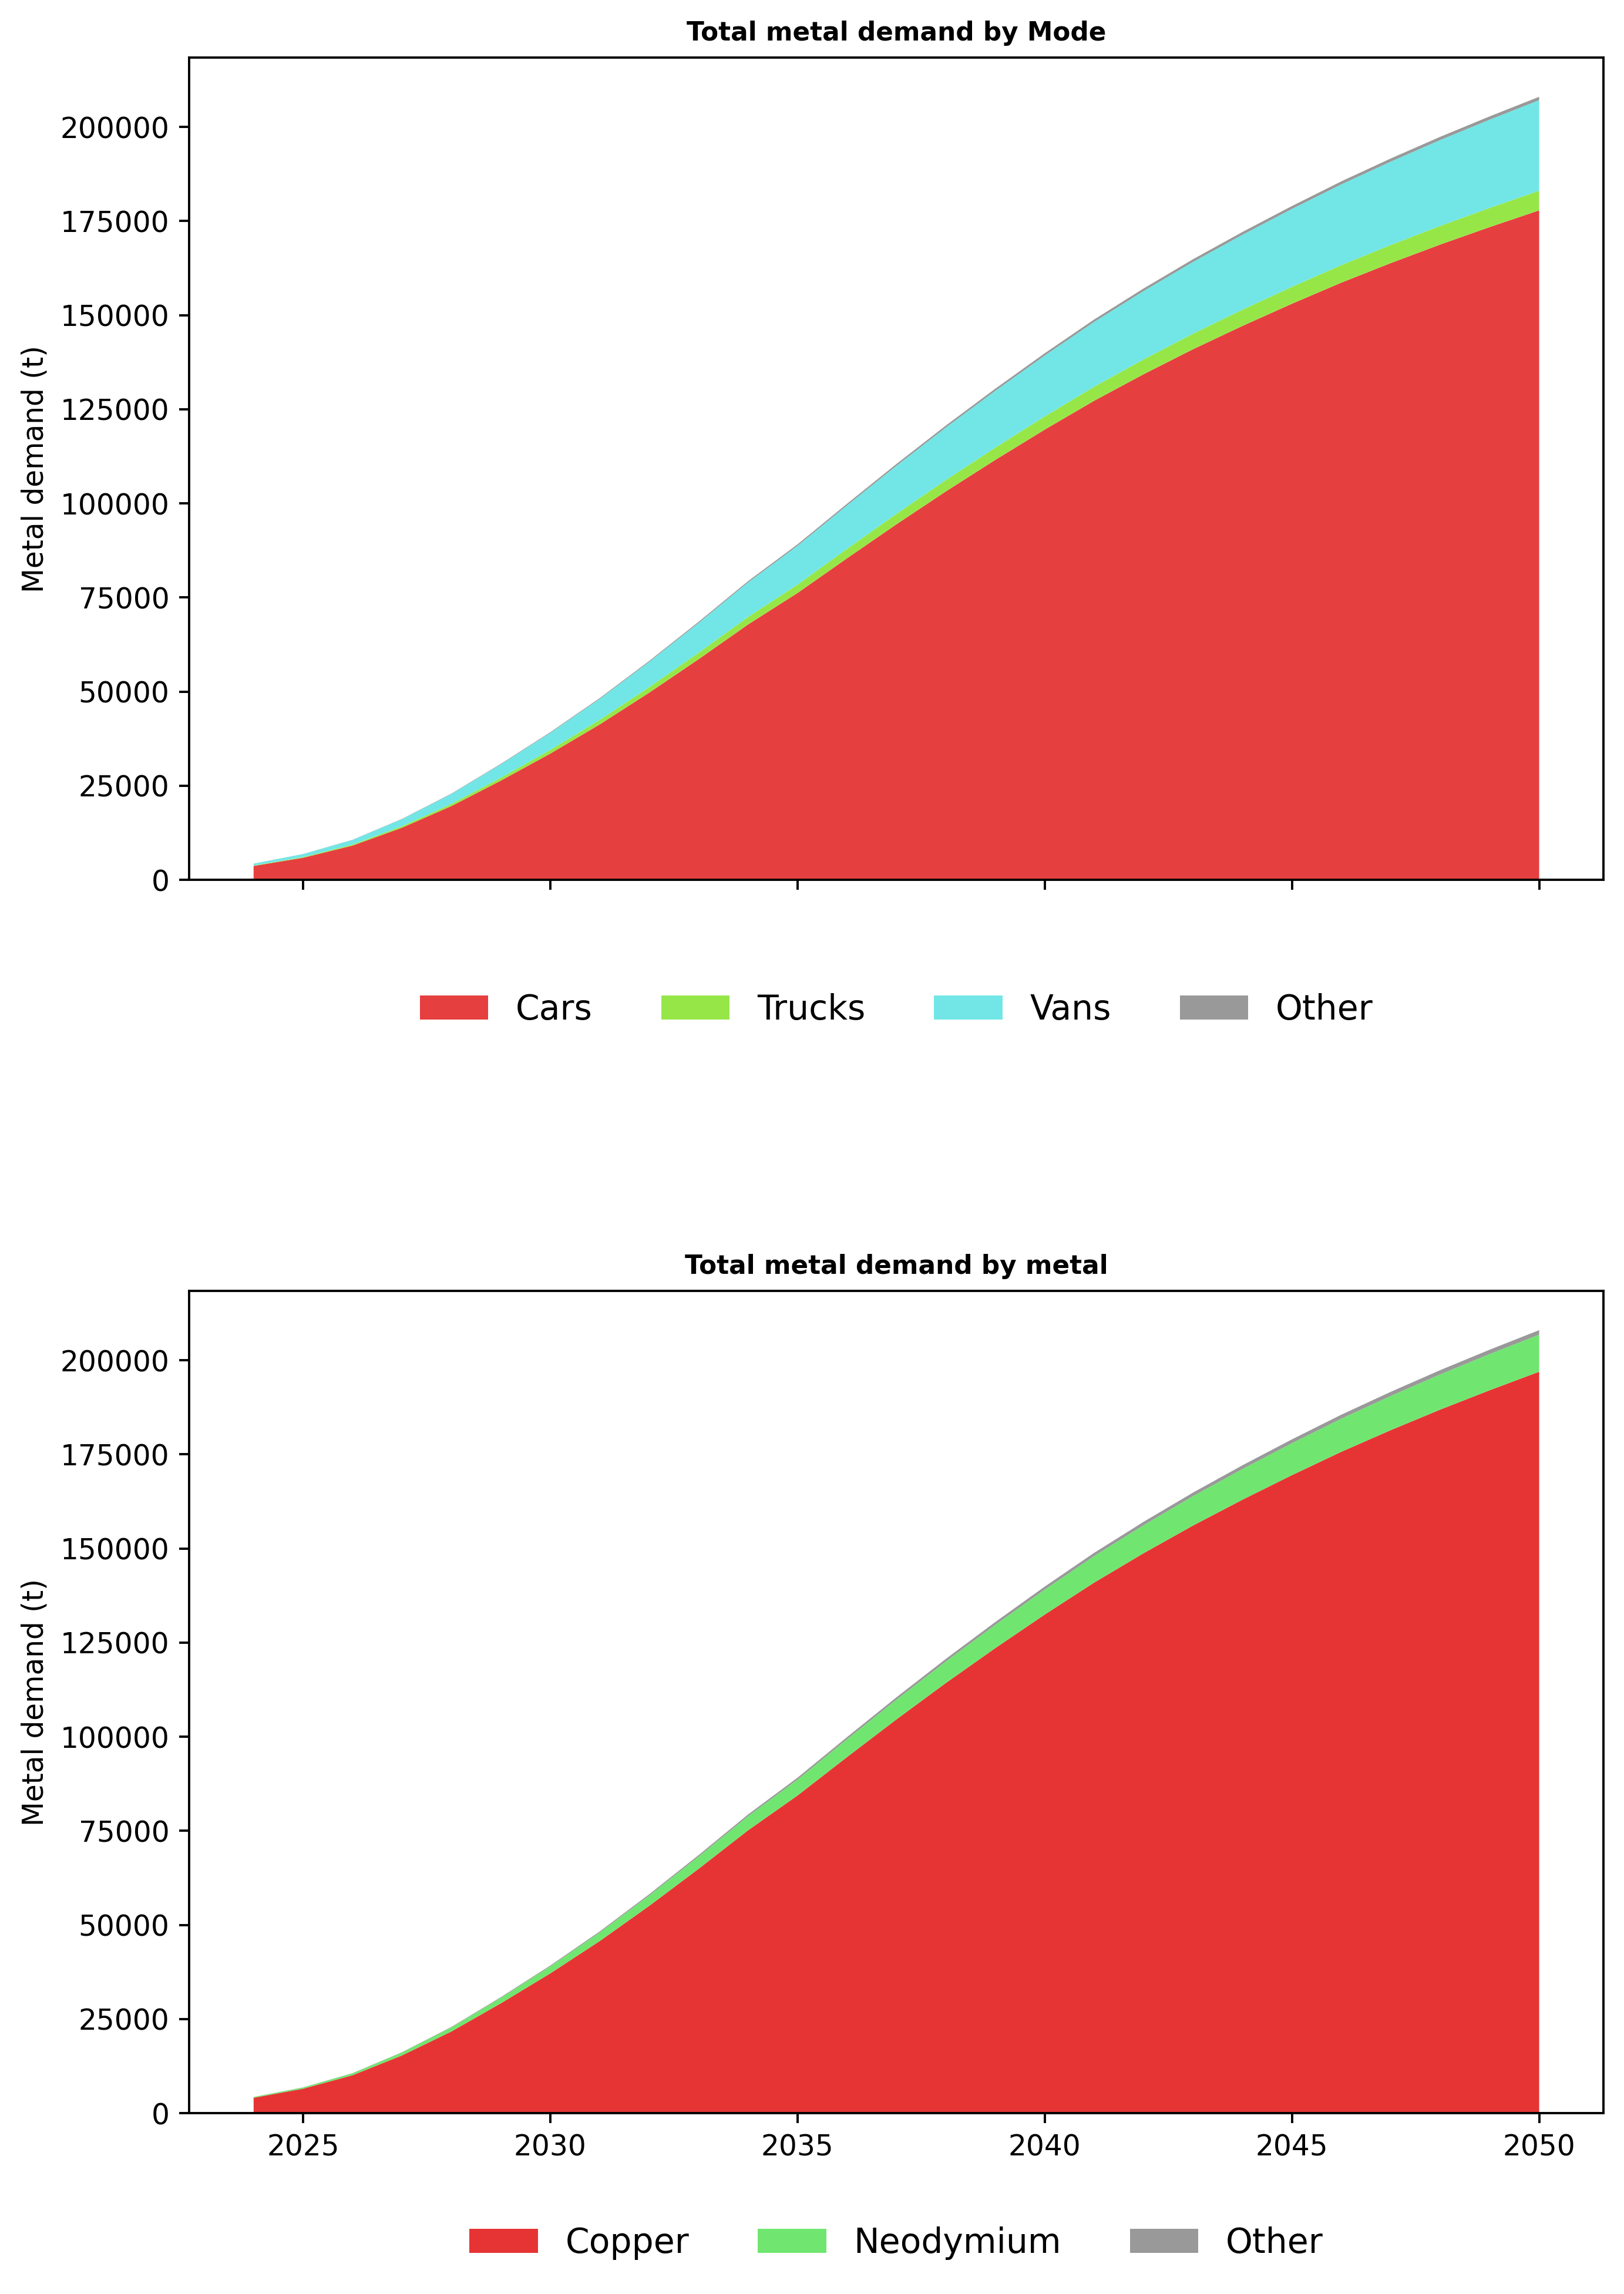

In [77]:
plot_metal_demand_stackplots(metal_demand_ev_motor_nz, variable_col="Mode", savepath="results/EVs_motor/metal_demand_ev_stackplot_by_mode")

# EVs - total

In [78]:
material_demand_ev_battery['Technology'] = 'Vehicle battery'

In [79]:
cols_to_keep = ['Country', 'Scenario', 'Year', 'Technology', 'Mode', 'Powertrain', 'Metal', 'Metal_demand_t']
material_demand_ev_battery_t = material_demand_ev_battery[cols_to_keep]
material_demand_ev_body_t = material_demand_ev_body[cols_to_keep]
material_demand_ev_motor_t = metal_demand_ev_motor[cols_to_keep]

In [80]:
# Put the 3 dfs in a single dfs
material_demand_ev = pd.concat([material_demand_ev_battery_t, material_demand_ev_body_t, material_demand_ev_motor_t], ignore_index=True)

In [81]:
metal_demand_ev = material_demand_ev[~material_demand_ev['Metal'].isin(non_metals)]
metal_demand_ev_nz = metal_demand_ev[metal_demand_ev['Scenario'] == 'Canada Net-zero']
metal_demand_ev_step = metal_demand_ev[metal_demand_ev['Scenario'] == 'Canada Current Measures']

In [82]:
material_demand_ev.to_csv(r'results/EVs/material_demand_ev.csv', index=False)

✅ Saved to results/EVs/metal_demand_ev_facets_by_mode.png / .svg


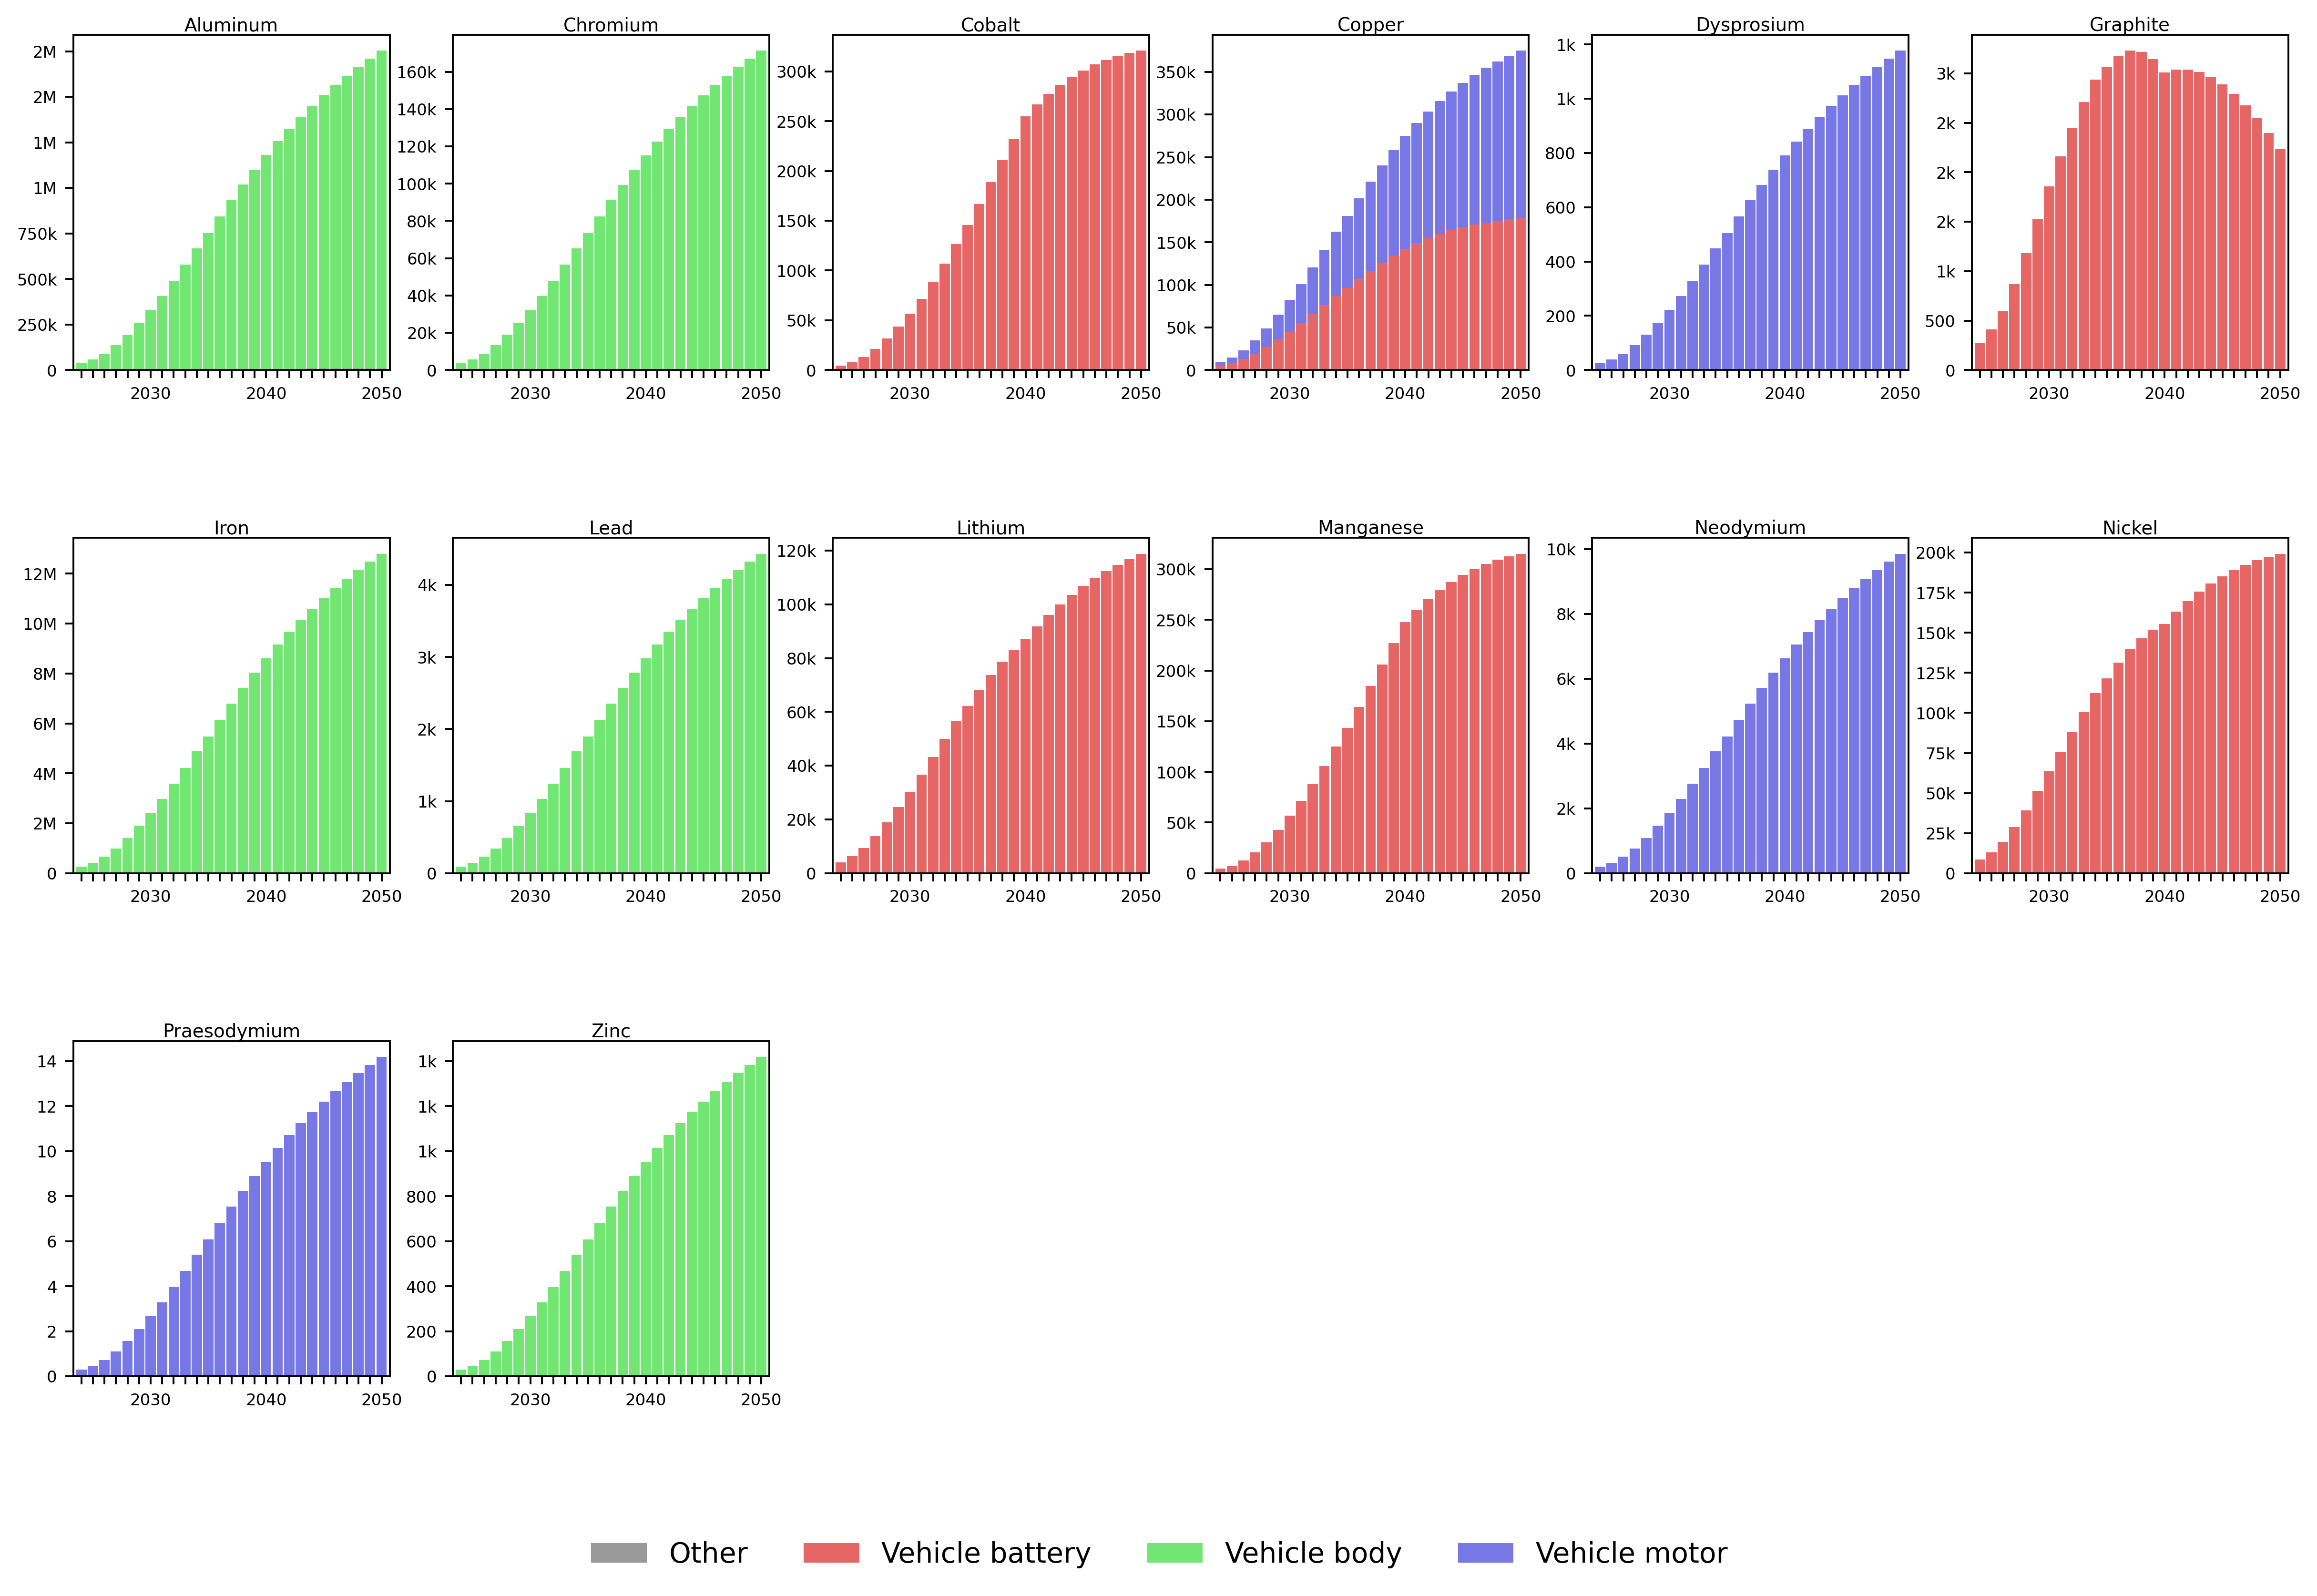

In [83]:
plot_metal_demand_facets(metal_demand_ev_nz, variable_col='Technology', savepath="results/EVs/metal_demand_ev_facets_by_mode")

✅ Figure saved to results/EVs/metal_demand_ev_stackplot_by_mode.png and .svg


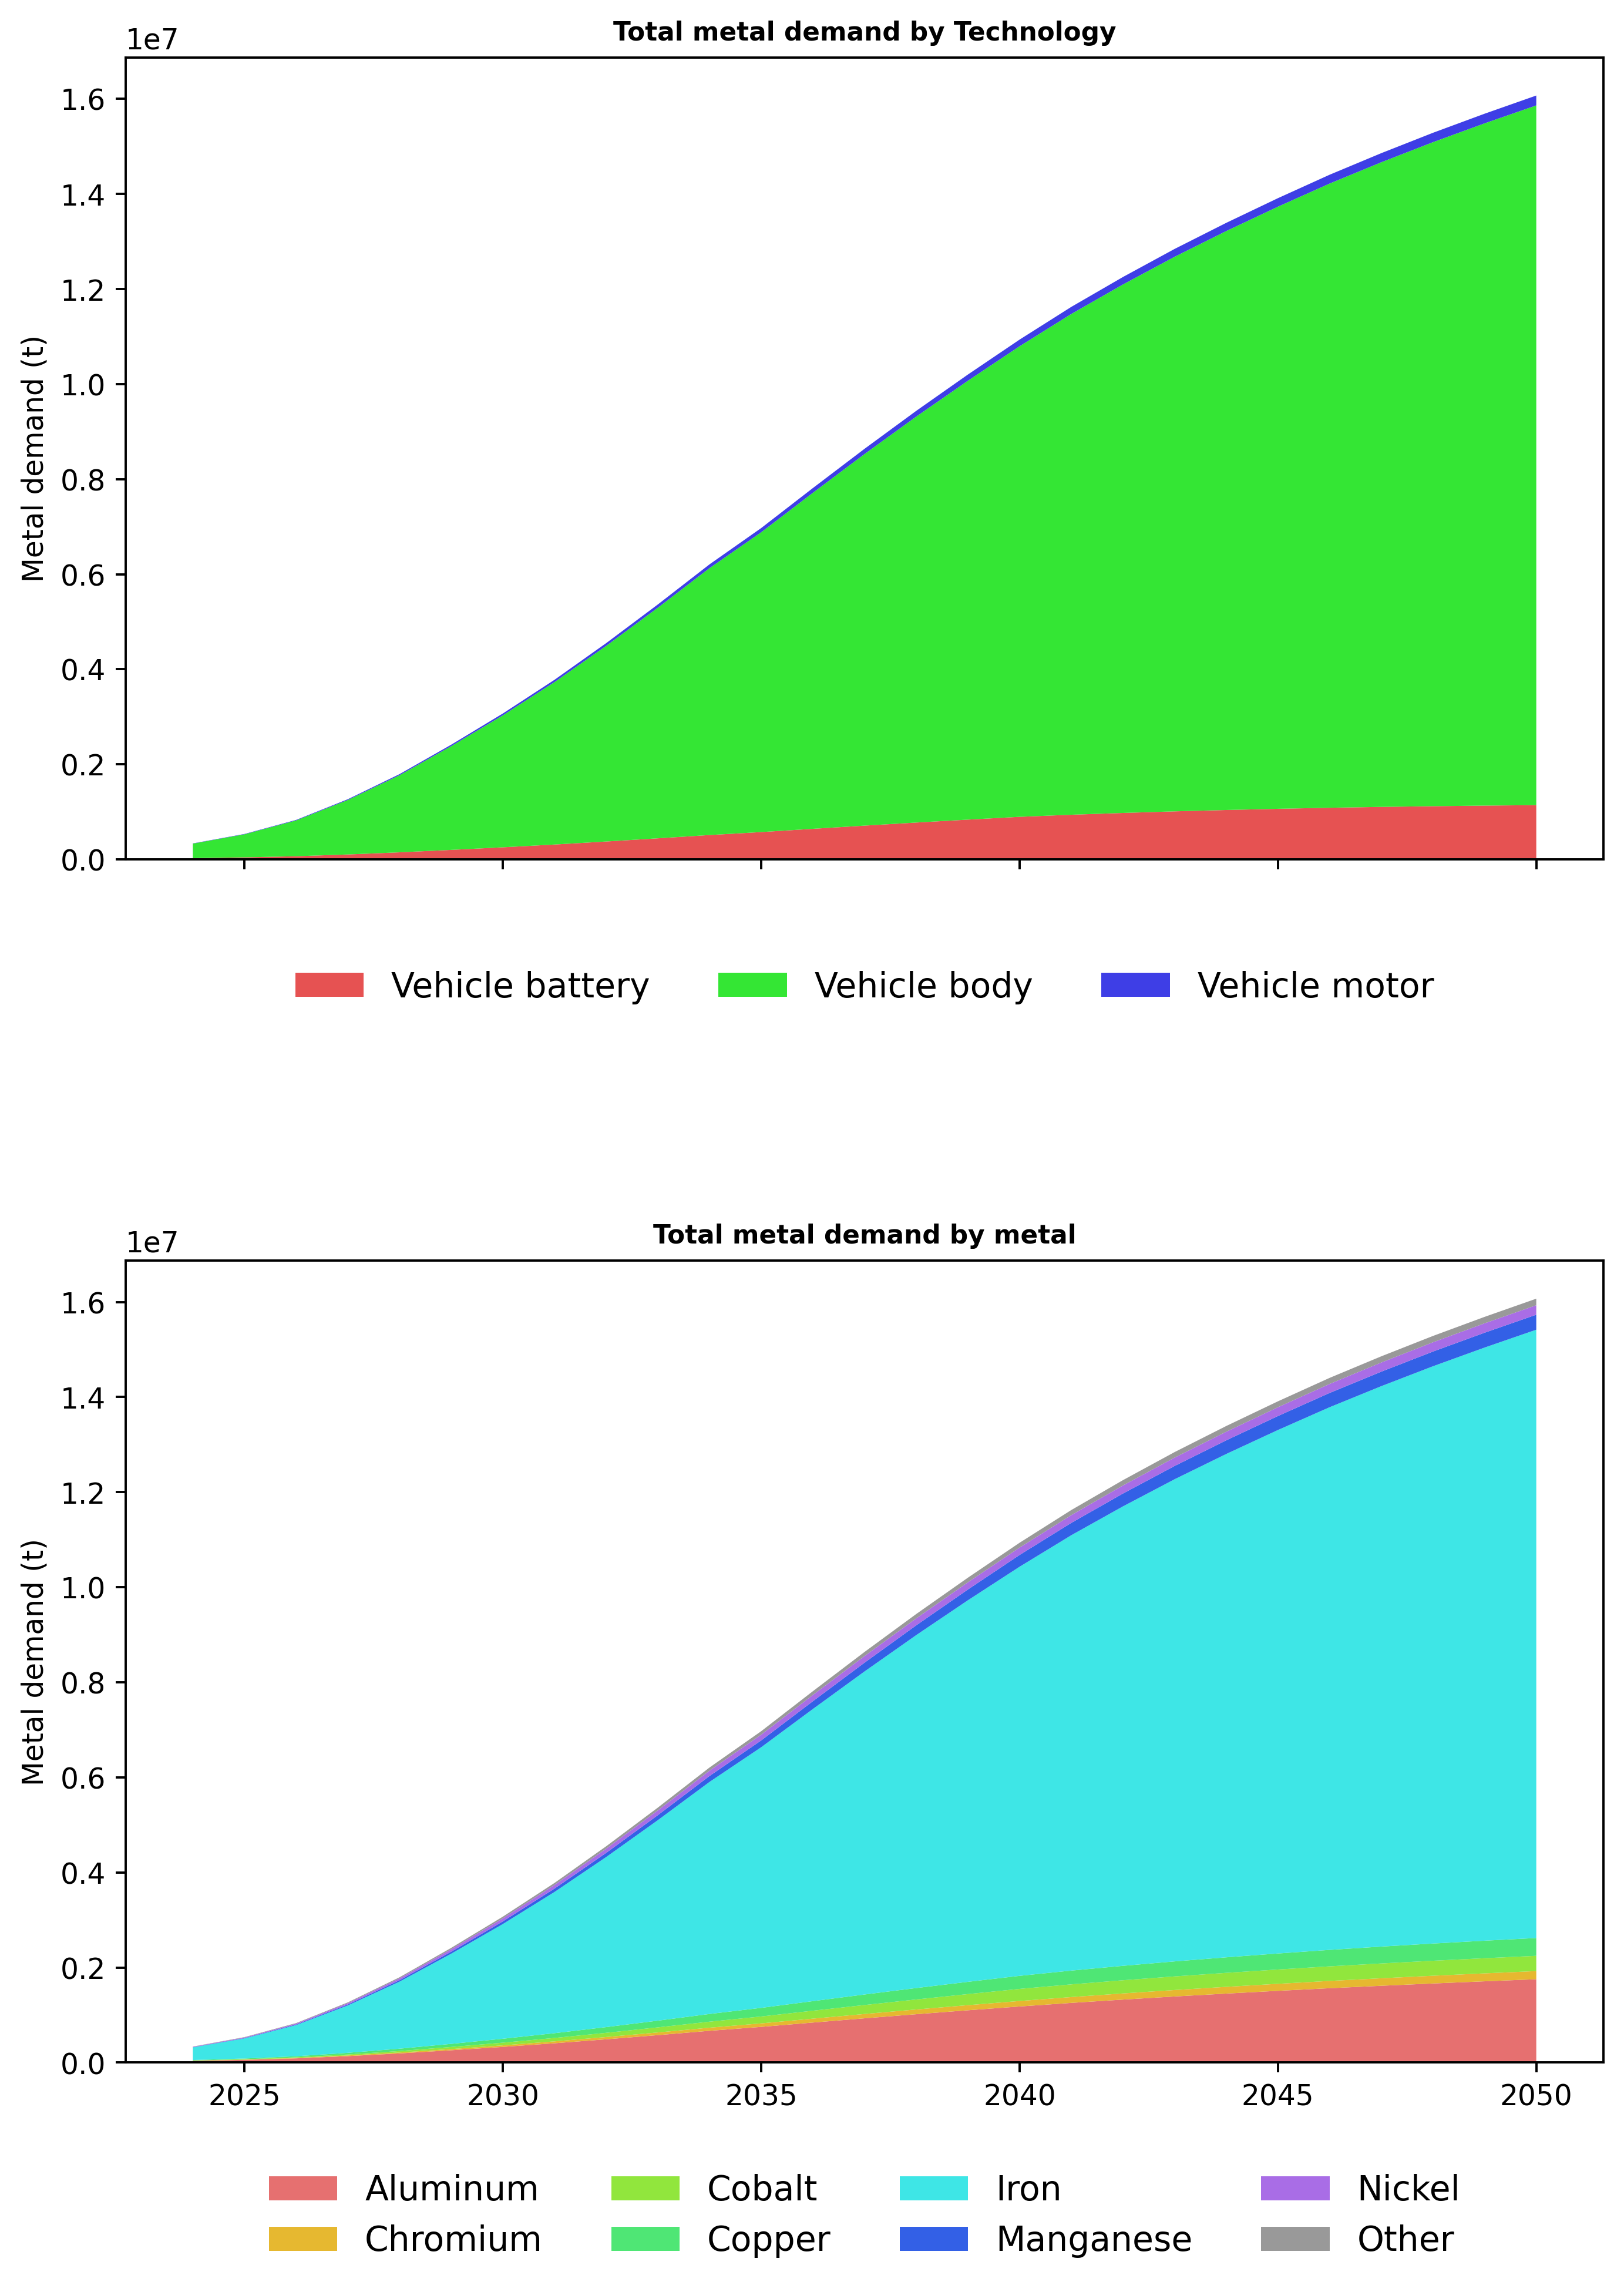

In [84]:
plot_metal_demand_stackplots(metal_demand_ev_nz, variable_col="Technology", savepath="results/EVs/metal_demand_ev_stackplot_by_mode")

# NRJ + EVs

In [85]:
material_demand_nrj = material_demand_nrj.rename(columns={
        'Region': 'Country',
        'Variable': 'Technology'
})

In [86]:
material_demand_nrj['Mode'] = ''
material_demand_nrj['Powertain'] = ''
material_demand_nrj = material_demand_nrj.drop(columns=['Metal intensity (t/GW)', 'Fiability_used', 'Comment'])

In [87]:
material_demand = pd.concat([material_demand_nrj, material_demand_ev], ignore_index=True)

In [88]:
material_demand.to_csv(r'results/NRJ+EVs/material_demand.csv', index=False)

In [89]:
metal_demand = material_demand[~material_demand['Metal'].isin(non_metals)]
metal_demand_nz = metal_demand[metal_demand['Scenario'] == 'Canada Net-zero']
metal_demand_step = metal_demand[metal_demand['Scenario'] == 'Current Measures']

In [90]:
metal_demand_selected = material_demand[material_demand['Metal'].isin(selected_metals)]
metal_demand_selected_nz = metal_demand_selected[metal_demand_selected['Scenario'] == 'Canada Net-zero']
metal_demand_selected_step = metal_demand_selected[metal_demand_selected['Scenario'] == 'Current Measures']

In [91]:
metal_demand_selected.to_csv(r'results/NRJ+EVs/metal_demand_selected.csv', index=False)

In [92]:
metal_demand_nz_without_iron = metal_demand_nz[metal_demand_nz['Metal']!= 'Iron']

✅ Saved to results/NRJ+EVs/metal_demand_facets_nz.png / .svg


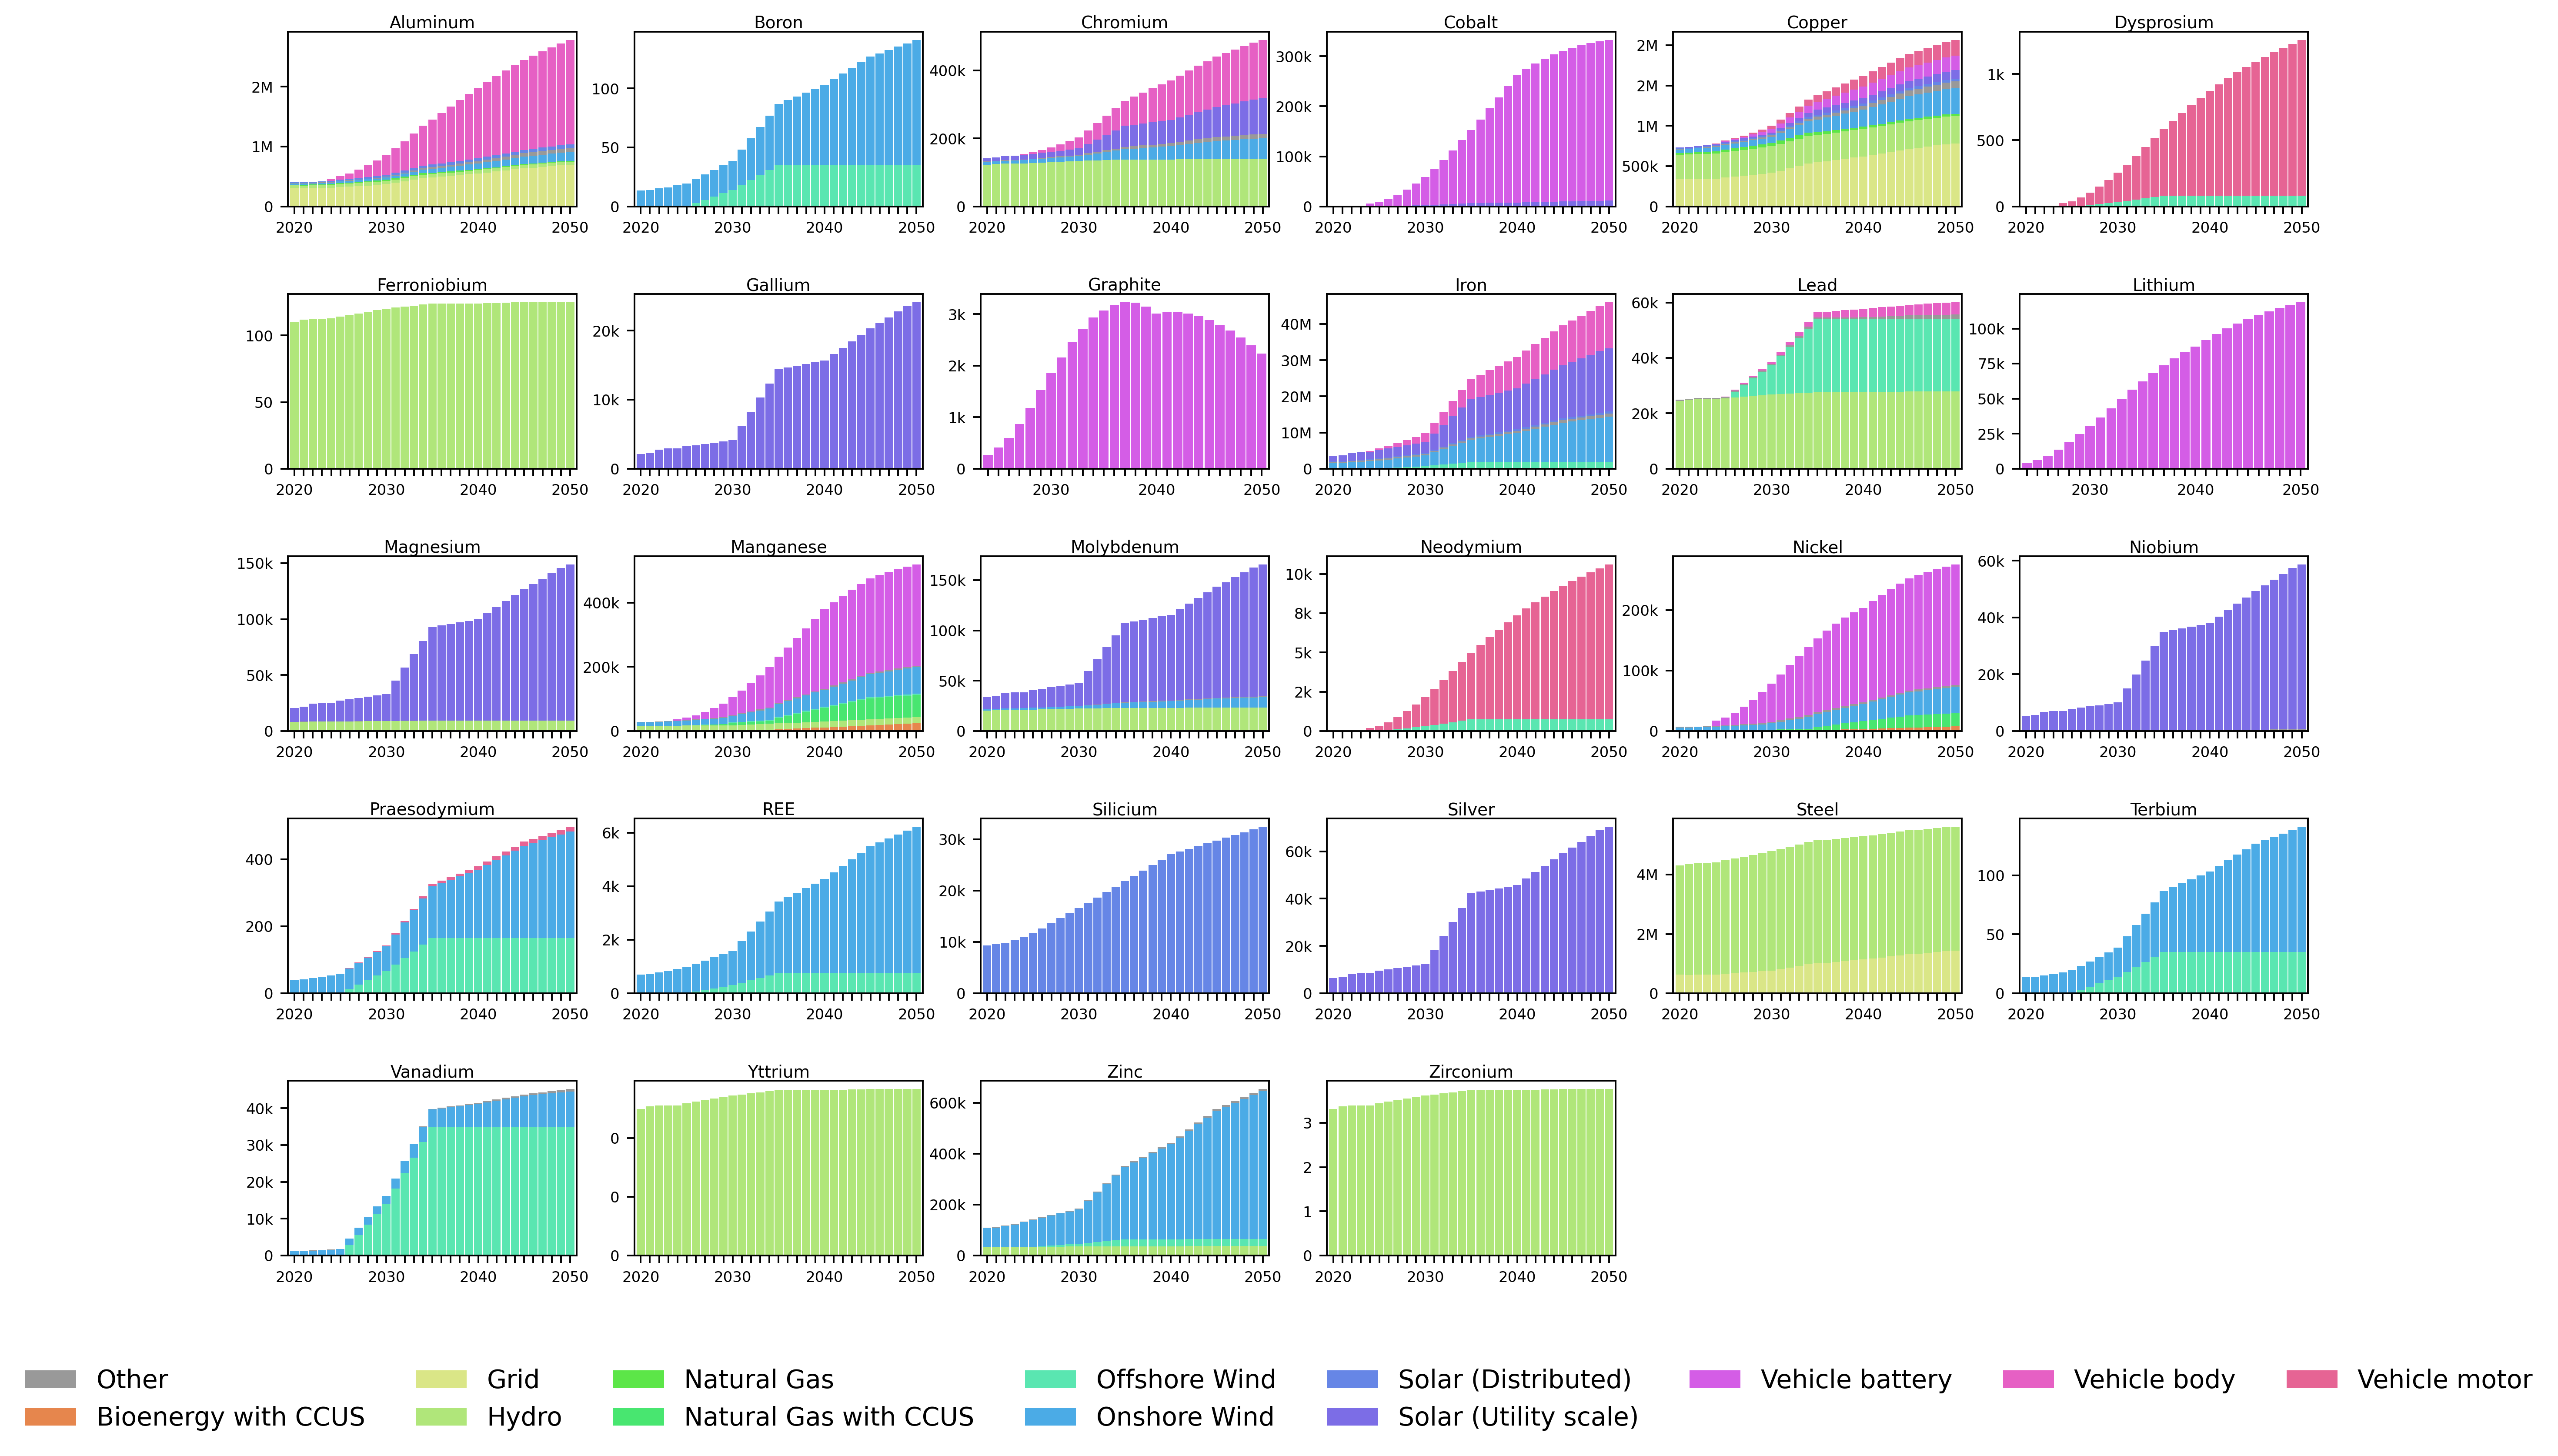

In [93]:
plot_metal_demand_facets(metal_demand_nz, variable_col='Technology', savepath="results/NRJ+EVs/metal_demand_facets_nz")

✅ Figure saved to results/NRJ+EVs/metal_demand_stackplot_nz.png and .svg


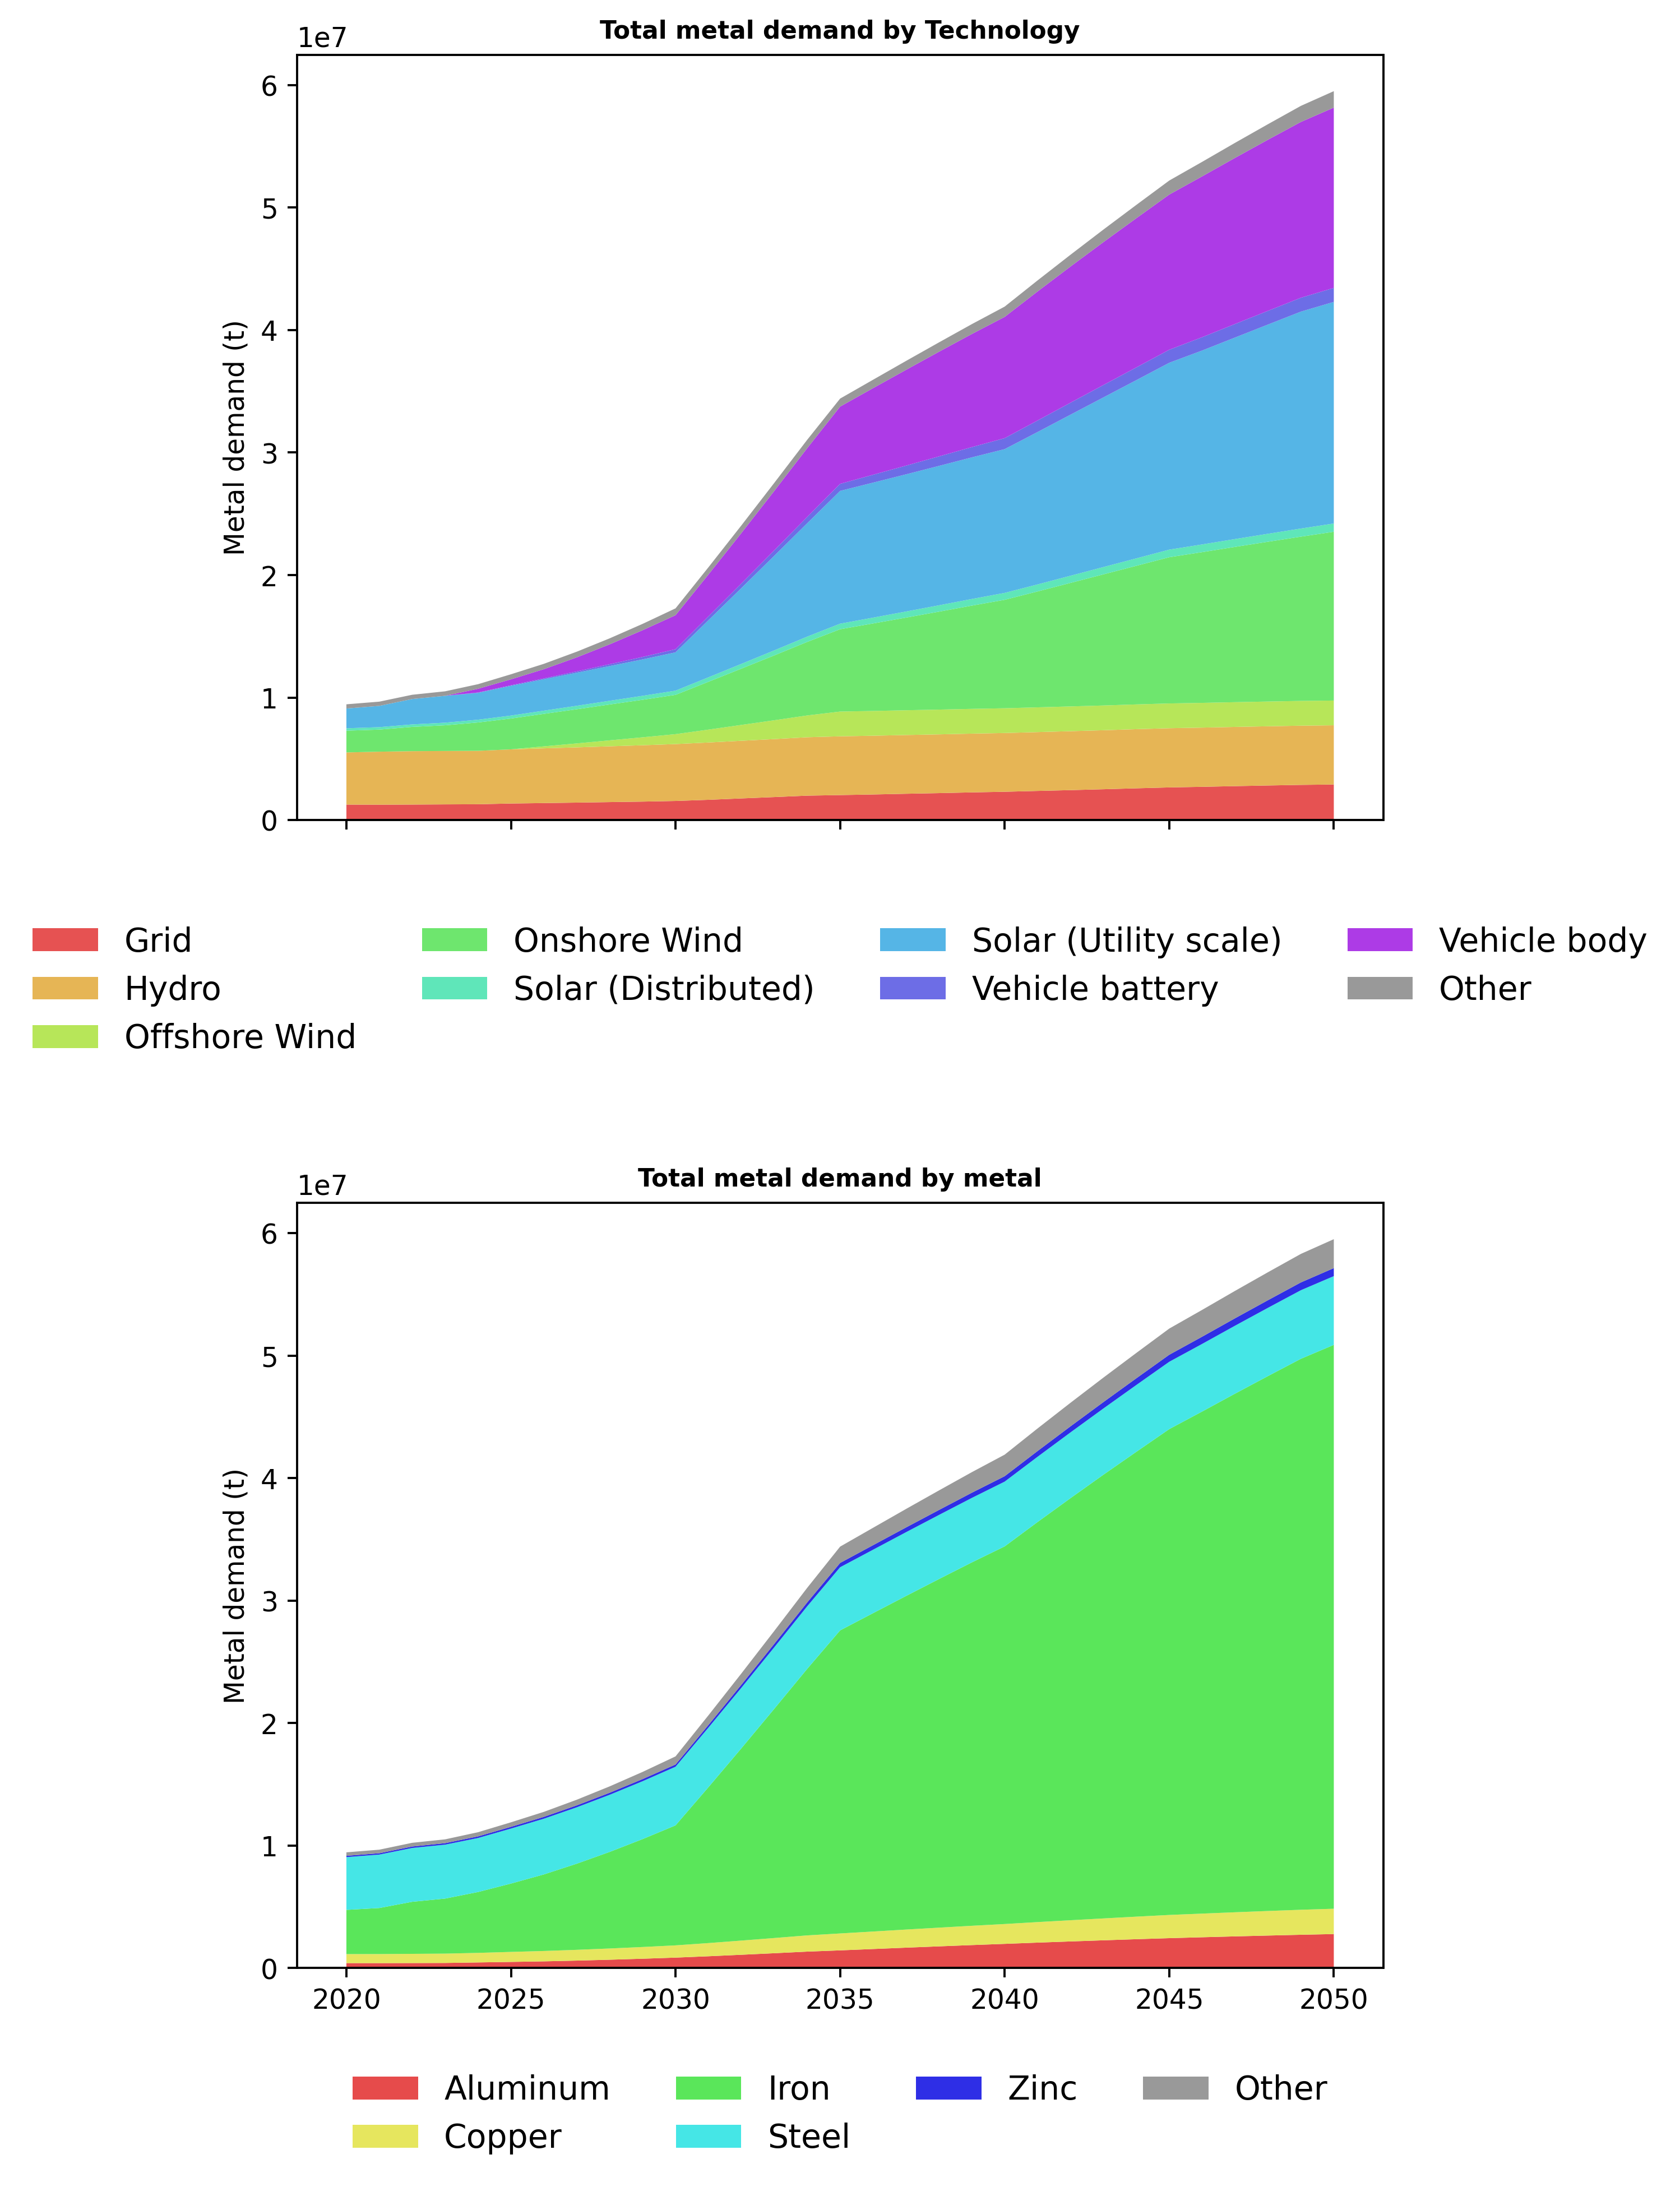

In [94]:
plot_metal_demand_stackplots(metal_demand_nz, variable_col="Technology", savepath="results/NRJ+EVs/metal_demand_stackplot_nz")

✅ Figure saved to results/NRJ+EVs/metal_demand_stackplot_nz_without_iron.png and .svg


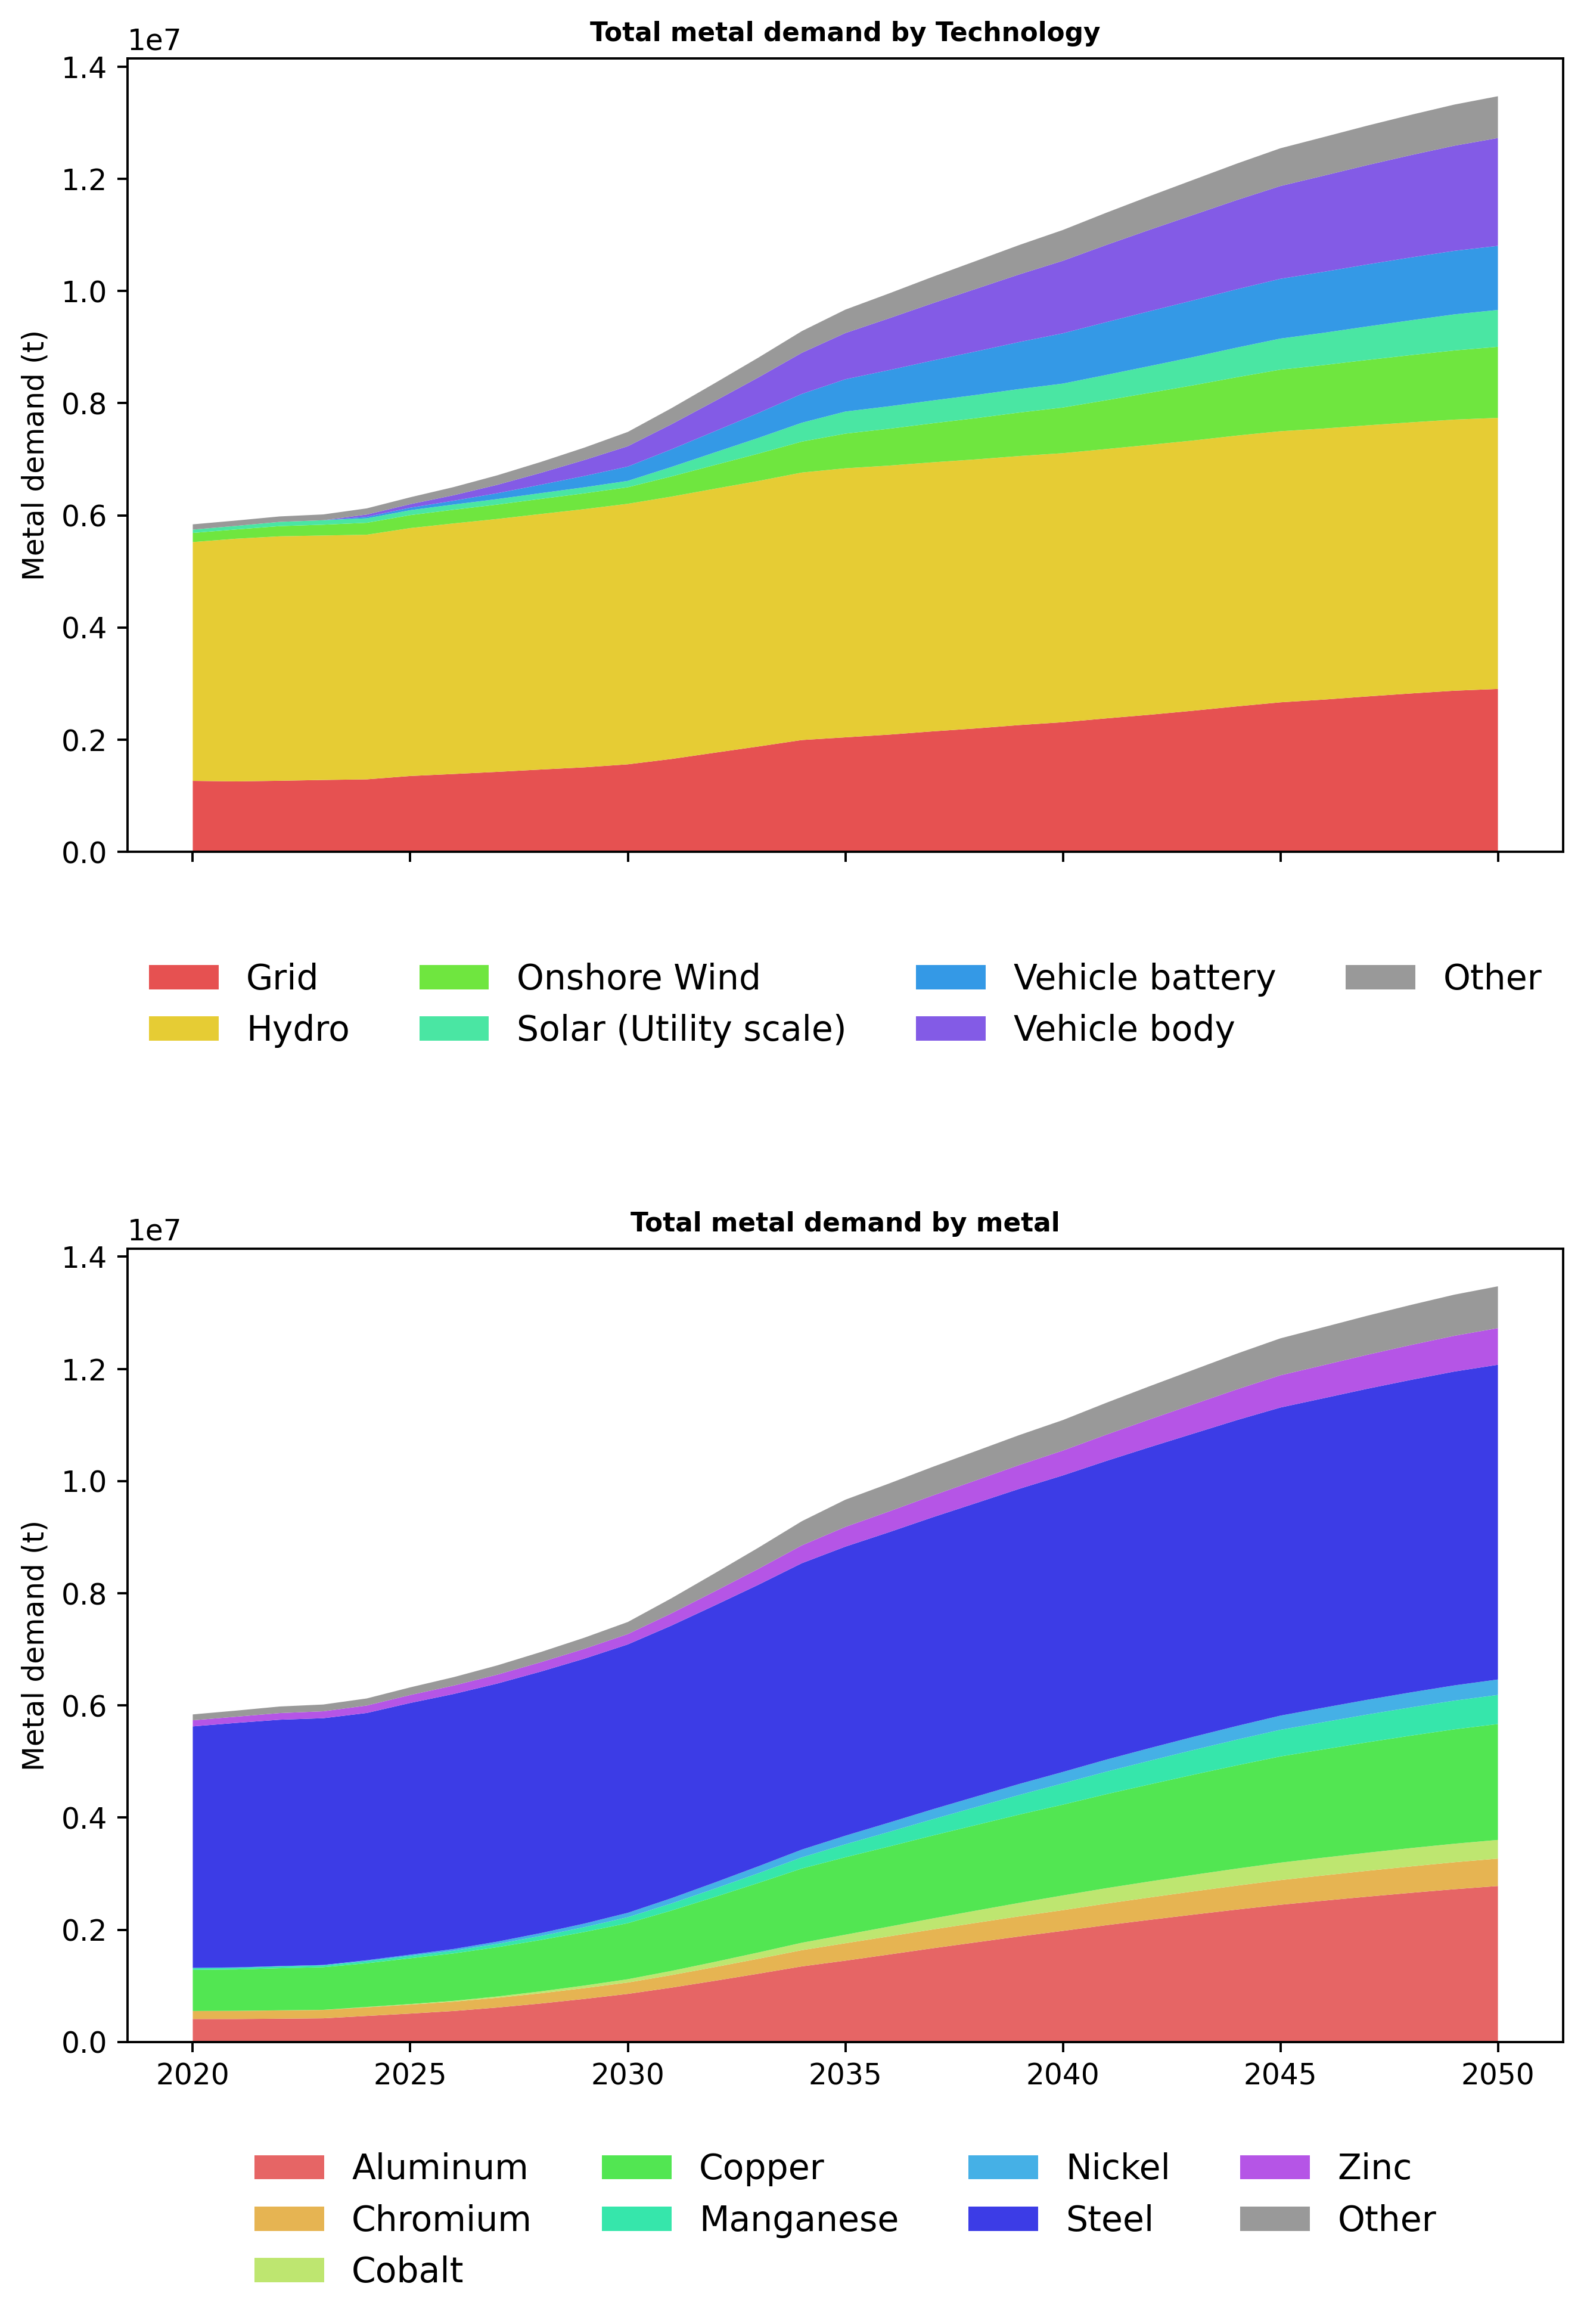

In [95]:
plot_metal_demand_stackplots(metal_demand_nz_without_iron, variable_col="Technology", savepath="results/NRJ+EVs/metal_demand_stackplot_nz_without_iron")

✅ Saved to results/NRJ+EVs/metal_demand_facets_step.png / .svg


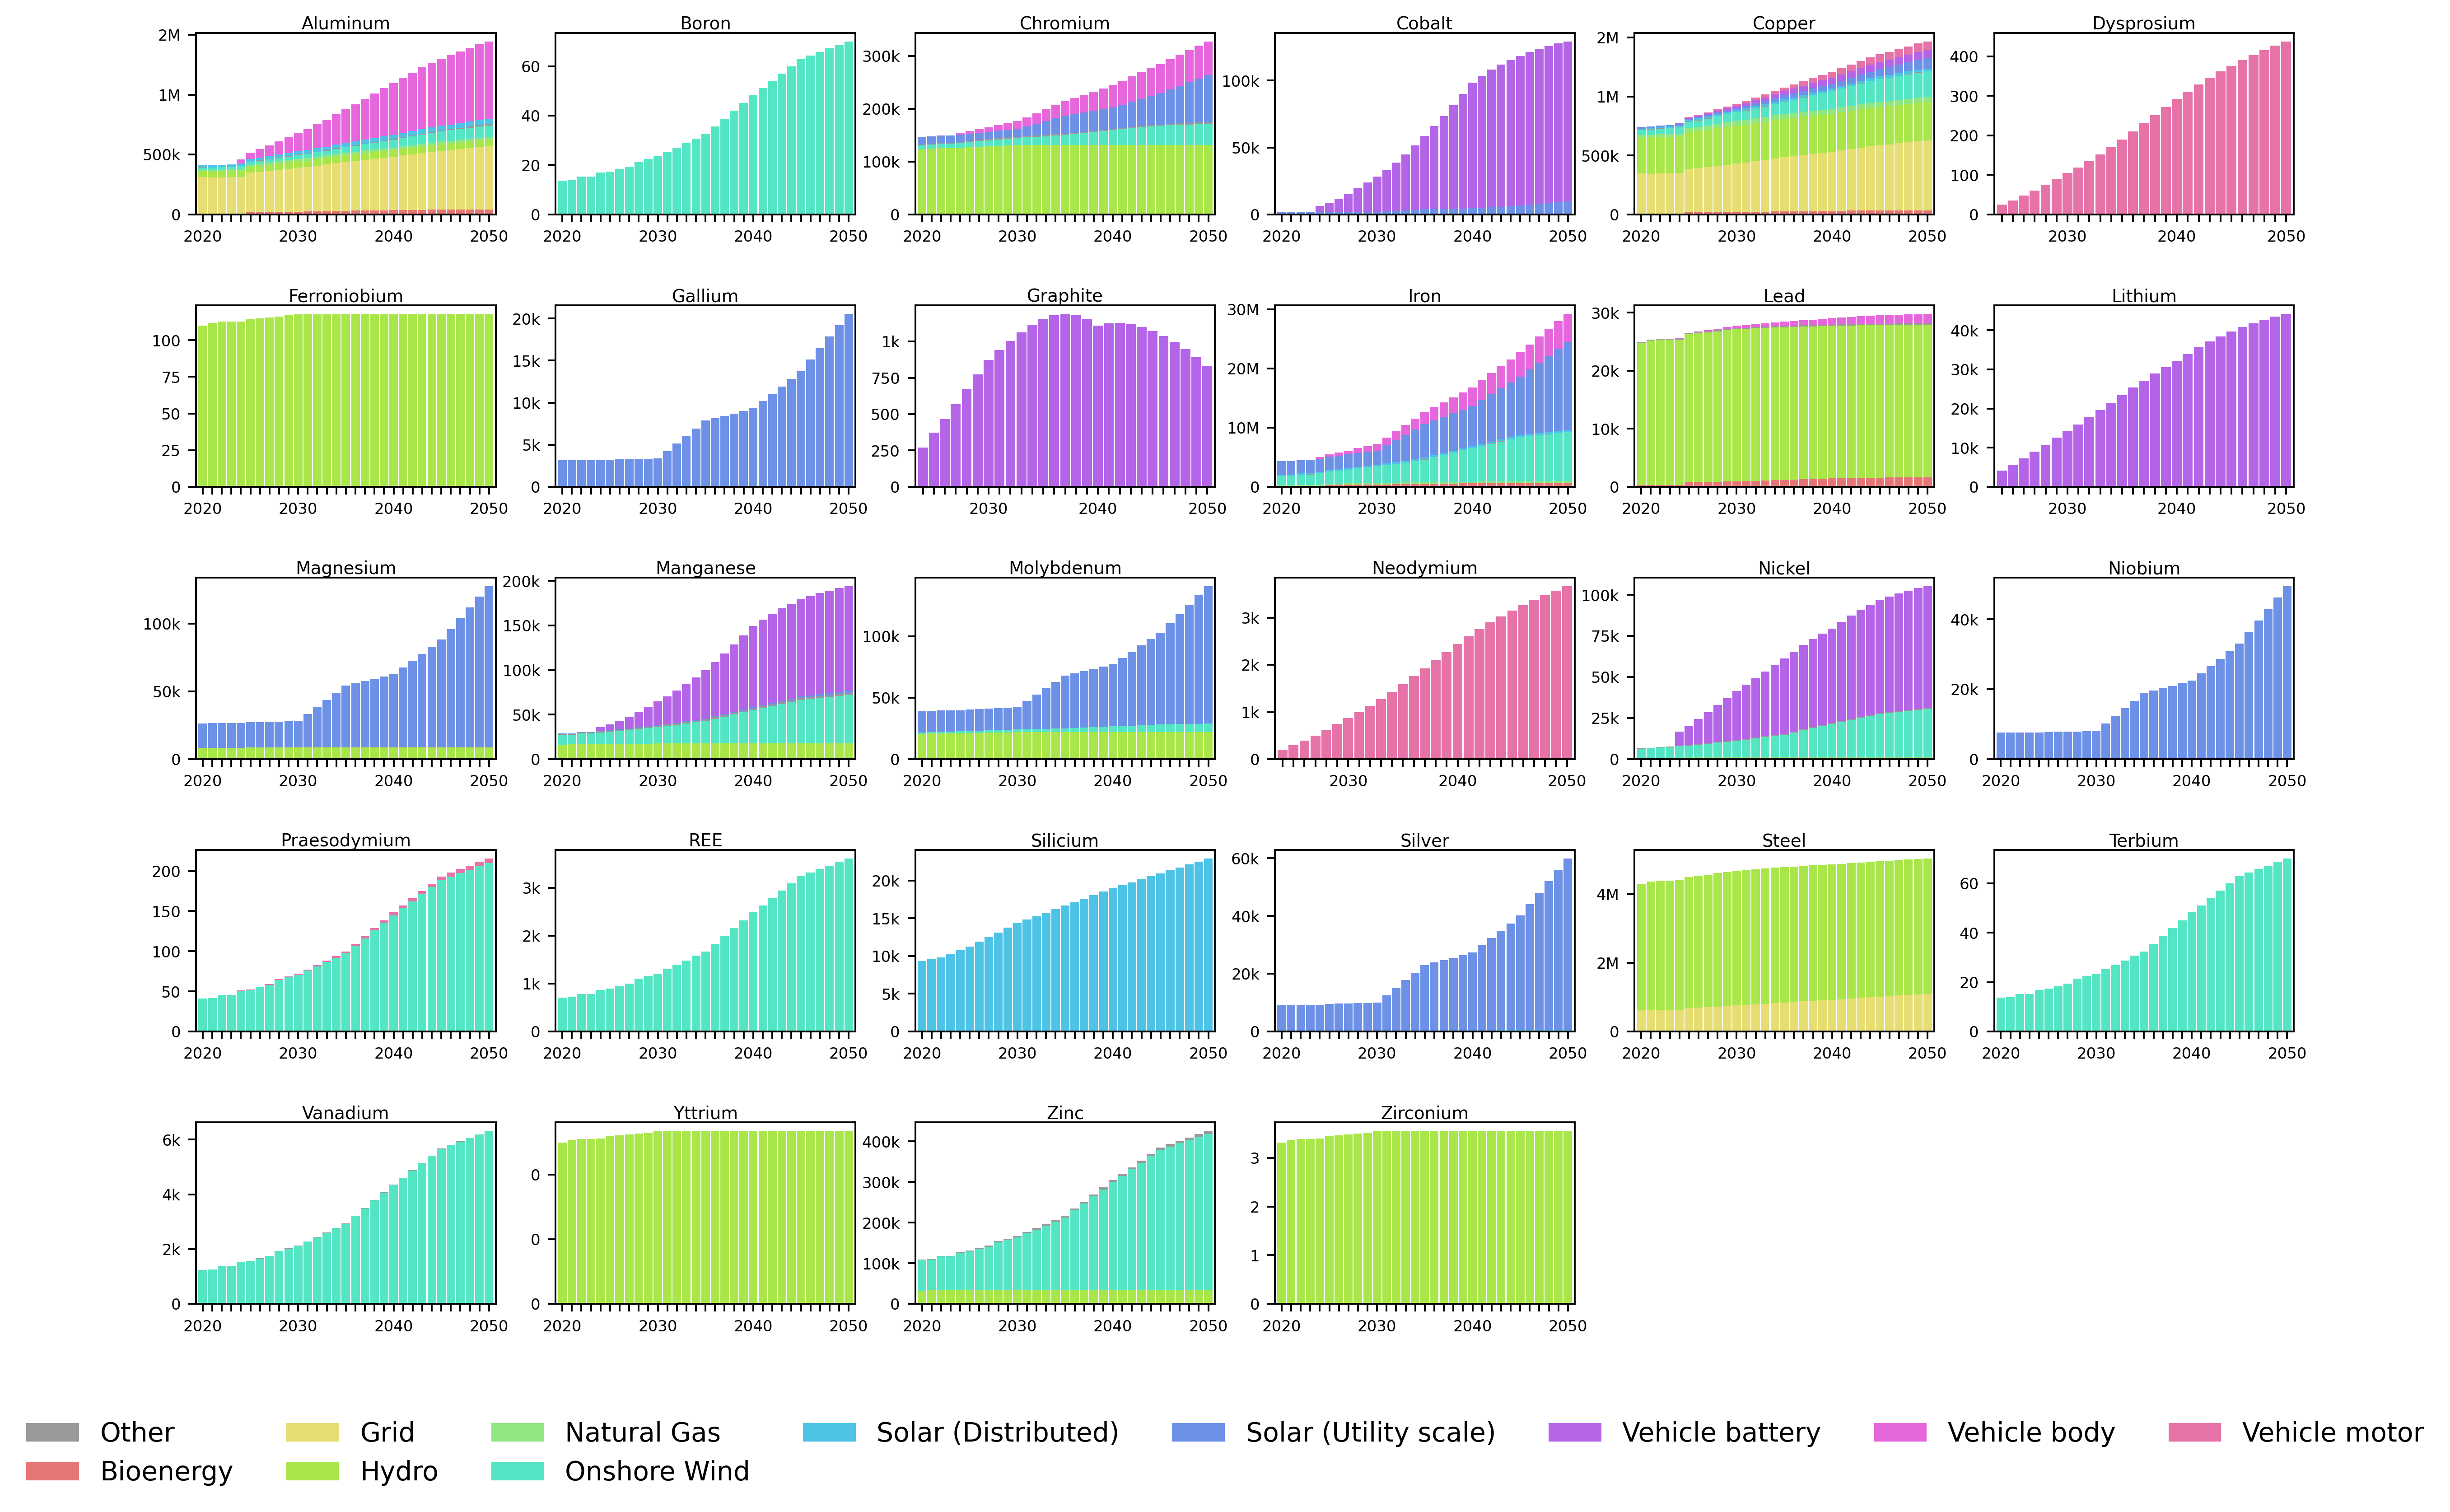

In [96]:
plot_metal_demand_facets(metal_demand_step, variable_col='Technology', savepath="results/NRJ+EVs/metal_demand_facets_step")

In [97]:
color_map = {
    'Copper': '#8c510a',
    'Nickel': '#d8b365',
    'Graphite': '#f6e8c3',
    'Cobalt': '#c7eae5',
    'Lithium': '#5ab4ac',
    'Neodymium': '#01665e'
}

✅ Figure saved to results/NRJ+EVs/metal_demand_stackplot_nz_selectedmetals.png and .svg


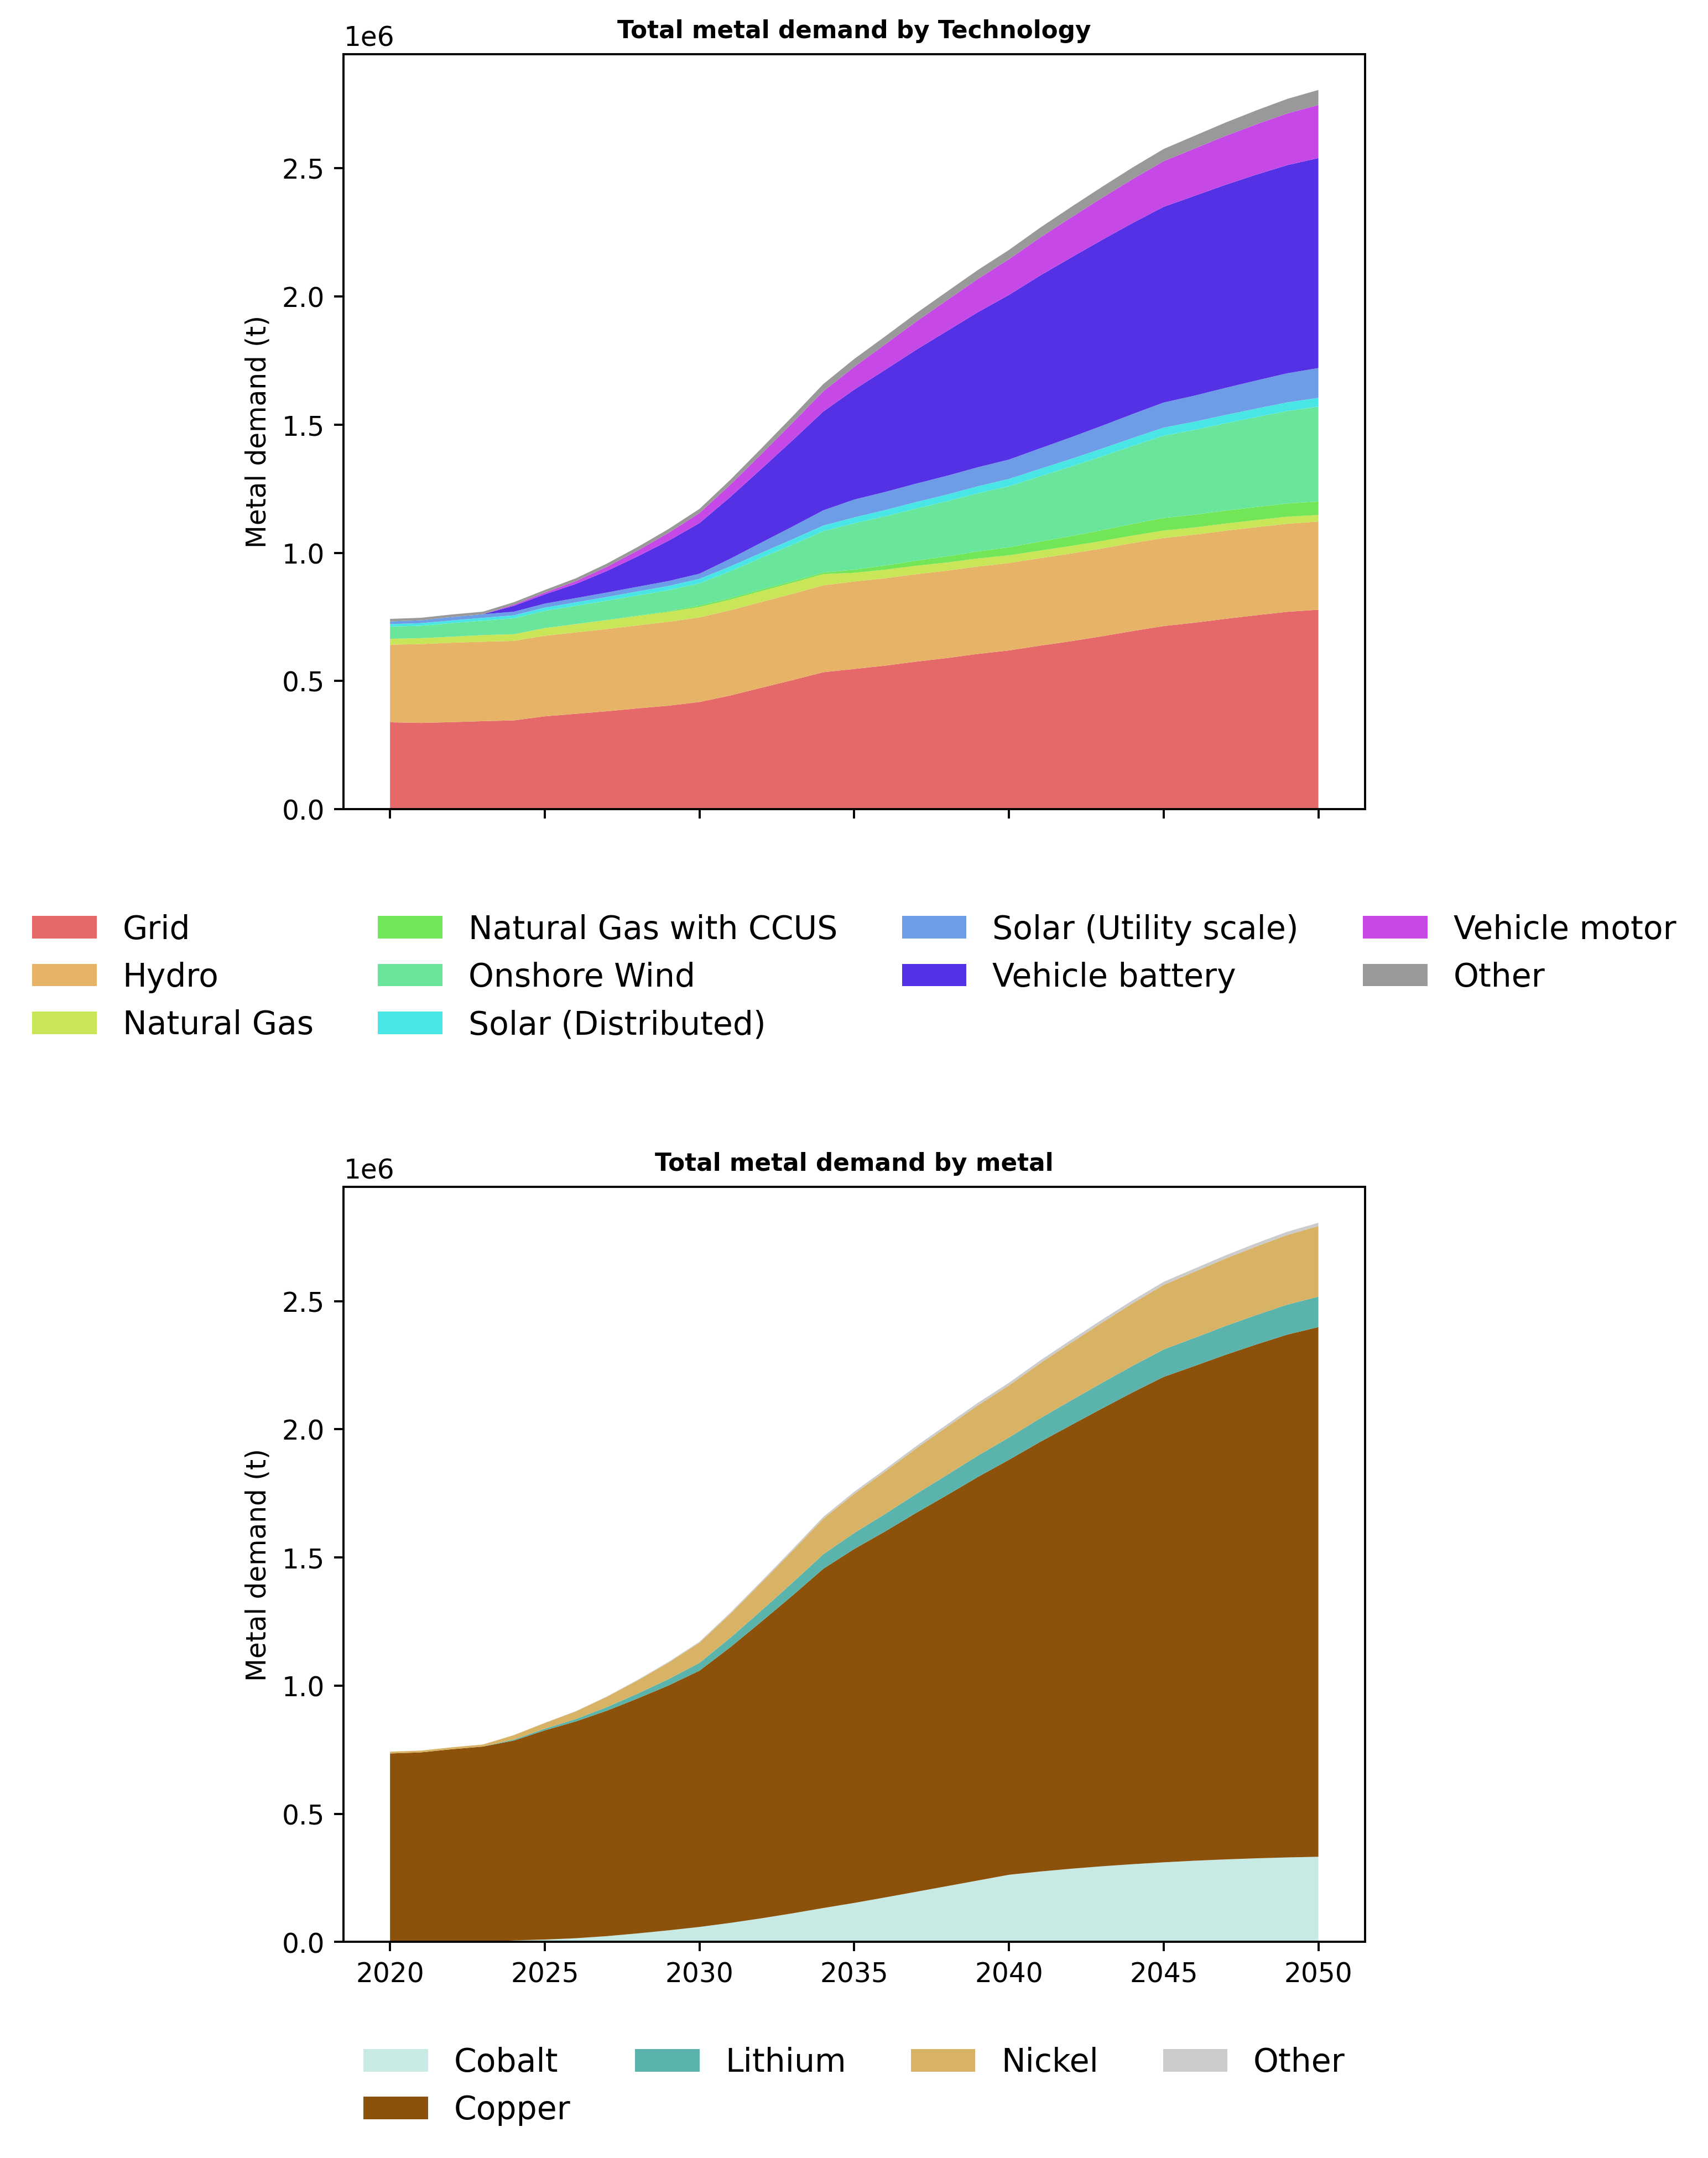

In [98]:
plot_metal_demand_stackplots(metal_demand_selected_nz, variable_col="Technology", metal_colors=color_map,
                             savepath="results/NRJ+EVs/metal_demand_stackplot_nz_selectedmetals")

In [99]:
#plot_metal_demand_facets(metal_demand_selected, variable_col='Technology',
#                         savepath="results/NRJ+EVs/metal_demand_facets_nz_selectedmetals")

✅ Figure saved to results/NRJ+EVs/metal_demand_ev_stackplot_by_mode_step.png and .svg


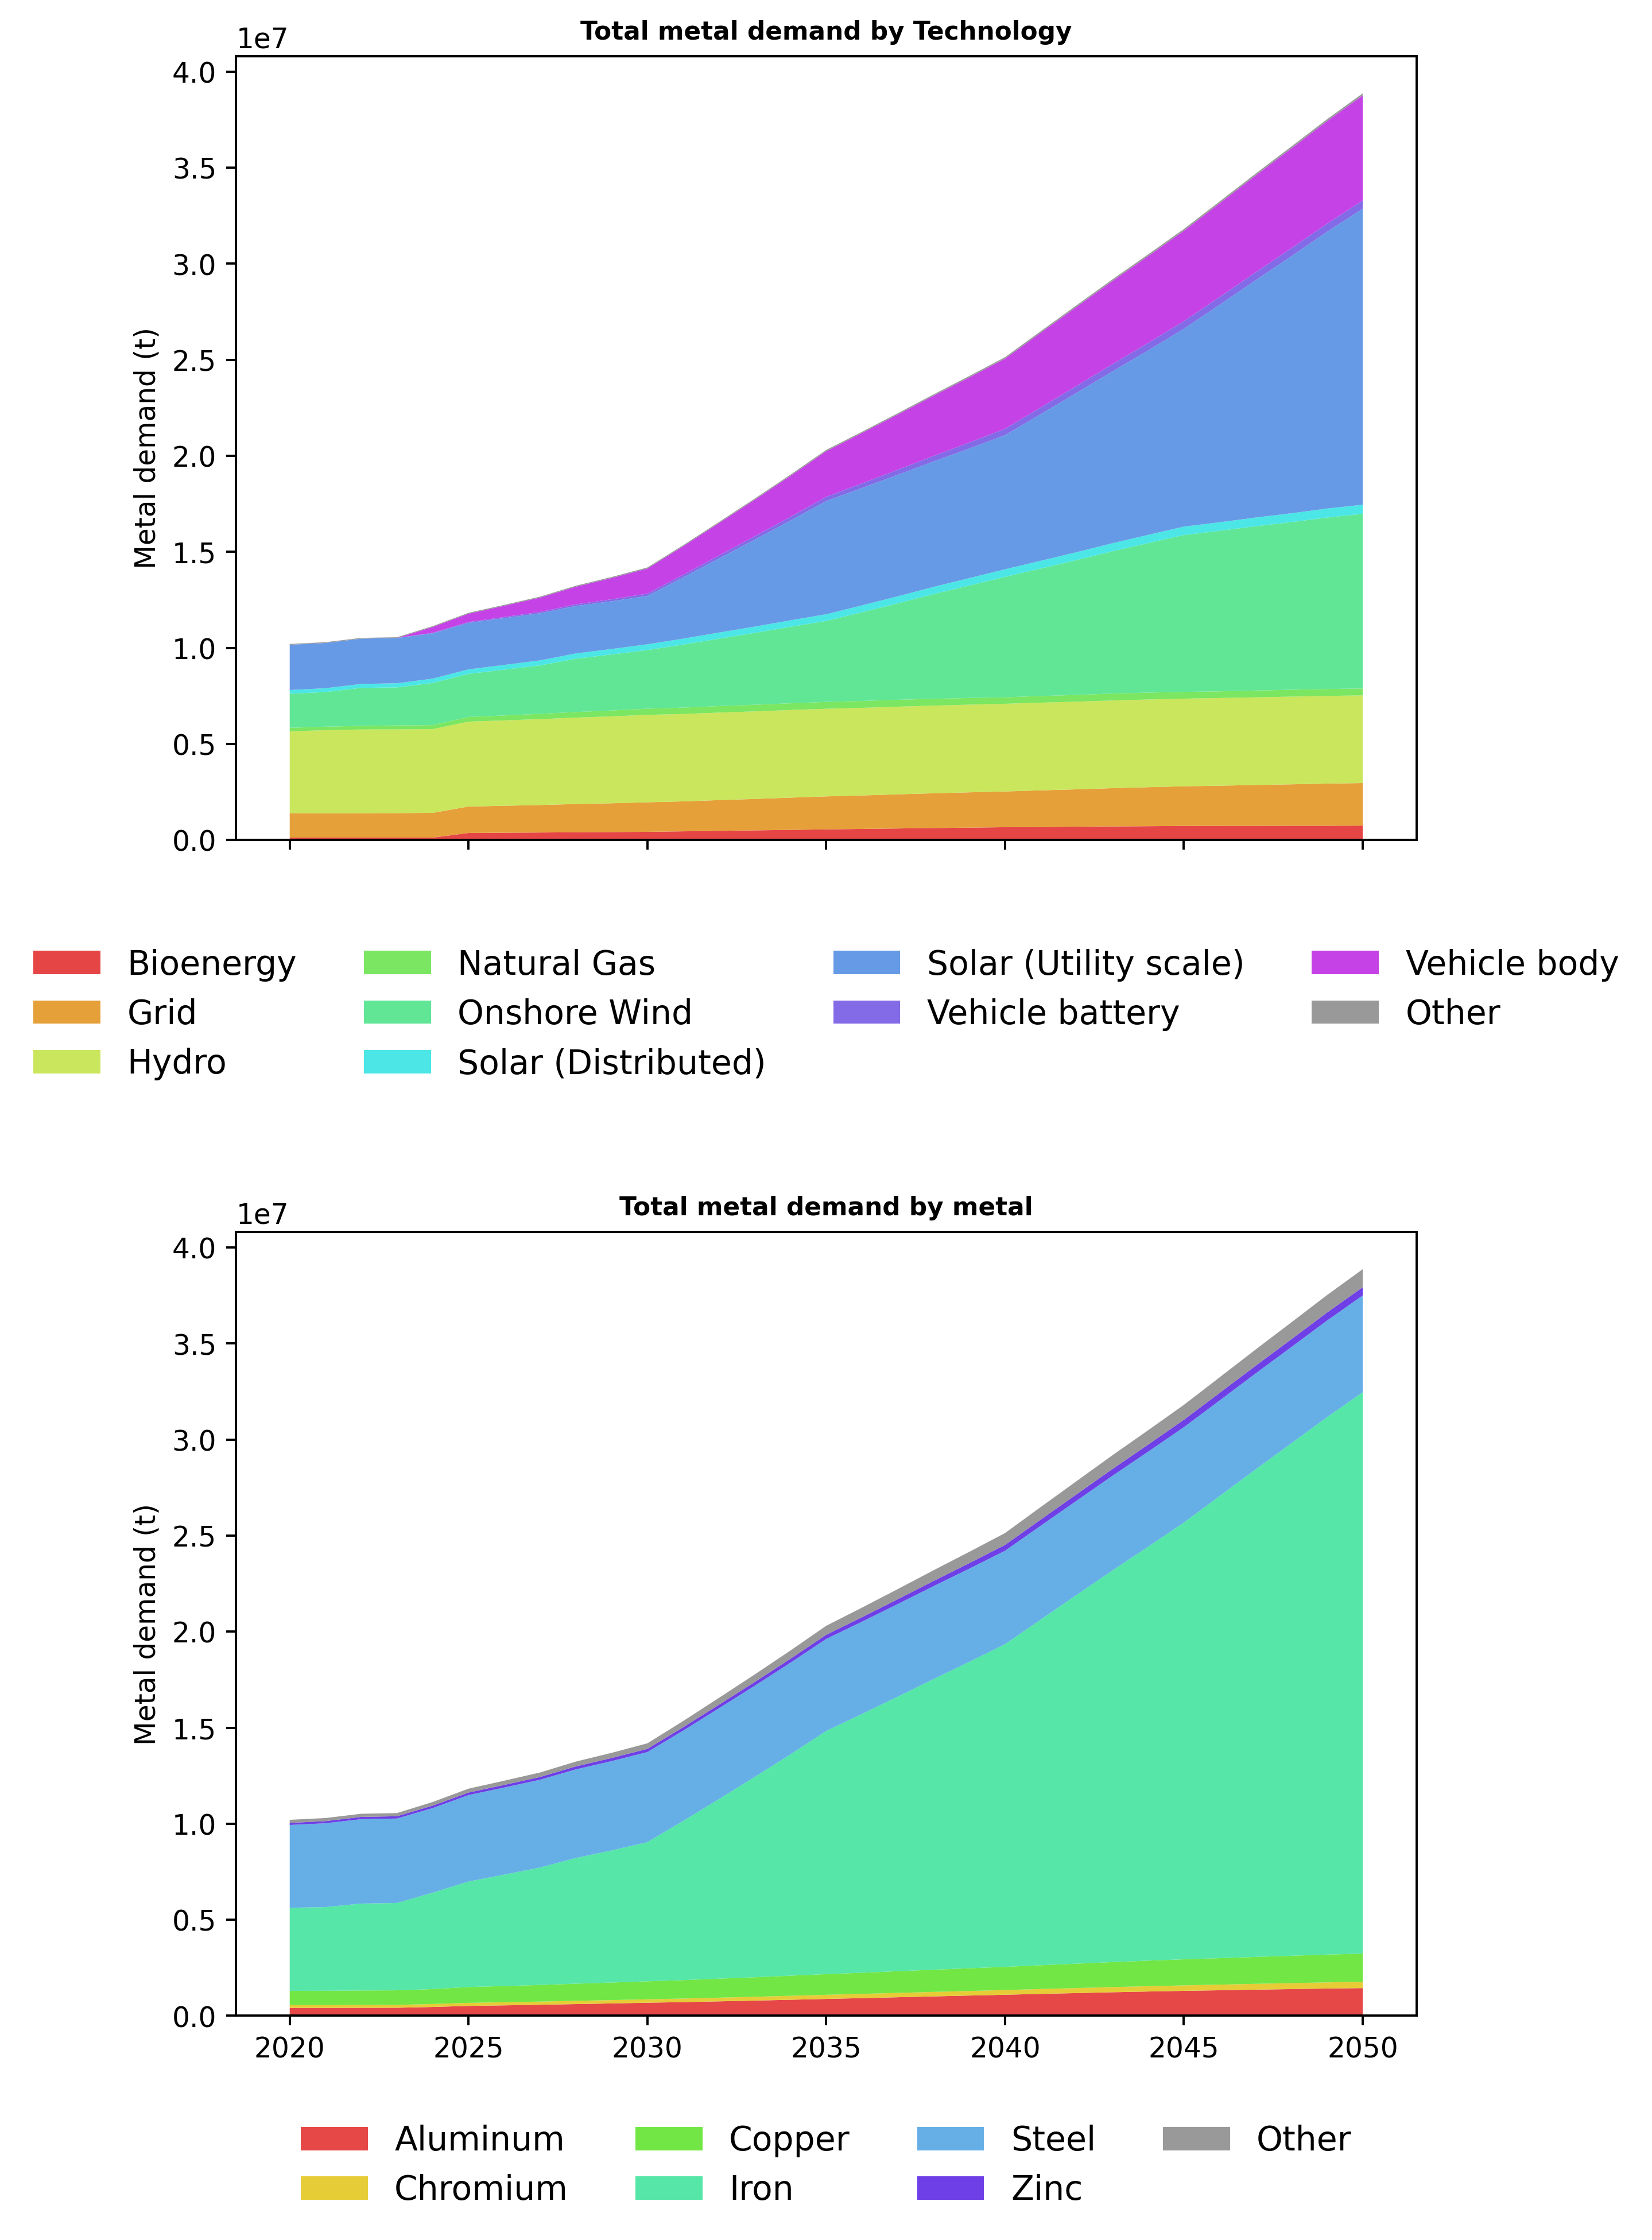

In [100]:
plot_metal_demand_stackplots(metal_demand_step, variable_col="Technology", savepath="results/NRJ+EVs/metal_demand_ev_stackplot_by_mode_step")

In [101]:
# import pandas as pd
# import plotly.graph_objects as go
#
# def plot_sankey_cumulative_tech_metal(
#     df,
#     value_col="Metal_demand_t",
#     scenario=None,
#     country=None,
#     year_min=None,
#     year_max=None,
#     top_n_metals=None,
#     top_n_techs=None,
#     output_html="sankey_cumulative_tech_metal.html",
# ):
#     """
#     Sankey with 2 phases: Technology -> Metal
#     Link values = cumulative demand across selected years (sum of value_col).
#     """
#     d = df.copy()
#
#     # infer defaults
#     if scenario is None and "Scenario" in d.columns:
#         scen = d["Scenario"].dropna().unique()
#         scenario = scen[0] if len(scen) else None
#     if country is None and "Country" in d.columns:
#         ctry = d["Country"].dropna().unique()
#         country = ctry[0] if len(ctry) else None
#
#     if scenario is not None and "Scenario" in d.columns:
#         d = d[d["Scenario"] == scenario]
#     if country is not None and "Country" in d.columns:
#         d = d[d["Country"] == country]
#     if year_min is not None:
#         d = d[d["Year"] >= year_min]
#     if year_max is not None:
#         d = d[d["Year"] <= year_max]
#
#     agg = (
#         d.groupby(["Technology", "Metal"], dropna=False)[value_col]
#         .sum()
#         .reset_index()
#     )
#
#     if top_n_metals is not None:
#         top_metals = (
#             agg.groupby("Metal")[value_col].sum().sort_values(ascending=False).head(top_n_metals).index
#         )
#         agg = agg[agg["Metal"].isin(top_metals)]
#     if top_n_techs is not None:
#         top_techs = (
#             agg.groupby("Technology")[value_col].sum().sort_values(ascending=False).head(top_n_techs).index
#         )
#         agg = agg[agg["Technology"].isin(top_techs)]
#
#     agg["Technology"] = agg["Technology"].fillna("Unknown technology")
#     agg["Metal"] = agg["Metal"].fillna("Unknown metal")
#
#     techs = sorted(agg["Technology"].unique().tolist())
#     metals = sorted(agg["Metal"].unique().tolist())
#
#     nodes = techs + metals
#     node_index = {n: i for i, n in enumerate(nodes)}
#
#     fig = go.Figure(
#         data=[
#             go.Sankey(
#                 arrangement="snap",
#                 node=dict(pad=15, thickness=18, label=nodes),
#                 link=dict(
#                     source=agg["Technology"].map(node_index).astype(int).tolist(),
#                     target=agg["Metal"].map(node_index).astype(int).tolist(),
#                     value=agg[value_col].astype(float).tolist(),
#                 ),
#             )
#         ]
#     )
#
#     subtitle = " | ".join([x for x in [
#         f"Scenario: {scenario}" if scenario else None,
#         f"Country: {country}" if country else None,
#         f"Years: {(year_min if year_min is not None else int(d['Year'].min()))}–{(year_max if year_max is not None else int(d['Year'].max()))}"
#             if (year_min is not None or year_max is not None) else None
#     ] if x])
#
#     fig.update_layout(
#         title=f"Cumulative metal demand (t) by technology → metal<br><sup>{subtitle}</sup>",
#         font_size=12,
#         height=700,
#         margin=dict(l=10, r=10, t=80, b=10),
#     )
#
#     fig.write_html(output_html, include_plotlyjs="cdn")
#     return fig, agg

In [108]:
import pandas as pd
import plotly.graph_objects as go


def plot_sankey_cumulative_tech_metal(
    df,
    value_col="Metal_demand_t",
    scenario=None,
    country=None,
    year_min=None,
    year_max=None,
    top_n_metals=None,
    top_n_techs=None,
    output_html="sankey_cumulative_tech_metal.html",
    output_pdf=None,                 # optional PDF path (requires kaleido)
    pdf_width=1600,
    pdf_height=900,
    # style
    template="plotly_white",
    tech_node_color="rgba(200,200,200,0.95)",
    link_alpha=0.45,                 # transparency of colored links
    metal_color_map=None,            # dict: {"Copper":"rgba(...)", ...} optional
):
    """
    Sankey with 2 phases: Technology -> Metal
    Link values = cumulative demand across selected years (sum of value_col).

    - Light theme (white background, black text)
    - Technologies nodes: grey
    - Metal nodes: colored
    - Links: colored by Metal

    PDF export requires:
        pip install -U kaleido
    """

    d = df.copy()

    # infer defaults
    if scenario is None and "Scenario" in d.columns:
        scen = d["Scenario"].dropna().unique()
        scenario = scen[0] if len(scen) else None
    if country is None and "Country" in d.columns:
        ctry = d["Country"].dropna().unique()
        country = ctry[0] if len(ctry) else None

    # filters
    if scenario is not None and "Scenario" in d.columns:
        d = d[d["Scenario"] == scenario]
    if country is not None and "Country" in d.columns:
        d = d[d["Country"] == country]
    if year_min is not None:
        d = d[d["Year"] >= year_min]
    if year_max is not None:
        d = d[d["Year"] <= year_max]

    if d.empty:
        raise ValueError("No data left after filtering (scenario/country/year).")

    agg = (
        d.groupby(["Technology", "Metal"], dropna=False)[value_col]
        .sum()
        .reset_index()
    )

    if top_n_metals is not None:
        top_metals = (
            agg.groupby("Metal")[value_col].sum()
            .sort_values(ascending=False)
            .head(top_n_metals)
            .index
        )
        agg = agg[agg["Metal"].isin(top_metals)]

    if top_n_techs is not None:
        top_techs = (
            agg.groupby("Technology")[value_col].sum()
            .sort_values(ascending=False)
            .head(top_n_techs)
            .index
        )
        agg = agg[agg["Technology"].isin(top_techs)]

    agg["Technology"] = agg["Technology"].fillna("Unknown technology")
    agg["Metal"] = agg["Metal"].fillna("Unknown metal")

    techs = sorted(agg["Technology"].unique().tolist())
    metals = sorted(agg["Metal"].unique().tolist())

    nodes = techs + metals
    node_index = {n: i for i, n in enumerate(nodes)}

    # --- Colors ---
    # Default palette (Plotly-like qualitative), as rgba strings
    default_palette = [
        "rgba(31,119,180,1)",  # blue
        "rgba(255,127,14,1)",  # orange
        "rgba(44,160,44,1)",   # green
        "rgba(214,39,40,1)",   # red
        "rgba(148,103,189,1)", # purple
        "rgba(140,86,75,1)",   # brown
        "rgba(227,119,194,1)", # pink
        "rgba(127,127,127,1)", # gray
        "rgba(188,189,34,1)",  # olive
        "rgba(23,190,207,1)",  # cyan
    ]

    # Build metal -> color
    if metal_color_map is None:
        metal_color_map = {}
    metal_colors = {}
    for i, m in enumerate(metals):
        metal_colors[m] = metal_color_map.get(m, default_palette[i % len(default_palette)])

    # Node colors: tech grey, metals colored
    node_colors = [tech_node_color] * len(techs) + [metal_colors[m] for m in metals]

    # Link colors: color by Metal
    def with_alpha(rgba_str, alpha):
        # expects "rgba(r,g,b,a)" or "rgba(r,g,b,1)"
        if rgba_str.startswith("rgba(") and rgba_str.endswith(")"):
            inner = rgba_str[5:-1]
            parts = inner.split(",")
            if len(parts) >= 3:
                r = parts[0].strip()
                g = parts[1].strip()
                b = parts[2].strip()
                return f"rgba({r},{g},{b},{alpha})"
        return rgba_str  # fallback

    link_colors = [with_alpha(metal_colors[m], link_alpha) for m in agg["Metal"].tolist()]

    # Build sankey
    fig = go.Figure(
        data=[
            go.Sankey(
                arrangement="snap",
                node=dict(
                    pad=15,
                    thickness=18,
                    label=nodes,
                    color=node_colors,
                    line=dict(color="black", width=0.5),
                ),
                link=dict(
                    source=agg["Technology"].map(node_index).astype(int).tolist(),
                    target=agg["Metal"].map(node_index).astype(int).tolist(),
                    value=agg[value_col].astype(float).tolist(),
                    color=link_colors,
                ),
            )
        ]
    )

    # Subtitle
    yr_min = int(d["Year"].min()) if "Year" in d.columns and len(d) else year_min
    yr_max = int(d["Year"].max()) if "Year" in d.columns and len(d) else year_max
    subtitle = " | ".join(
        [x for x in [
            f"Scenario: {scenario}" if scenario else None,
            f"Country: {country}" if country else None,
            f"Years: {(year_min if year_min is not None else yr_min)}–{(year_max if year_max is not None else yr_max)}"
            if (year_min is not None or year_max is not None or (yr_min is not None and yr_max is not None)) else None,
        ] if x]
    )

    fig.update_layout(
        title=f"Cumulative metal demand (t) by technology → metal<br><sup>{subtitle}</sup>",
        template=template,
        paper_bgcolor="white",
        plot_bgcolor="white",
        font=dict(color="black", size=12),
        height=700,
        margin=dict(l=10, r=10, t=80, b=10),
    )

    # Write HTML
    fig.write_html(output_html, include_plotlyjs="cdn")

    # Default PDF name
    if output_pdf is None and output_html and output_html.lower().endswith(".html"):
        output_pdf = output_html[:-5] + ".pdf"

    # Write PDF (vector) via kaleido
    if output_pdf:
        try:
            fig.write_image(
                output_pdf,
                format="pdf",
                width=pdf_width,
                height=pdf_height,
                scale=1,
            )
        except Exception as e:
            raise RuntimeError(
                "PDF export failed. Install kaleido with: pip install -U kaleido\n"
                f"Original error: {e}"
            )

    return fig, agg



In [110]:
selected_metal_colors = {
    'Copper': '#8c510a',
    'Nickel': '#d8b365',
    'Graphite': '#f6e8c3',
    'Cobalt': '#c7eae5',
    'Lithium': '#5ab4ac',
    'Neodymium': '#01665e'
}

In [111]:
# Example
fig, agg = plot_sankey_cumulative_tech_metal(
    metal_demand_selected_nz,
    scenario="Canada Net-zero",
    country="Canada",
    year_min=2021,
    year_max=2050,
    top_n_metals=20,
    output_html = r'results/NRJ+EVS/cumulative_metal_demand.html',
    output_pdf= r'results/NRJ+EVS/cumulative_metal_demand.pdf',
    metal_color_map=selected_metal_colors
)

# Scenario difference

C:\Users\mp_ma\OneDrive - polymtl\POST_DOC\CODE\fasc_metal_sustainability\utils\visualisations.py:308: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




✅ Saved to results/Scenario_diff/Scenario_diff_metal.png / .svg


Scenario,% difference
Metal,
Aluminum,-39.152384
Boron,-49.793573
Chromium,-26.783549
Cobalt,-60.754063
Copper,-19.953051
Dysprosium,-65.096400
Ferroniobium,-3.428108
Gallium,-29.953465
Graphite,-60.041306


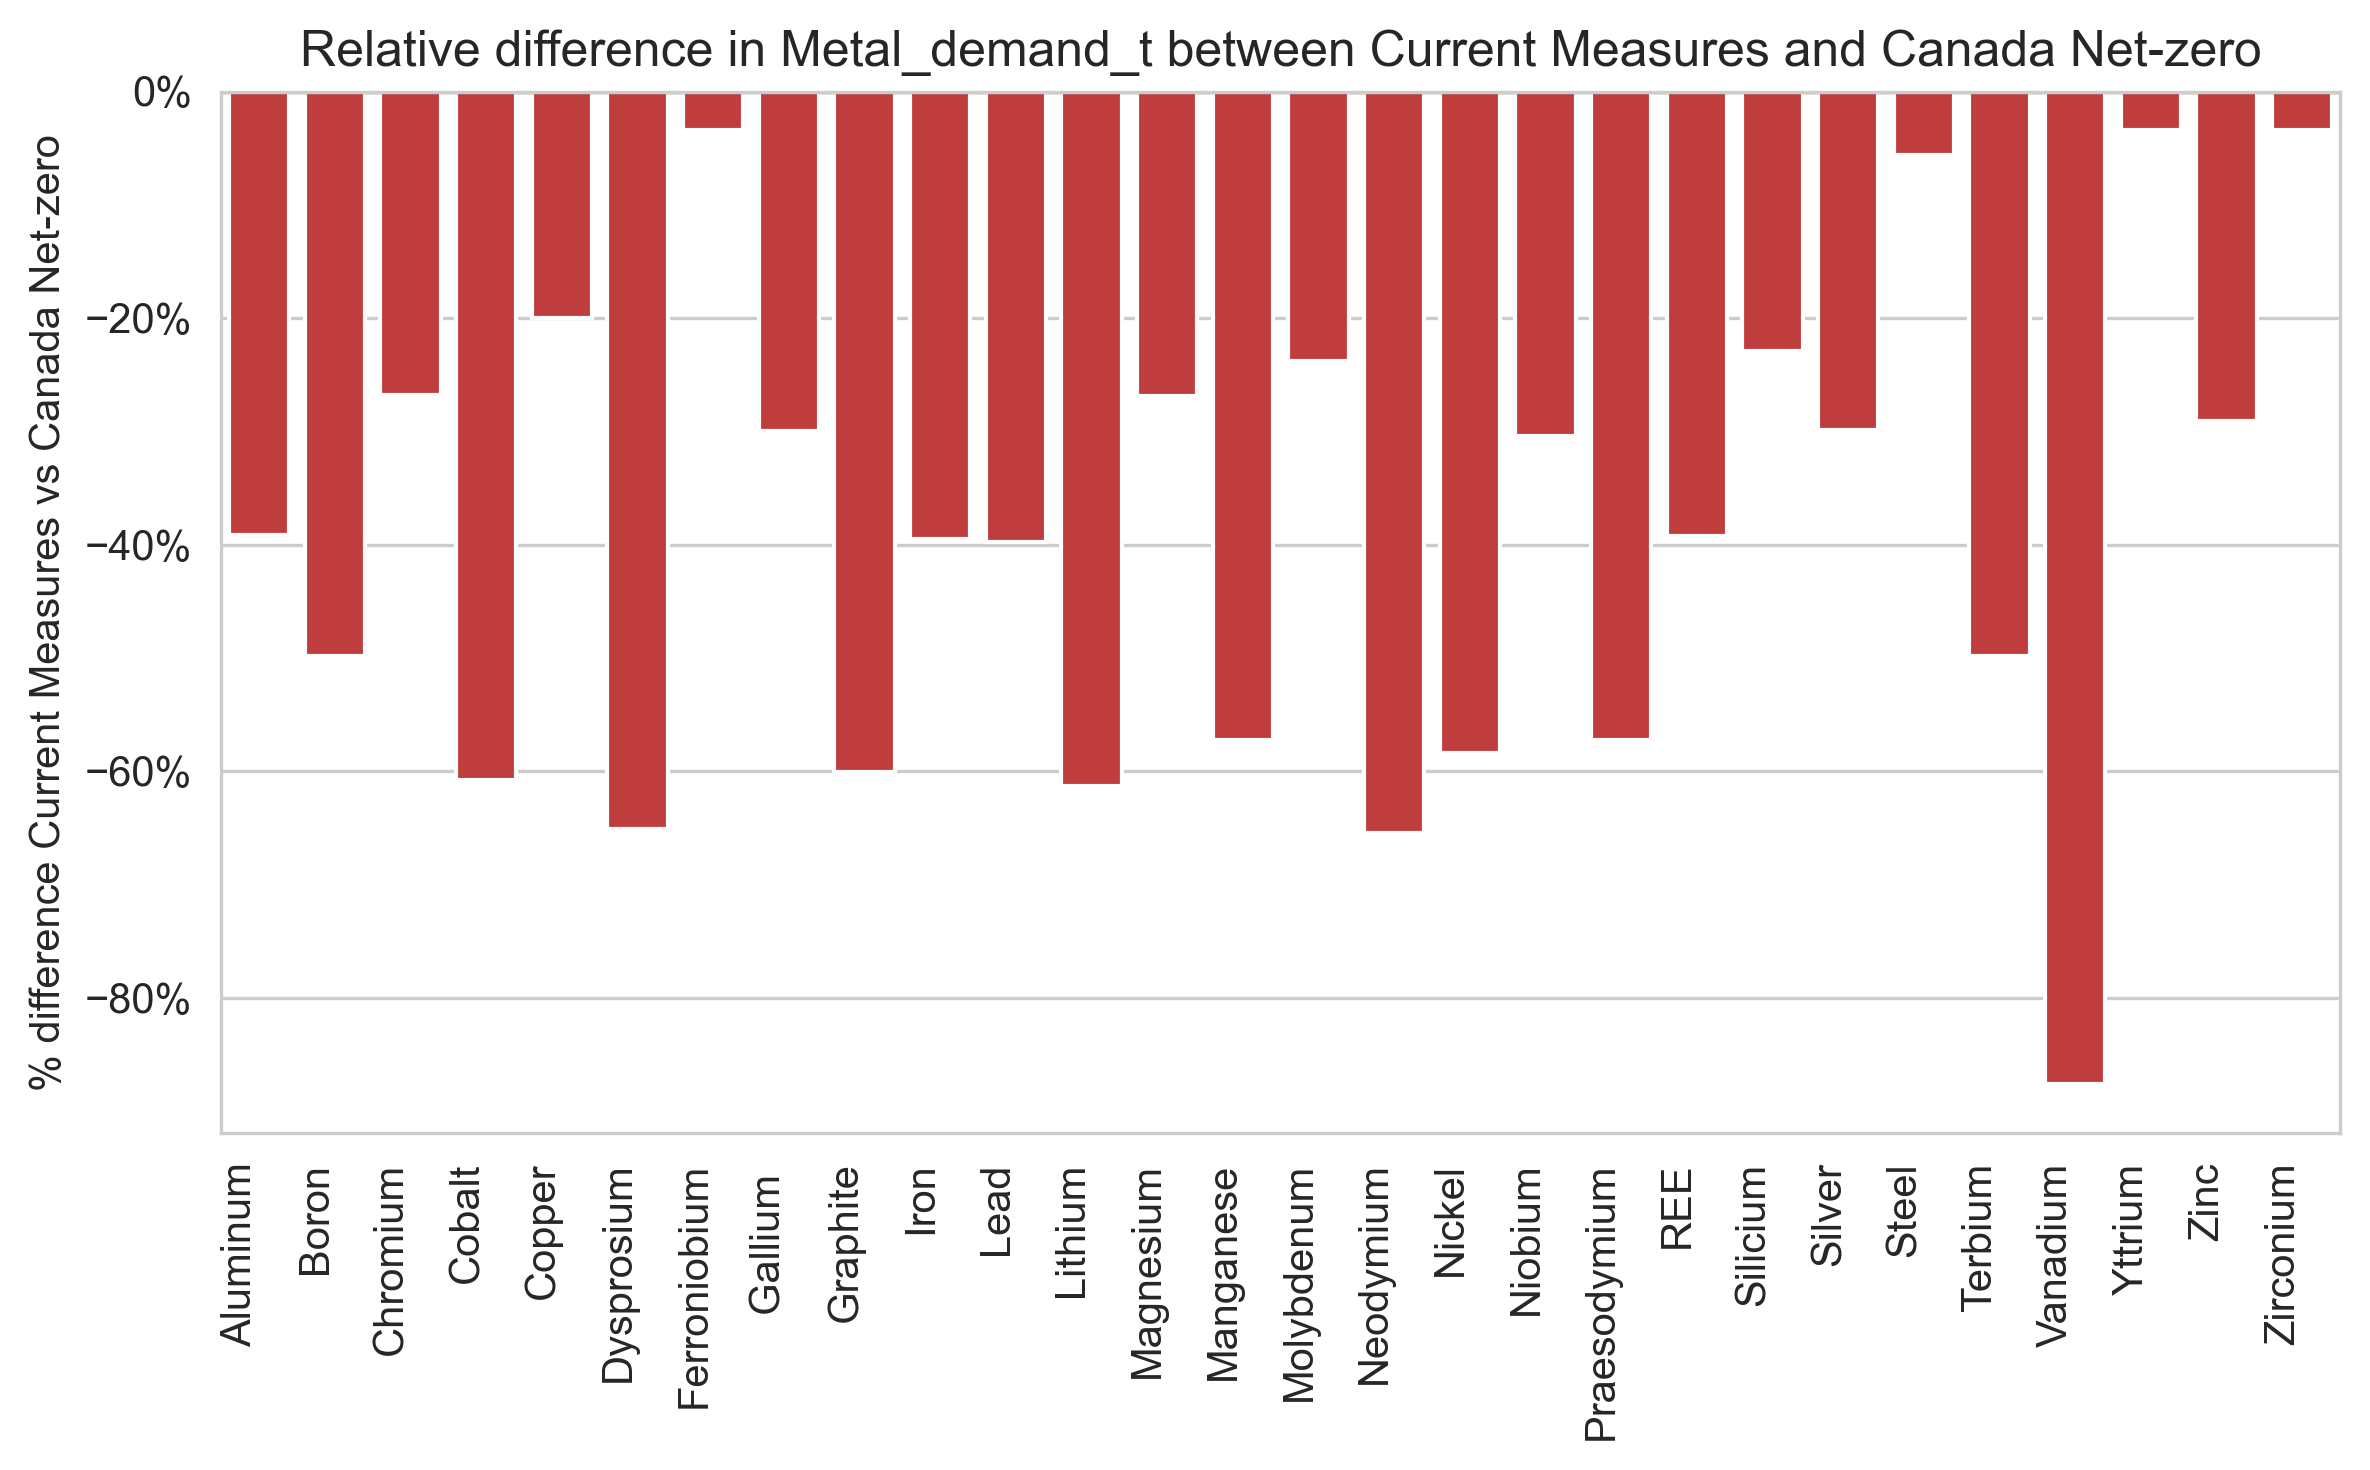

In [104]:
plot_scenario_difference(
    df=metal_demand,
    scenario_col="Scenario",
    value_col="Metal_demand_t",
    variable_col="Metal",
    scenario_a="Current Measures",
    scenario_b="Canada Net-zero",
    savepath="results/Scenario_diff/Scenario_diff_metal"
)

C:\Users\mp_ma\OneDrive - polymtl\POST_DOC\CODE\fasc_metal_sustainability\utils\visualisations.py:308: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




✅ Saved to results/Scenario_diff/Scenario_diff_technology.png / .svg


Scenario,% difference
Technology,
Bioenergy,215.917739
Bioenergy with CCUS,NaN
Coal and Coke,NaN
Coal with CCUS,106.666667
Grid,-14.580247
Hydro,-3.428108
Hydrogen,NaN
Natural Gas,23.729606
Natural Gas with CCUS,NaN


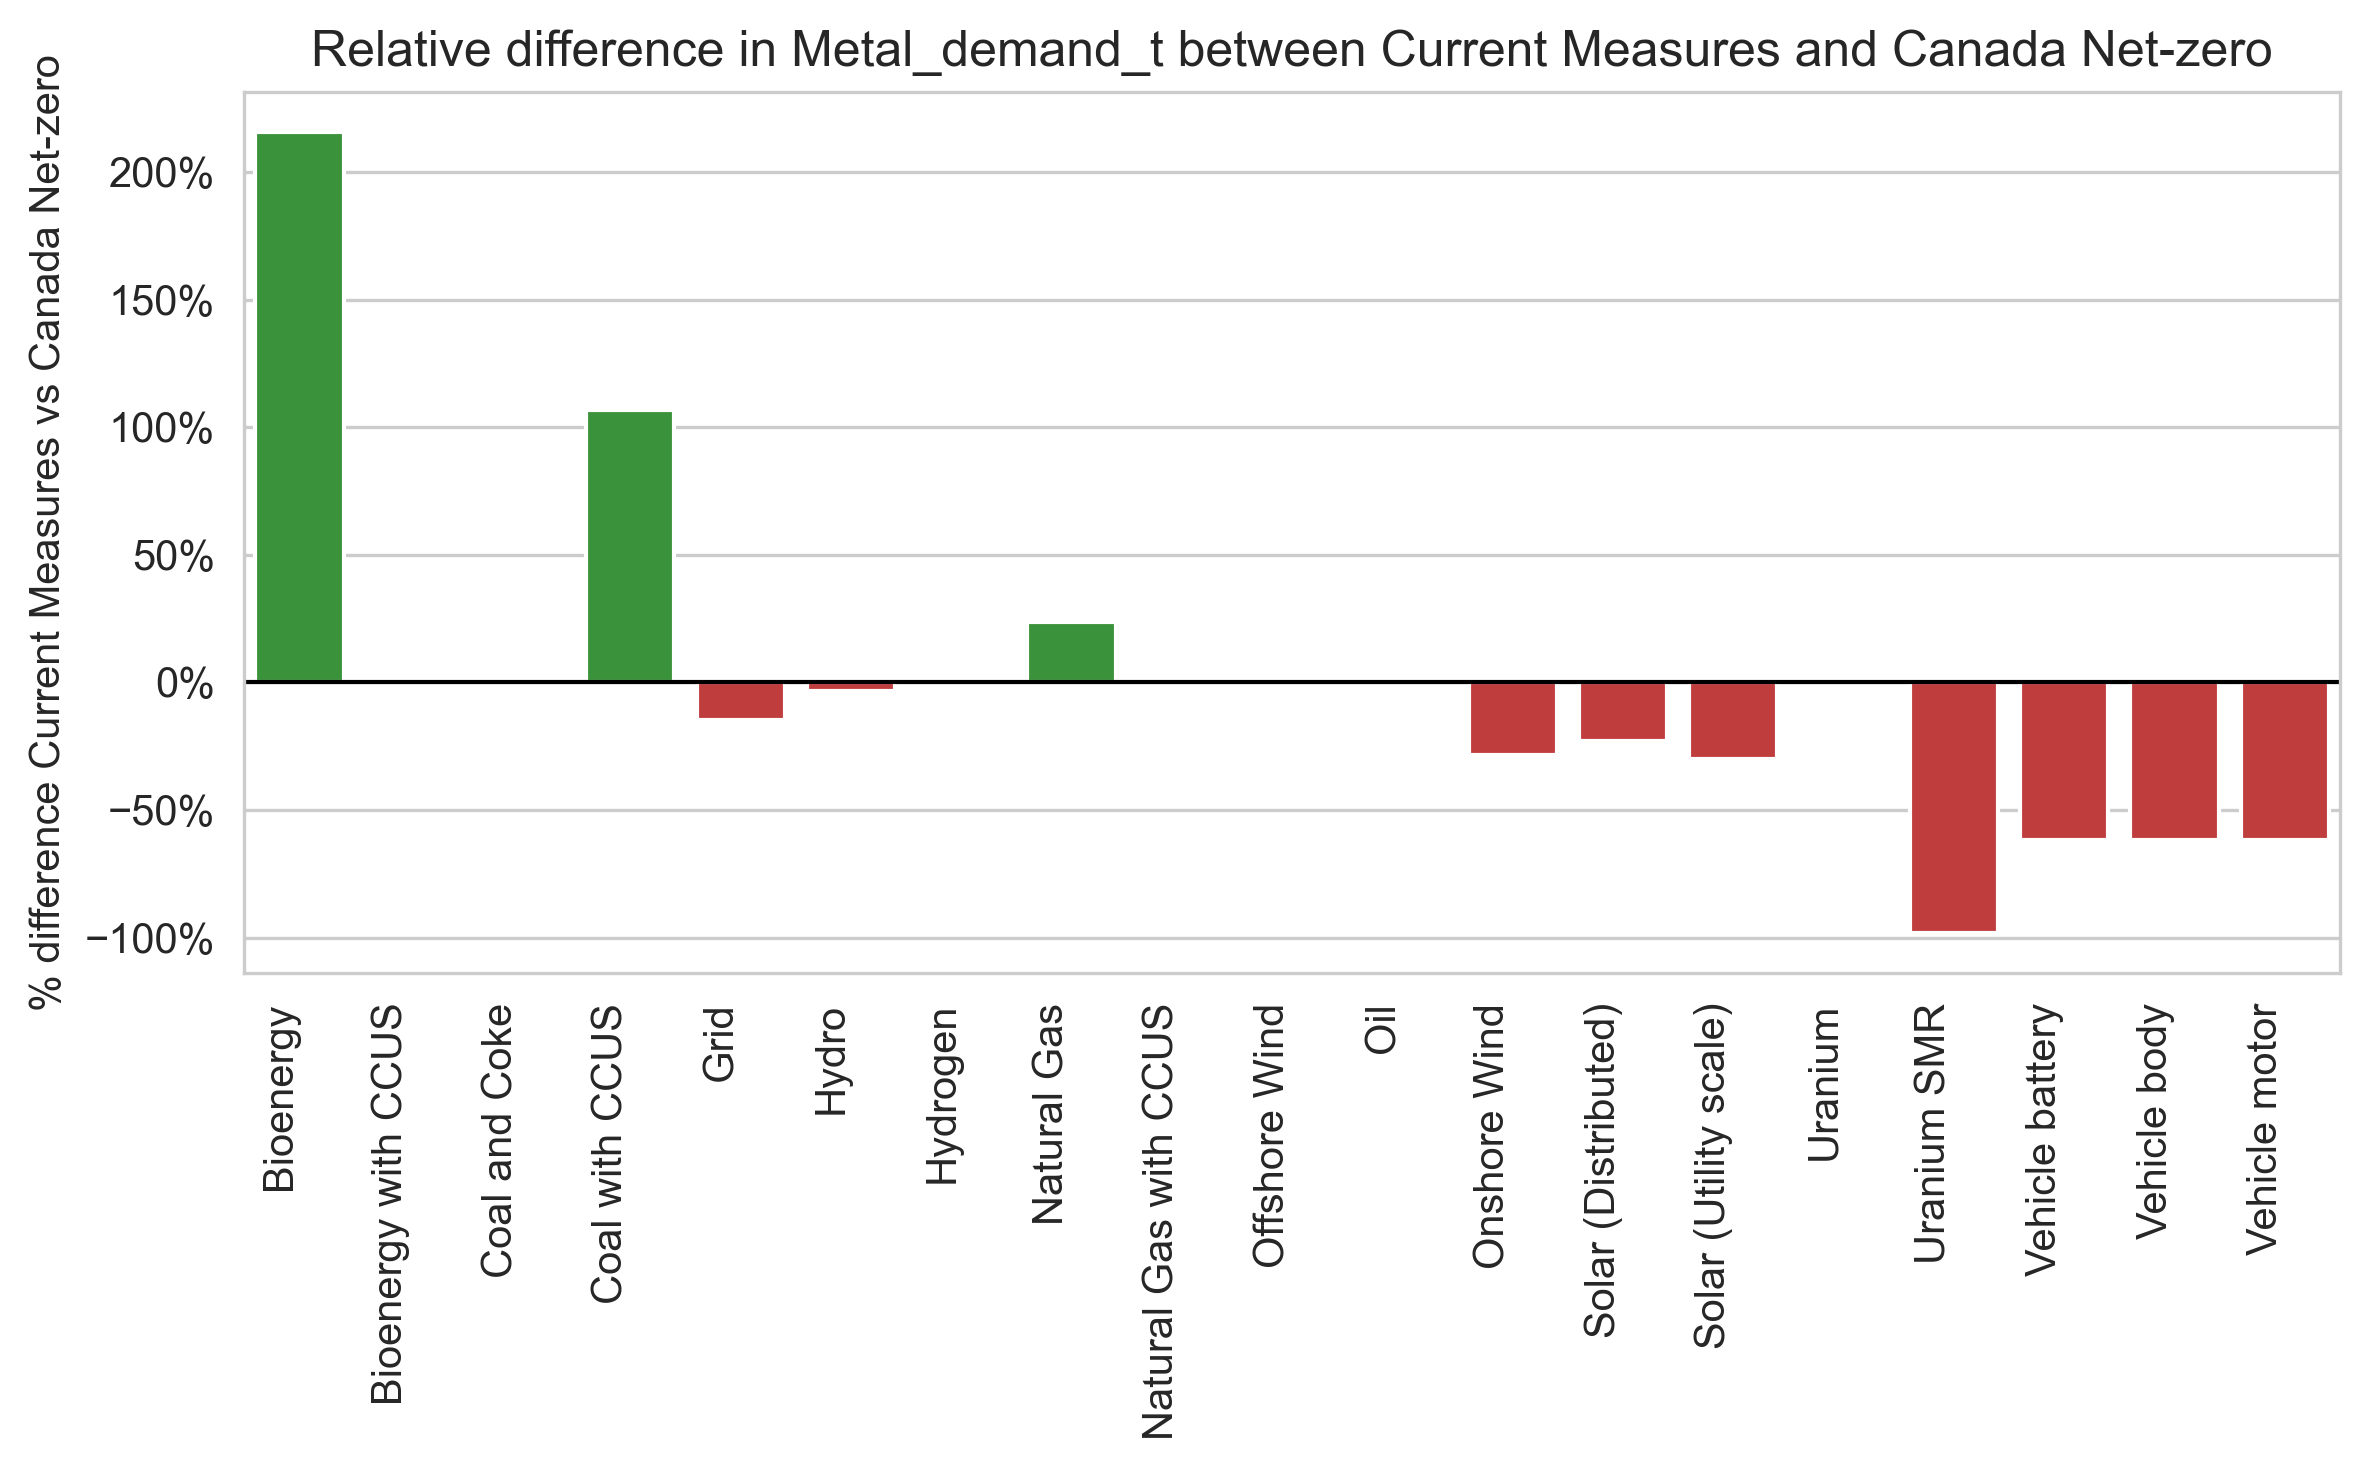

In [105]:
plot_scenario_difference(
    df=metal_demand,
    scenario_col="Scenario",
    value_col="Metal_demand_t",
    variable_col="Technology",
    scenario_a="Current Measures",
    scenario_b="Canada Net-zero",
    savepath="results/Scenario_diff/Scenario_diff_technology"
)